# Question 1 — leakage-controlled forecasting at three geographic levels

This notebook forecasts the three-part physical-activity composition for **London**, **Inner/Outer
London** and **all 32 boroughs** at monthly, quarterly and annual frequency. The revision gives
every candidate the same eligible observations, removes structural warm-up rows, uses survey
precision in training and evaluation, separates selection, development audit and final test, and
keeps all forecasts on the probability simplex.

The operational horizon is now explicit: every model is a **rolling one-period-ahead forecast**
using information available through the preceding period. Seasonal lags remain predictors and
baselines, but they no longer define the forecast horizon.

In [1]:
from pathlib import Path
import json
import os
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'question1_outputs').exists() else cwd.parent
OUTPUT_ROOT = PROJECT_ROOT / 'question1_outputs'
DATA_DIR = OUTPUT_ROOT / 'data'
RESULTS_DIR = OUTPUT_ROOT / 'results'
FIGURES_DIR = OUTPUT_ROOT / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_PATH = RESULTS_DIR / 'q1_forecast_results.xlsx'
BOUNDARY_PATH = DATA_DIR / 'london_borough_boundaries.geojson'

PANEL_PATHS = {
    (level, frequency): DATA_DIR / f'q1_{prefix}_{frequency.lower()}.csv'
    for level, prefix in [('London', 'london'), ('Inner/Outer', 'inner_outer'), ('Borough', 'borough')]
    for frequency in ['Annual', 'Quarterly', 'Monthly']
}
TARGETS = ['inactive_rate', 'fairly_active_rate', 'active_rate']
TARGET_LABELS = {
    'inactive_rate': 'Inactive',
    'fairly_active_rate': 'Fairly active',
    'active_rate': 'Active',
}
SURVEY_COMPOSITION = ['older_adult_rate', 'limiting_disability_rate']
ONLINE_FEATURE = 'online_response_rate'
CONTEXT_GROUPS = {
    'population': [
        'adult_population', 'population_age_16_34_rate',
        'population_age_65_plus_rate', 'population_female_rate',
    ],
    'migration': ['net_migration_per_1000'],
    # Retain relative earnings, not both the raw and relative versions.
    'earnings': ['earnings_relative_to_london'],
    # Retain the prespecified combined rate, not it plus its two components.
    'crime': ['selected_recorded_crime_rate_per_1000'],
}
RANDOM_STATE = 2026
TREE_SEEDS = [2026, 2027, 2028]
TREE_ALGORITHMS = ['Random Forest', 'Gradient Boosting']
ILR_EPSILON = 1e-6


def save_figure(fig, name):
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    return path

## 1. Independent input validation and coverage

Forecasting performs its own validation rather than assuming Notebook 01 succeeded. The checks
cover keys, the complete geography-time grid, time continuity, target bounds and composition,
missing targets, predictor missingness and positive effective sample size. Missing economic
inactivity and weather are recorded as upstream coverage gaps; they are not imputed from unrelated
variables.

In [2]:
panels = {key: pd.read_csv(path) for key, path in PANEL_PATHS.items()}
for (level, frequency), frame in panels.items():
    if frequency == 'Monthly':
        frame['period_start'] = pd.to_datetime(frame['period_start'])
    elif frequency == 'Quarterly':
        frame['quarter_start'] = pd.to_datetime(frame['quarter_start'])
        frame['quarter_end'] = pd.to_datetime(frame['quarter_end'])

TIME_COLUMNS = {'Monthly': 'month_index', 'Quarterly': 'quarter_index', 'Annual': 'year'}
ACTIVITY_COLUMNS = [
    column for column in panels[('Borough', 'Monthly')]
    if column.startswith(('MONTHS12_RATE_', 'DAYS_ANY_RATE_', 'DAYS_2PLUS_RATE_'))
]
assert len(panels) == 9 and len(ACTIVITY_COLUMNS) == 372

validation_rows = []
missing_rows = []
for (level, frequency), frame in panels.items():
    time_column = TIME_COLUMNS[frequency]
    keys = [time_column, 'geography_code']
    complete_target = frame[TARGETS].notna().all(axis=1)
    complete = frame.loc[complete_target]
    expected_rows = frame['geography_code'].nunique() * frame[time_column].nunique()
    expected_times = np.arange(frame[time_column].min(), frame[time_column].max() + 1)
    continuity_failures = sum(
        not np.array_equal(np.sort(group[time_column].unique()), expected_times)
        for _, group in frame.groupby('geography_code')
    )
    row = {
        'geographic_level': level,
        'frequency': frequency,
        'rows': len(frame),
        'expected_grid_rows': expected_rows,
        'geographies': frame['geography_code'].nunique(),
        'time_periods': frame[time_column].nunique(),
        'duplicate_keys': int(frame.duplicated(keys).sum()),
        'geographies_with_time_gaps': int(continuity_failures),
        'missing_target_rows': int((~complete_target).sum()),
        'out_of_bounds_target_cells': int(
            (~complete[TARGETS].apply(lambda x: x.between(0, 1))).sum().sum()
        ),
        'maximum_composition_error': complete[TARGETS].sum(axis=1).sub(1).abs().max(),
        'nonpositive_effective_n': int(frame['effective_n'].le(0).sum()),
        'median_effective_n': frame['effective_n'].median(),
        'minimum_effective_n': frame['effective_n'].min(),
    }
    validation_rows.append(row)
    if (~complete_target).any():
        missing_rows.append(
            frame.loc[~complete_target, keys + ['geography_name', 'effective_n', *TARGETS]]
            .assign(geographic_level=level, frequency=frequency)
        )
    assert len(frame) == expected_rows
    assert row['duplicate_keys'] == 0
    assert row['geographies_with_time_gaps'] == 0
    assert row['out_of_bounds_target_cells'] == 0
    assert row['maximum_composition_error'] < 1e-10
    assert row['nonpositive_effective_n'] == 0

panel_validation = pd.DataFrame(validation_rows)
missing_target_rows = (
    pd.concat(missing_rows, ignore_index=True) if missing_rows else pd.DataFrame()
)
predictor_coverage = pd.DataFrame([
    {
        'predictor_group': 'Economic inactivity',
        'status': 'Unavailable upstream',
        'forecast_treatment': 'Not used; no proxy imputation',
    },
    {
        'predictor_group': 'Weather',
        'status': 'Unavailable upstream',
        'forecast_treatment': 'Not used; no proxy imputation',
    },
    {
        'predictor_group': 'Online response rate',
        'status': 'Available',
        'forecast_treatment': 'Sensitivity-only; excluded from primary candidates',
    },
    {
        'predictor_group': 'Earnings',
        'status': 'Available',
        'forecast_treatment': 'Relative-to-London measure only; raw earnings duplicate removed',
    },
    {
        'predictor_group': 'Recorded crime',
        'status': 'Available but specification-sensitive',
        'forecast_treatment': 'Combined selected rate only; component duplicates removed',
    },
])

missingness_rows = []
missingness_groups = {
    'Survey composition': SURVEY_COMPOSITION,
    'Online response': [ONLINE_FEATURE],
    'Activity variables': ACTIVITY_COLUMNS,
    **{name.title(): values for name, values in CONTEXT_GROUPS.items()},
}
for (level, frequency), frame in panels.items():
    for group_name, columns in missingness_groups.items():
        absent = [column for column in columns if column not in frame.columns]
        assert not absent, f'{level}/{frequency} missing required columns: {absent}'
        missingness_rows.append({
            'geographic_level': level, 'frequency': frequency,
            'predictor_group': group_name, 'columns': len(columns),
            'missing_cells': int(frame[columns].isna().sum().sum()),
            'rows_with_any_missing': int(frame[columns].isna().any(axis=1).sum()),
            'total_cells': int(len(frame) * len(columns)),
        })
predictor_missingness = pd.DataFrame(missingness_rows)
predictor_missingness['missing_cell_share'] = (
    predictor_missingness['missing_cells'] / predictor_missingness['total_cells']
)
display(panel_validation)
display(missing_target_rows)
display(predictor_coverage)
display(predictor_missingness)

,geographic_level,frequency,rows,expected_grid_rows,geographies,time_periods,duplicate_keys,geographies_with_time_gaps,missing_target_rows,out_of_bounds_target_cells,maximum_composition_error,nonpositive_effective_n,median_effective_n,minimum_effective_n
0,London,Annual,8,8,1,8,0,0,0,0,2.220446e-16,0,9163.014759,8669.765028
1,London,Quarterly,32,32,1,32,0,0,0,0,3.330669e-16,0,2133.688613,1239.520400
2,London,Monthly,96,96,1,96,0,0,0,0,2.220446e-16,0,746.420017,267.610171
3,Inner/Outer,Annual,16,16,2,8,0,0,0,0,2.220446e-16,0,4569.559928,3458.681935
4,Inner/Outer,Quarterly,64,64,2,32,0,0,0,0,3.330669e-16,0,1070.845073,519.004551
5,Inner/Outer,Monthly,192,192,2,96,0,0,0,0,4.440892e-16,0,366.003738,117.467030
6,Borough,Annual,256,256,32,8,0,0,0,0,4.440892e-16,0,294.719558,212.553432
7,Borough,Quarterly,1024,1024,32,32,0,0,0,0,4.440892e-16,0,71.487031,13.278066
8,Borough,Monthly,3072,3072,32,96,0,0,1,0,5.551115e-16,0,25.178183,2.801356


,month_index,geography_code,geography_name,effective_n,inactive_rate,fairly_active_rate,active_rate,geographic_level,frequency
0,60,E09000002,Barking and Dagenham,NaN,NaN,NaN,NaN,Borough,Monthly


,predictor_group,status,forecast_treatment
0,Economic inactivity,Unavailable upstream,Not used; no proxy imputation
1,Weather,Unavailable upstream,Not used; no proxy imputation
2,Online response rate,Available,Sensitivity-only; excluded from primary candid...
3,Earnings,Available,Relative-to-London measure only; raw earnings ...
4,Recorded crime,Available but specification-sensitive,Combined selected rate only; component duplica...


,geographic_level,frequency,predictor_group,columns,missing_cells,rows_with_any_missing,total_cells,missing_cell_share
0,London,Annual,Survey composition,2,0,0,16,0.000000
1,London,Annual,Online response,1,0,0,8,0.000000
2,London,Annual,Activity variables,372,0,0,2976,0.000000
3,London,Annual,Population,4,0,0,32,0.000000
4,London,Annual,Migration,1,0,0,8,0.000000
...,...,...,...,...,...,...,...,...
58,Borough,Monthly,Activity variables,372,372,1,1142784,0.000326
59,Borough,Monthly,Population,4,0,0,12288,0.000000
60,Borough,Monthly,Migration,1,0,0,3072,0.000000
61,Borough,Monthly,Earnings,1,0,0,3072,0.000000


## 2. One-step features, ILR composition and genuine warm-up removal

The model uses recent lags, seasonal lags, recent means, recent change and a fixed exponentially
weighted history. All rolling features are shifted before calculation. Structural warm-up rows are
removed before any fold is created and are never recovered by median imputation. Sporadic predictor
missingness may still be imputed inside a training fold.

The earlier Active-denominator ALR is replaced by an orthonormal **isometric log-ratio (ILR)**
transform. This removes dependence on an arbitrary reference category while retaining coherent
three-part predictions.

In [3]:
TASK_DESIGNS = {
    'Monthly': {
        'time': 'month_index', 'cycle': 'month_of_wave', 'cycle_length': 12,
        'seasonal_lag': 12, 'recent_window': 3,
        'selection_folds': [(49, 60), (61, 72)],
        'audit': (73, 84), 'test': (85, 96),
    },
    'Quarterly': {
        'time': 'quarter_index', 'cycle': 'quarter_of_wave', 'cycle_length': 4,
        'seasonal_lag': 4, 'recent_window': 2,
        'selection_folds': [(17, 20), (21, 24)],
        'audit': (25, 28), 'test': (29, 32),
    },
    'Annual': {
        'time': 'year', 'cycle': 'year', 'cycle_length': 1,
        'seasonal_lag': 1, 'recent_window': 2,
        'selection_folds': [(5, 5), (6, 6)],
        'audit': (7, 7), 'test': (8, 8),
    },
}


def close_composition(values):
    values = np.clip(np.asarray(values, dtype=float), ILR_EPSILON, None)
    return values / values.sum(axis=1, keepdims=True)


ILR_BASIS = np.array([
    [1 / np.sqrt(2), 1 / np.sqrt(6)],
    [-1 / np.sqrt(2), 1 / np.sqrt(6)],
    [0, -2 / np.sqrt(6)],
])


def shares_to_ilr(shares):
    shares = close_composition(shares)
    clr = np.log(shares) - np.log(shares).mean(axis=1, keepdims=True)
    return clr @ ILR_BASIS


def ilr_to_shares(coordinates):
    clr = np.asarray(coordinates, dtype=float) @ ILR_BASIS.T
    exponent = np.exp(np.clip(clr, -30, 30))
    return exponent / exponent.sum(axis=1, keepdims=True)


def add_activity_breadth(frame):
    result = frame.copy()
    definitions = {
        'months12_activity_breadth_index': 'MONTHS12_RATE_',
        'days_any_activity_breadth_index': 'DAYS_ANY_RATE_',
        'days_2plus_activity_breadth_index': 'DAYS_2PLUS_RATE_',
    }
    for name, prefix in definitions.items():
        columns = [c for c in ACTIVITY_COLUMNS if c.startswith(prefix)]
        # Mean prevalence across listed activities: a breadth index, not a latent activity score.
        result[name] = result[columns].mean(axis=1)
    return result, list(definitions)


def prepare_panel(frame, frequency):
    design = TASK_DESIGNS[frequency]
    time_column = design['time']
    result, breadth = add_activity_breadth(frame)
    result = result.sort_values(['geography_code', time_column]).reset_index(drop=True)
    grouped = result.groupby('geography_code', sort=False)

    dynamic_features = []
    structural_features = []
    for target in TARGETS:
        lag1 = f'{target}_lag1'
        lag2 = f'{target}_lag2'
        seasonal = f'{target}_seasonal_lag'
        recent_mean = f'{target}_recent_mean'
        recent_change = f'{target}_recent_change'
        ewm = f'{target}_ewm_history'
        result[lag1] = grouped[target].shift(1)
        result[lag2] = grouped[target].shift(2)
        result[seasonal] = grouped[target].shift(design['seasonal_lag'])
        result[recent_mean] = grouped[target].transform(
            lambda s: s.shift(1).rolling(design['recent_window'], min_periods=design['recent_window']).mean()
        )
        result[recent_change] = result[lag1] - result[lag2]
        result[ewm] = grouped[target].transform(
            lambda s: s.shift(1).ewm(alpha=.5, adjust=False).mean()
        )
        dynamic_features.extend([lag1, seasonal, recent_mean, recent_change, ewm])
        structural_features.extend([lag1, lag2, seasonal, recent_mean, recent_change, ewm])

    lag_sources = SURVEY_COMPOSITION + breadth + [ONLINE_FEATURE]
    for group in CONTEXT_GROUPS.values():
        lag_sources.extend(group)
    for source in dict.fromkeys(lag_sources):
        result[f'{source}_lag1'] = grouped[source].shift(1)

    if design['cycle_length'] == 1:
        result['season_sin'] = 0.0
        result['season_cos'] = 1.0
    else:
        phase = 2 * np.pi * (result[design['cycle']] - 1) / design['cycle_length']
        result['season_sin'] = np.sin(phase)
        result['season_cos'] = np.cos(phase)
    # Raw time is scaled inside each training fold, avoiding full-series normalization.
    result['time_trend'] = result[time_column].astype(float)

    core = (
        dynamic_features
        + [f'{x}_lag1' for x in SURVEY_COMPOSITION]
        + [f'{x}_lag1' for x in breadth]
        + ['season_sin', 'season_cos', 'time_trend']
    )
    context = {name: [f'{x}_lag1' for x in values] for name, values in CONTEXT_GROUPS.items()}
    feature_sets = {'core': core}
    for name, values in context.items():
        feature_sets[f'core_{name}'] = core + values
    feature_sets['core_all_context'] = core + sum(context.values(), [])
    feature_sets['core_online_sensitivity'] = core + [f'{ONLINE_FEATURE}_lag1']

    required = list(dict.fromkeys(TARGETS + structural_features))
    result['eligible'] = result[required].notna().all(axis=1)
    result['warm_up_removed'] = ~result[structural_features].notna().all(axis=1)
    return result, feature_sets, structural_features


prepared_tasks, task_feature_sets, warmup_rows = {}, {}, []
for (level, frequency), frame in panels.items():
    prepared, feature_sets, structural = prepare_panel(frame, frequency)
    prepared_tasks[(level, frequency)] = prepared
    task_feature_sets[(level, frequency)] = feature_sets
    design = TASK_DESIGNS[frequency]
    warmup_rows.append({
        'geographic_level': level,
        'frequency': frequency,
        'raw_rows': len(prepared),
        'initial_warm_up_rows_removed': int(
            prepared[design['time']].le(max(design['seasonal_lag'], design['recent_window'])).sum()
        ),
        'all_ineligible_rows': int((~prepared['eligible']).sum()),
        'additional_ineligible_rows_after_warm_up': int(
            (~prepared['eligible'] & prepared[design['time']].gt(
                max(design['seasonal_lag'], design['recent_window'])
            )).sum()
        ),
        'eligible_rows': int(prepared['eligible'].sum()),
        'first_eligible_period': int(prepared.loc[prepared['eligible'], design['time']].min()),
        'expected_first_eligible_period': max(
            design['seasonal_lag'], design['recent_window']
        ) + 1,
    })
    assert not prepared.loc[prepared['eligible'], structural].isna().any().any()

warmup_audit = pd.DataFrame(warmup_rows)
display(warmup_audit)

,geographic_level,frequency,raw_rows,initial_warm_up_rows_removed,all_ineligible_rows,additional_ineligible_rows_after_warm_up,eligible_rows,first_eligible_period,expected_first_eligible_period
0,London,Annual,8,2,2,0,6,3,3
1,London,Quarterly,32,4,4,0,28,5,5
2,London,Monthly,96,12,12,0,84,13,13
3,Inner/Outer,Annual,16,4,4,0,12,3,3
4,Inner/Outer,Quarterly,64,8,8,0,56,5,5
5,Inner/Outer,Monthly,192,24,24,0,168,13,13
6,Borough,Annual,256,64,64,0,192,3,3
7,Borough,Quarterly,1024,128,128,0,896,5,5
8,Borough,Monthly,3072,384,389,5,2683,13,13


## 3. Weighted evaluation and sample-size-adaptive candidates

Training uses capped, normalized `effective_n` weights; evaluation uses the uncapped effective
sample size. All models and baselines share identical fold rows. Primary scoring is weighted total
variation; overall MAE is not repeated because, with three composition parts, it is exactly total
variation divided by 1.5.

Every one of the nine geographic-level × frequency tasks now compares the same four families:
the best prespecified Naive baseline, Ridge Regression, Random Forest and Gradient Boosting. Ridge
uses fold-local scaling and regularisation; the two tree families average three random seeds. Tree
depth and leaf size are adapted to the first training fold. Tasks with at most five independent
training periods receive depth-one trees and are explicitly flagged as severe small-series
comparisons—not as reliable evidence that a flexible algorithm can generalise.

Candidate selection remains a single prespecified comparison. A one-standard-error rule prefers the
simplest statistically competitive candidate, so the shortest average-error bar need not become the
official forecast when its advantage is smaller than fold variation.


In [4]:
def normalized_training_weights(effective_n):
    values = np.asarray(effective_n, dtype=float)
    low, high = np.quantile(values, [.05, .95])
    capped = np.clip(values, low, high)
    return capped / capped.mean()


def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return np.sum(values * weights) / np.sum(weights)


def score_predictions(actual, predicted, effective_n, time_values):
    actual = np.asarray(actual, dtype=float)
    predicted = close_composition(predicted)
    effective_n = np.asarray(effective_n, dtype=float)
    valid = (
        np.isfinite(actual).all(axis=1)
        & np.isfinite(predicted).all(axis=1)
        & np.isfinite(effective_n)
        & (effective_n > 0)
    )
    actual, predicted, effective_n = actual[valid], predicted[valid], effective_n[valid]
    time_values = np.asarray(time_values)[valid]
    absolute = np.abs(actual - predicted)
    row_tv = .5 * absolute.sum(axis=1)
    periods = np.unique(time_values).size
    row = {
        'observations': len(actual),
        'time_periods': periods,
        'weighted_total_variation': weighted_mean(row_tv, effective_n),
        'unweighted_total_variation': row_tv.mean(),
    }
    for index, target in enumerate(TARGETS):
        error = predicted[:, index] - actual[:, index]
        mse = weighted_mean(error ** 2, effective_n)
        noise_variance = weighted_mean(
            actual[:, index] * (1 - actual[:, index]) / effective_n, effective_n
        )
        row[f'{target}_weighted_mae'] = weighted_mean(np.abs(error), effective_n)
        row[f'{target}_weighted_rmse'] = np.sqrt(mse)
        row[f'{target}_signed_bias'] = weighted_mean(error, effective_n)
        row[f'{target}_survey_noise_floor_rmse'] = np.sqrt(noise_variance)
        row[f'{target}_noise_adjusted_rmse'] = np.sqrt(max(mse - noise_variance, 0))
        row[f'{target}_weighted_r2'] = (
            r2_score(actual[:, index], predicted[:, index], sample_weight=effective_n)
            if periods >= 8 and np.nanstd(actual[:, index]) > 0 else np.nan
        )
    return row


def build_model(candidate, features, seed=RANDOM_STATE):
    transformers = [
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
        ]), features),
    ]
    if candidate['use_geography']:
        transformers.append((
            'geography',
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
            ['geography_code'],
        ))
    preprocess = ColumnTransformer(transformers)
    if candidate['algorithm'] == 'Ridge':
        estimator = Ridge(alpha=candidate['alpha'])
    elif candidate['algorithm'] == 'Random Forest':
        estimator = RandomForestRegressor(
            n_estimators=120,
            max_depth=candidate['max_depth'],
            min_samples_leaf=candidate['min_samples_leaf'],
            max_features=.7,
            random_state=seed,
            n_jobs=-1,
        )
    else:
        estimator = MultiOutputRegressor(GradientBoostingRegressor(
            n_estimators=120, learning_rate=.05, loss='huber',
            max_depth=candidate['max_depth'],
            min_samples_leaf=candidate['min_samples_leaf'],
            subsample=.8, random_state=seed,
        ))
    return Pipeline([('preprocess', preprocess), ('model', estimator)])


def candidate_features(candidate, feature_sets):
    return feature_sets[candidate['configuration']]


def make_candidates(level, frequency, minimum_training_rows, minimum_training_periods, feature_sets):
    candidates = [
        {'candidate_id': 'last_observation', 'algorithm': 'Last observation',
         'configuration': 'baseline', 'complexity': 1, 'use_geography': False},
        {'candidate_id': 'seasonal_naive', 'algorithm': 'Seasonal naive',
         'configuration': 'baseline', 'complexity': 2, 'use_geography': False},
        {'candidate_id': 'recent_mean', 'algorithm': 'Recent mean',
         'configuration': 'baseline', 'complexity': 3, 'use_geography': False},
        {'candidate_id': 'ewm_history', 'algorithm': 'Exponentially weighted history',
         'configuration': 'baseline', 'complexity': 4, 'use_geography': False},
        {'candidate_id': 'drift', 'algorithm': 'Local drift',
         'configuration': 'baseline', 'complexity': 5, 'use_geography': False},
    ]
    multi_geography = level != 'London'
    configurations = ['core', 'core_population', 'core_migration', 'core_earnings',
                      'core_crime', 'core_all_context']
    for configuration in configurations:
        for alpha in [1.0, 10.0]:
            candidates.append({
                'candidate_id': f'ridge_{configuration}_a{alpha:g}',
                'algorithm': 'Ridge', 'configuration': configuration,
                'alpha': alpha, 'complexity': 10 + (configuration != 'core'),
                'use_geography': multi_geography,
            })
    if multi_geography:
        candidates.append({
            'candidate_id': 'ridge_core_no_geography_a10',
            'algorithm': 'Ridge', 'configuration': 'core', 'alpha': 10.0,
            'complexity': 10, 'use_geography': False,
        })
    # Every task receives both tree families. Very short time series use only a
    # stump-like core specification; this enables the requested comparison without
    # pretending that three or four independent years support a complex tree.
    if minimum_training_periods <= 5:
        tree_specs = [('core', 1, .20)]
    elif minimum_training_periods <= 12:
        tree_specs = [('core', 2, .10)]
    else:
        tree_specs = [('core', 3, .04), ('core_all_context', 4, .06)]
    for configuration, depth, leaf_share in tree_specs:
        for prefix, algorithm, complexity in [
            ('rf', 'Random Forest', 20),
            ('gb', 'Gradient Boosting', 22),
        ]:
            candidates.append({
                'candidate_id': f'{prefix}_{configuration}_d{depth}',
                'algorithm': algorithm, 'configuration': configuration,
                'max_depth': depth,
                'min_samples_leaf': max(1, int(round(minimum_training_rows * leaf_share))),
                'complexity': complexity + (configuration != 'core'),
                'use_geography': multi_geography,
                'small_sample_tree': minimum_training_periods <= 5,
            })
    return candidates


def baseline_prediction(frame, candidate):
    algorithm = candidate['algorithm']
    if algorithm == 'Last observation':
        values = frame[[f'{t}_lag1' for t in TARGETS]].to_numpy()
    elif algorithm == 'Seasonal naive':
        values = frame[[f'{t}_seasonal_lag' for t in TARGETS]].to_numpy()
    elif algorithm == 'Recent mean':
        values = frame[[f'{t}_recent_mean' for t in TARGETS]].to_numpy()
    elif algorithm == 'Exponentially weighted history':
        values = frame[[f'{t}_ewm_history' for t in TARGETS]].to_numpy()
    else:
        lag1 = frame[[f'{t}_lag1' for t in TARGETS]].to_numpy()
        lag2 = frame[[f'{t}_lag2' for t in TARGETS]].to_numpy()
        values = lag1 + (lag1 - lag2)
    return close_composition(values)


def fit_candidate(train, candidate, feature_sets, override_features=None):
    if candidate['configuration'] == 'baseline':
        return []
    features = override_features or candidate_features(candidate, feature_sets)
    seeds = TREE_SEEDS if candidate['algorithm'] in TREE_ALGORITHMS else [RANDOM_STATE]
    models = []
    weights = normalized_training_weights(train['effective_n'])
    columns = features + (['geography_code'] if candidate['use_geography'] else [])
    for seed in seeds:
        model = build_model(candidate, features, seed)
        model.fit(
            train[columns], shares_to_ilr(train[TARGETS]),
            model__sample_weight=weights,
        )
        models.append(model)
    return models


def predict_candidate(frame, candidate, feature_sets, models, override_features=None):
    if candidate['configuration'] == 'baseline':
        return baseline_prediction(frame, candidate), 0.0
    features = override_features or candidate_features(candidate, feature_sets)
    columns = features + (['geography_code'] if candidate['use_geography'] else [])
    seed_predictions = [ilr_to_shares(model.predict(frame[columns])) for model in models]
    prediction = close_composition(np.mean(seed_predictions, axis=0))
    return prediction, seed_predictions


def prediction_output(frame, predicted, time_column, candidate, fold=None, phase=None):
    metadata = [
        time_column, 'geography_code', 'geography_name', 'effective_n', *TARGETS,
        *[c for c in ['inner_outer', 'adult_population'] if c in frame.columns],
    ]
    output = frame[metadata].copy()
    output['candidate_id'] = candidate['candidate_id']
    output['algorithm'] = candidate['algorithm']
    if fold is not None:
        output['fold'] = fold
    if phase is not None:
        output['phase'] = phase
    for index, target in enumerate(TARGETS):
        output[f'predicted_{target}'] = predicted[:, index]
        output[f'error_{target}'] = predicted[:, index] - output[target]
    output['row_total_variation'] = .5 * sum(
        output[f'error_{target}'].abs() for target in TARGETS
    )
    return output


def evaluate_candidate_folds(panel, feature_sets, candidate, design):
    metric_rows, predictions = [], []
    time_column = design['time']
    for fold, (start, end) in enumerate(design['selection_folds'], start=1):
        train = panel.loc[panel['eligible'] & panel[time_column].lt(start)].copy()
        validation = panel.loc[panel['eligible'] & panel[time_column].between(start, end)].copy()
        models = fit_candidate(train, candidate, feature_sets)
        predicted, seed_predictions = predict_candidate(
            validation, candidate, feature_sets, models
        )
        metrics = score_predictions(
            validation[TARGETS], predicted, validation['effective_n'], validation[time_column]
        )
        seed_sd = 0.0
        if isinstance(seed_predictions, list) and len(seed_predictions) > 1:
            seed_scores = [
                score_predictions(
                    validation[TARGETS], p, validation['effective_n'], validation[time_column]
                )['weighted_total_variation']
                for p in seed_predictions
            ]
            seed_sd = float(np.std(seed_scores, ddof=1))
        metric_rows.append({
            'fold': fold, 'validation_start': start, 'validation_end': end,
            'training_rows': len(train), 'seed_tv_sd': seed_sd,
            **metrics,
        })
        predictions.append(prediction_output(validation, predicted, time_column, candidate, fold=fold))
    return pd.DataFrame(metric_rows), pd.concat(predictions, ignore_index=True)


def select_one_se(candidate_metrics, candidates):
    summary = candidate_metrics.groupby('candidate_id', as_index=False).agg(
        mean_weighted_tv=('weighted_total_variation', 'mean'),
        sd_weighted_tv=('weighted_total_variation', 'std'),
        folds=('fold', 'nunique'),
        mean_seed_tv_sd=('seed_tv_sd', 'mean'),
    )
    summary['se_weighted_tv'] = summary['sd_weighted_tv'] / np.sqrt(summary['folds'])
    metadata = pd.DataFrame(candidates)[
        ['candidate_id', 'algorithm', 'configuration', 'complexity', 'use_geography']
    ]
    summary = summary.merge(metadata, on='candidate_id', validate='one_to_one')
    best = summary.sort_values('mean_weighted_tv').iloc[0]
    threshold = best['mean_weighted_tv'] + (0 if pd.isna(best['se_weighted_tv']) else best['se_weighted_tv'])
    eligible = summary.loc[summary['mean_weighted_tv'].le(threshold + 1e-12)].copy()
    selected = eligible.sort_values(['complexity', 'mean_weighted_tv', 'candidate_id']).iloc[0]
    summary['one_se_threshold'] = threshold
    summary['within_one_se'] = summary['mean_weighted_tv'].le(threshold + 1e-12)
    summary['selected'] = summary['candidate_id'].eq(selected['candidate_id'])
    return selected['candidate_id'], summary


def evaluate_phase(panel, feature_sets, candidate, design, phase):
    time_column = design['time']
    start, end = design[phase]
    train = panel.loc[panel['eligible'] & panel[time_column].lt(start)].copy()
    evaluation = panel.loc[panel['eligible'] & panel[time_column].between(start, end)].copy()
    models = fit_candidate(train, candidate, feature_sets)
    predicted, _ = predict_candidate(evaluation, candidate, feature_sets, models)
    metrics = score_predictions(
        evaluation[TARGETS], predicted, evaluation['effective_n'], evaluation[time_column]
    )
    output = prediction_output(evaluation, predicted, time_column, candidate, phase=phase)
    return metrics, output, models, train, evaluation


def run_task(level, frequency, panel, feature_sets):
    design = TASK_DESIGNS[frequency]
    first_start = design['selection_folds'][0][0]
    first_training_frame = panel.loc[
        panel['eligible'] & panel[design['time']].lt(first_start)
    ]
    minimum_training_rows = len(first_training_frame)
    minimum_training_periods = first_training_frame[design['time']].nunique()
    candidates = make_candidates(
        level, frequency, minimum_training_rows, minimum_training_periods, feature_sets
    )
    metric_parts, prediction_parts = [], []
    for candidate in candidates:
        metrics, predictions = evaluate_candidate_folds(panel, feature_sets, candidate, design)
        metrics = metrics.assign(
            candidate_id=candidate['candidate_id'], algorithm=candidate['algorithm']
        )
        metric_parts.append(metrics)
        prediction_parts.append(predictions)
    selection_metrics = pd.concat(metric_parts, ignore_index=True)
    selection_predictions = pd.concat(prediction_parts, ignore_index=True)

    selected_id, candidate_summary = select_one_se(selection_metrics, candidates)
    lookup = {candidate['candidate_id']: candidate for candidate in candidates}
    selected = lookup[selected_id]
    phase_results = {}
    for phase in ['audit', 'test']:
        phase_candidates = {selected_id: selected}
        for reference in ['last_observation', 'seasonal_naive']:
            if reference in lookup:
                phase_candidates[reference] = lookup[reference]
        rows, outputs = [], []
        selected_models = selected_train = selected_frame = None
        for candidate_id, candidate in phase_candidates.items():
            metrics, prediction, models, train, evaluation = evaluate_phase(
                panel, feature_sets, candidate, design, phase
            )
            rows.append({'candidate_id': candidate_id, 'algorithm': candidate['algorithm'], **metrics})
            outputs.append(prediction)
            if candidate_id == selected_id:
                selected_models, selected_train, selected_frame = models, train, evaluation
        phase_results[phase] = {
            'metrics': pd.DataFrame(rows),
            'predictions': pd.concat(outputs, ignore_index=True),
            'models': selected_models,
            'train': selected_train,
            'frame': selected_frame,
        }

    observation_counts = selection_metrics.groupby('fold')['observations'].nunique()
    assert observation_counts.eq(1).all(), 'Every candidate must use the same validation rows.'
    return {
        'level': level, 'frequency': frequency, 'panel': panel,
        'feature_sets': feature_sets, 'design': design, 'candidates': candidates,
        'minimum_training_rows': minimum_training_rows,
        'minimum_training_periods': minimum_training_periods,
        'selection_metrics': selection_metrics,
        'selection_predictions': selection_predictions,
        'candidate_summary': candidate_summary,
        'selected_id': selected_id, 'selected': selected,
        'audit': phase_results['audit'], 'test': phase_results['test'],
    }

## 4. Selection folds, development audit and untouched test

Monthly and quarterly candidates are selected on two expanding folds, checked once on a later
development audit block, and evaluated on the final block. Annual selection uses Years 5 and 6,
Year 7 is the audit, and Year 8 is the final test. Annual aggregate results remain single-year
descriptions even after this separation; pooling boroughs does not create additional independent
time points.

In [5]:
task_results = {}
for frequency in ['Monthly', 'Quarterly', 'Annual']:
    for level in ['London', 'Inner/Outer', 'Borough']:
        print(f'Running {level} / {frequency} ...')
        task_results[(level, frequency)] = run_task(
            level, frequency,
            prepared_tasks[(level, frequency)],
            task_feature_sets[(level, frequency)],
        )

selection_fold_metrics = pd.concat([
    result['selection_metrics'].assign(geographic_level=level, frequency=frequency)
    for (level, frequency), result in task_results.items()
], ignore_index=True)
candidate_summary = pd.concat([
    result['candidate_summary'].assign(geographic_level=level, frequency=frequency)
    for (level, frequency), result in task_results.items()
], ignore_index=True)
selection_predictions = pd.concat([
    result['selection_predictions'].assign(geographic_level=level, frequency=frequency)
    for (level, frequency), result in task_results.items()
], ignore_index=True)

audit_metrics = pd.concat([
    result['audit']['metrics'].assign(geographic_level=level, frequency=frequency)
    for (level, frequency), result in task_results.items()
], ignore_index=True)
test_metrics = pd.concat([
    result['test']['metrics'].assign(geographic_level=level, frequency=frequency)
    for (level, frequency), result in task_results.items()
], ignore_index=True)
audit_predictions = pd.concat([
    result['audit']['predictions'].assign(geographic_level=level, frequency=frequency)
    for (level, frequency), result in task_results.items()
], ignore_index=True)
test_predictions = pd.concat([
    result['test']['predictions'].assign(geographic_level=level, frequency=frequency)
    for (level, frequency), result in task_results.items()
], ignore_index=True)

selection_register = pd.DataFrame([{
    'geographic_level': level,
    'frequency': frequency,
    'selected_candidate': result['selected_id'],
    'selected_algorithm': result['selected']['algorithm'],
    'configuration': result['selected']['configuration'],
    'use_geographic_identity': result['selected']['use_geography'],
    'minimum_first_fold_training_rows': result['minimum_training_rows'],
    'minimum_first_fold_training_periods': result['minimum_training_periods'],
    'final_test_training_rows': len(result['test']['train']),
    'final_test_training_time_periods': result['test']['train'][
        result['design']['time']
    ].nunique(),
    'candidate_count': len(result['candidates']),
    'tree_candidates_allowed': any(c['algorithm'] in TREE_ALGORITHMS for c in result['candidates']),
    'aggregate_annual_ml_restricted': False,
    'severe_short_series_warning': result['minimum_training_periods'] <= 5,
} for (level, frequency), result in task_results.items()])

sample_consistency = selection_fold_metrics.groupby(
    ['geographic_level', 'frequency', 'fold'], as_index=False
).agg(
    candidate_count=('candidate_id', 'nunique'),
    distinct_evaluation_sample_sizes=('observations', 'nunique'),
    evaluation_observations=('observations', 'first'),
)
assert sample_consistency['distinct_evaluation_sample_sizes'].eq(1).all()

weight_audit = pd.DataFrame([{
    'geographic_level': level,
    'frequency': frequency,
    'phase': phase,
    'rows': len(result[phase]['frame']),
    'median_effective_n': result[phase]['frame']['effective_n'].median(),
    'minimum_effective_n': result[phase]['frame']['effective_n'].min(),
    'maximum_effective_n': result[phase]['frame']['effective_n'].max(),
} for (level, frequency), result in task_results.items() for phase in ['audit', 'test']])

display(selection_register)
display(sample_consistency)

Running London / Monthly ...
Running Inner/Outer / Monthly ...
Running Borough / Monthly ...
Running London / Quarterly ...
Running Inner/Outer / Quarterly ...
Running Borough / Quarterly ...
Running London / Annual ...
Running Inner/Outer / Annual ...
Running Borough / Annual ...


,geographic_level,frequency,selected_candidate,selected_algorithm,configuration,use_geographic_identity,minimum_first_fold_training_rows,minimum_first_fold_training_periods,final_test_training_rows,final_test_training_time_periods,candidate_count,tree_candidates_allowed,aggregate_annual_ml_restricted,severe_short_series_warning
0,London,Monthly,last_observation,Last observation,baseline,False,36,36,72,72,21,True,False,False
1,Inner/Outer,Monthly,last_observation,Last observation,baseline,False,72,36,144,72,22,True,False,False
2,Borough,Monthly,rf_core_all_context_d4,Random Forest,core_all_context,True,1152,36,2299,72,22,True,False,False
3,London,Quarterly,gb_core_d2,Gradient Boosting,core,False,12,12,24,24,19,True,False,False
4,Inner/Outer,Quarterly,seasonal_naive,Seasonal naive,baseline,False,24,12,48,24,20,True,False,False
5,Borough,Quarterly,ridge_core_no_geography_a10,Ridge,core,False,384,12,768,24,20,True,False,False
6,London,Annual,last_observation,Last observation,baseline,False,2,2,5,5,19,True,False,True
7,Inner/Outer,Annual,last_observation,Last observation,baseline,False,4,2,10,5,20,True,False,True
8,Borough,Annual,recent_mean,Recent mean,baseline,False,64,2,160,5,20,True,False,True


,geographic_level,frequency,fold,candidate_count,distinct_evaluation_sample_sizes,evaluation_observations
0,Borough,Annual,1,20,1,32
1,Borough,Annual,2,20,1,32
2,Borough,Monthly,1,22,1,383
3,Borough,Monthly,2,22,1,380
4,Borough,Quarterly,1,20,1,128
5,Borough,Quarterly,2,20,1,128
6,Inner/Outer,Annual,1,20,1,2
7,Inner/Outer,Annual,2,20,1,2
8,Inner/Outer,Monthly,1,22,1,24
9,Inner/Outer,Monthly,2,22,1,24


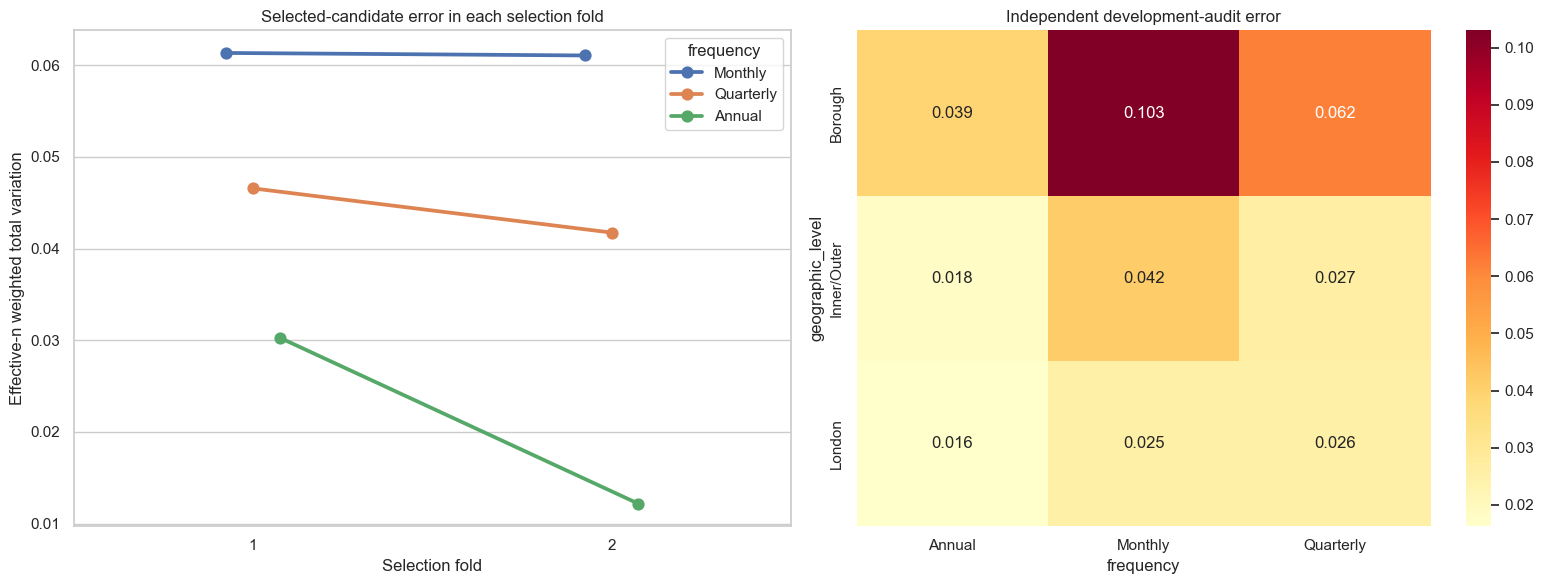

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
selected_fold = selection_fold_metrics.merge(
    selection_register[['geographic_level', 'frequency', 'selected_candidate']],
    left_on=['geographic_level', 'frequency', 'candidate_id'],
    right_on=['geographic_level', 'frequency', 'selected_candidate'],
)
sns.pointplot(
    data=selected_fold, x='fold', y='weighted_total_variation',
    hue='frequency', errorbar=None, dodge=.15, ax=axes[0],
)
axes[0].set(title='Selected-candidate error in each selection fold',
            xlabel='Selection fold', ylabel='Effective-n weighted total variation')

audit_selected = audit_metrics.merge(
    selection_register[['geographic_level', 'frequency', 'selected_candidate']],
    left_on=['geographic_level', 'frequency', 'candidate_id'],
    right_on=['geographic_level', 'frequency', 'selected_candidate'],
)
audit_heat = audit_selected.pivot(
    index='geographic_level', columns='frequency', values='weighted_total_variation'
)
sns.heatmap(audit_heat, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Independent development-audit error')
fig.tight_layout()
save_figure(fig, 'forecast_selection_folds_and_audit.png')
plt.show()

### Complete four-family comparison

All nine tasks are compared below on the two selection folds. Within each family, the prespecified
candidate with the lowest mean selection error is frozen, refitted and evaluated on the independent
development audit and final test. Test results are reported once and never determine the selected
candidate, per-task recommendation or overall family ranking.

“Naive baseline” is the best of last observation, seasonal naive, recent mean, fixed exponential
history and local drift. Bars are selection-fold means and dots are the individual folds; lower
effective-n-weighted total variation is better. Annual comparisons have only two independent pre-selection training years in the first fold and
one year per validation block, so their apparent ordering is highly unstable even though all four
algorithms are technically fitted.


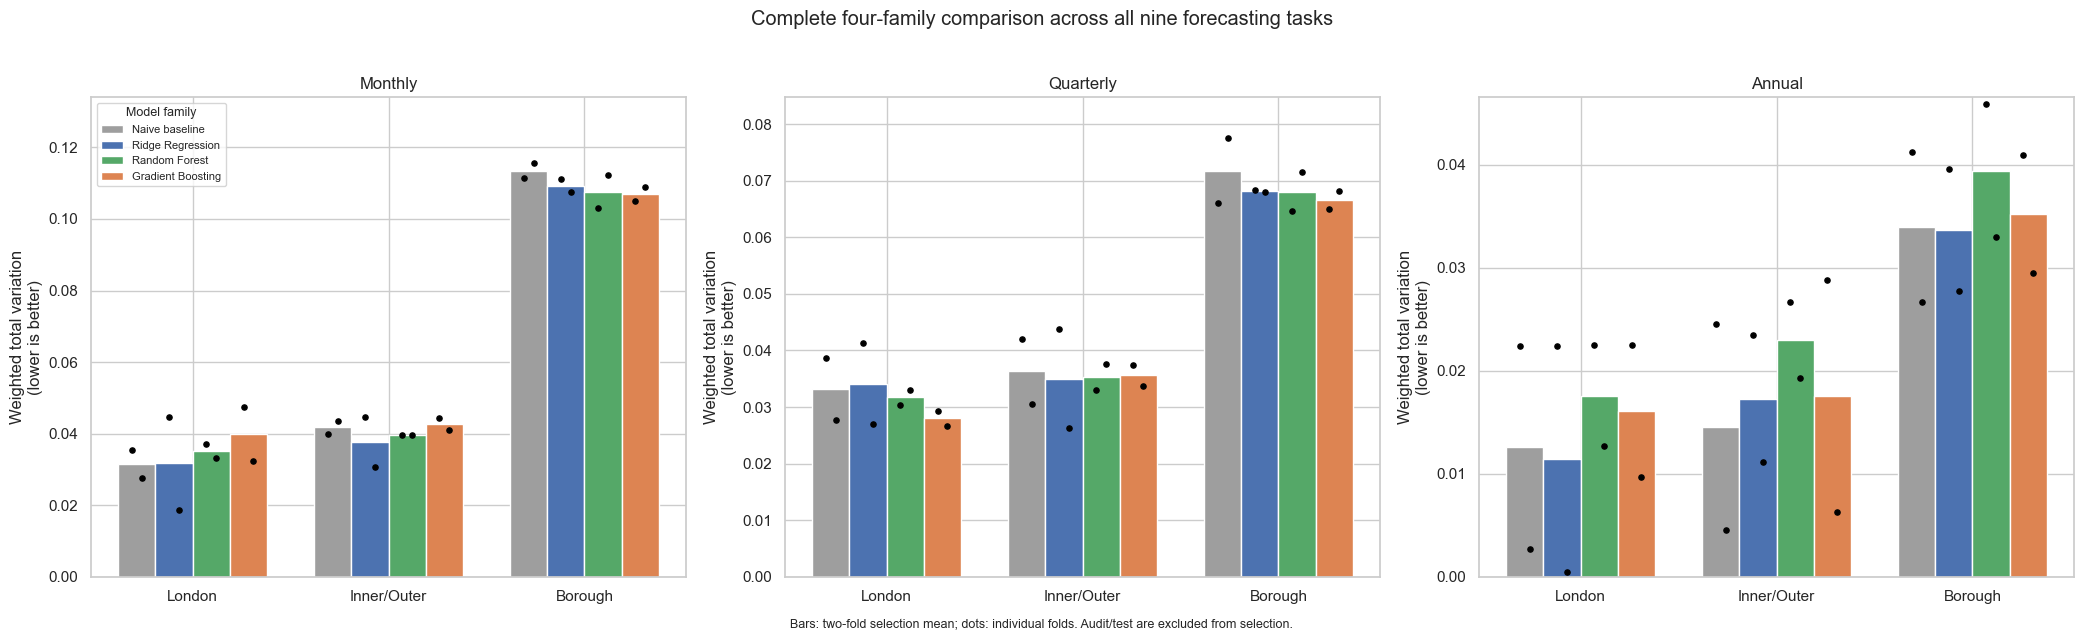

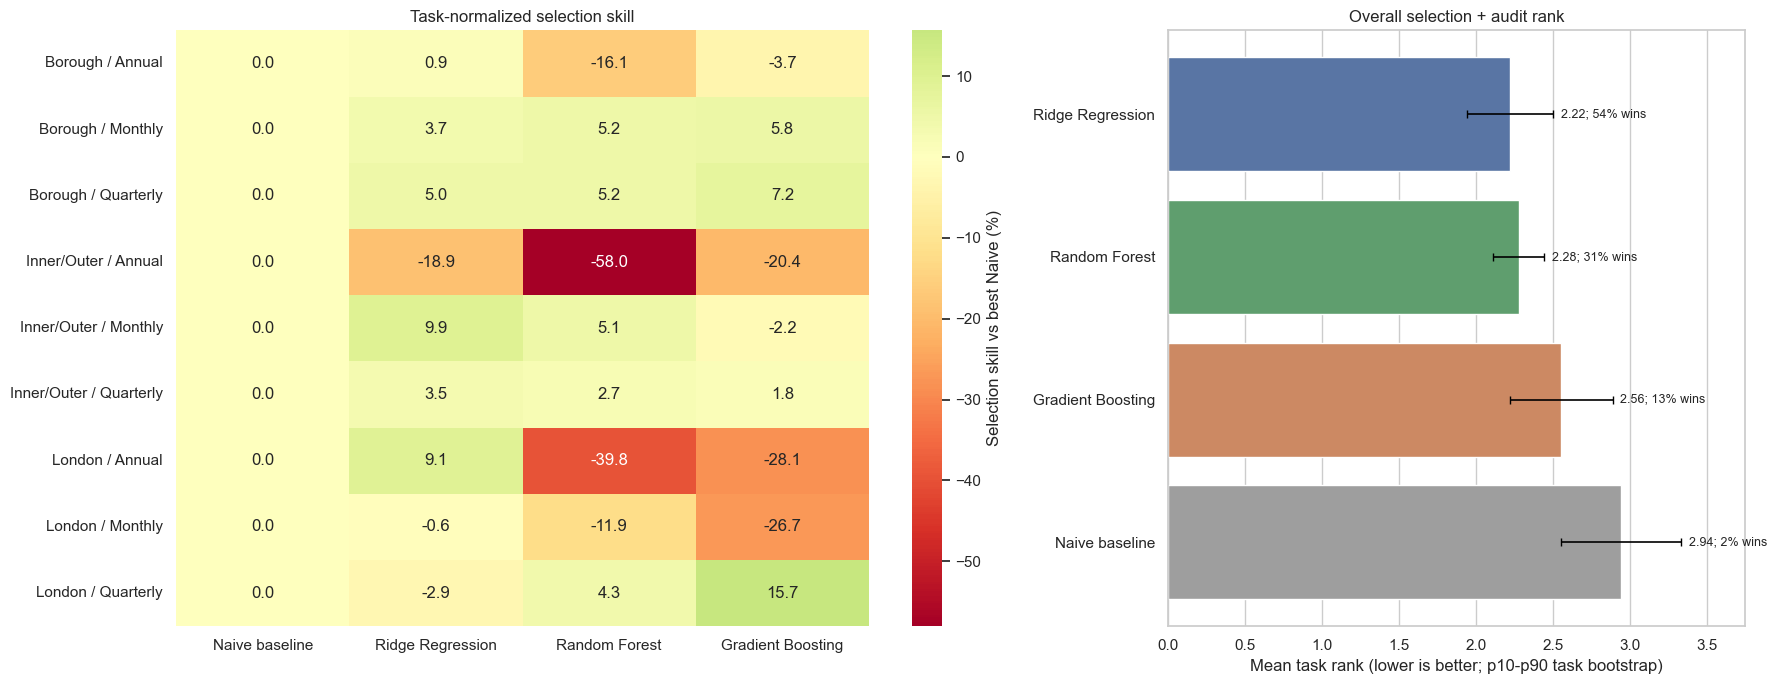

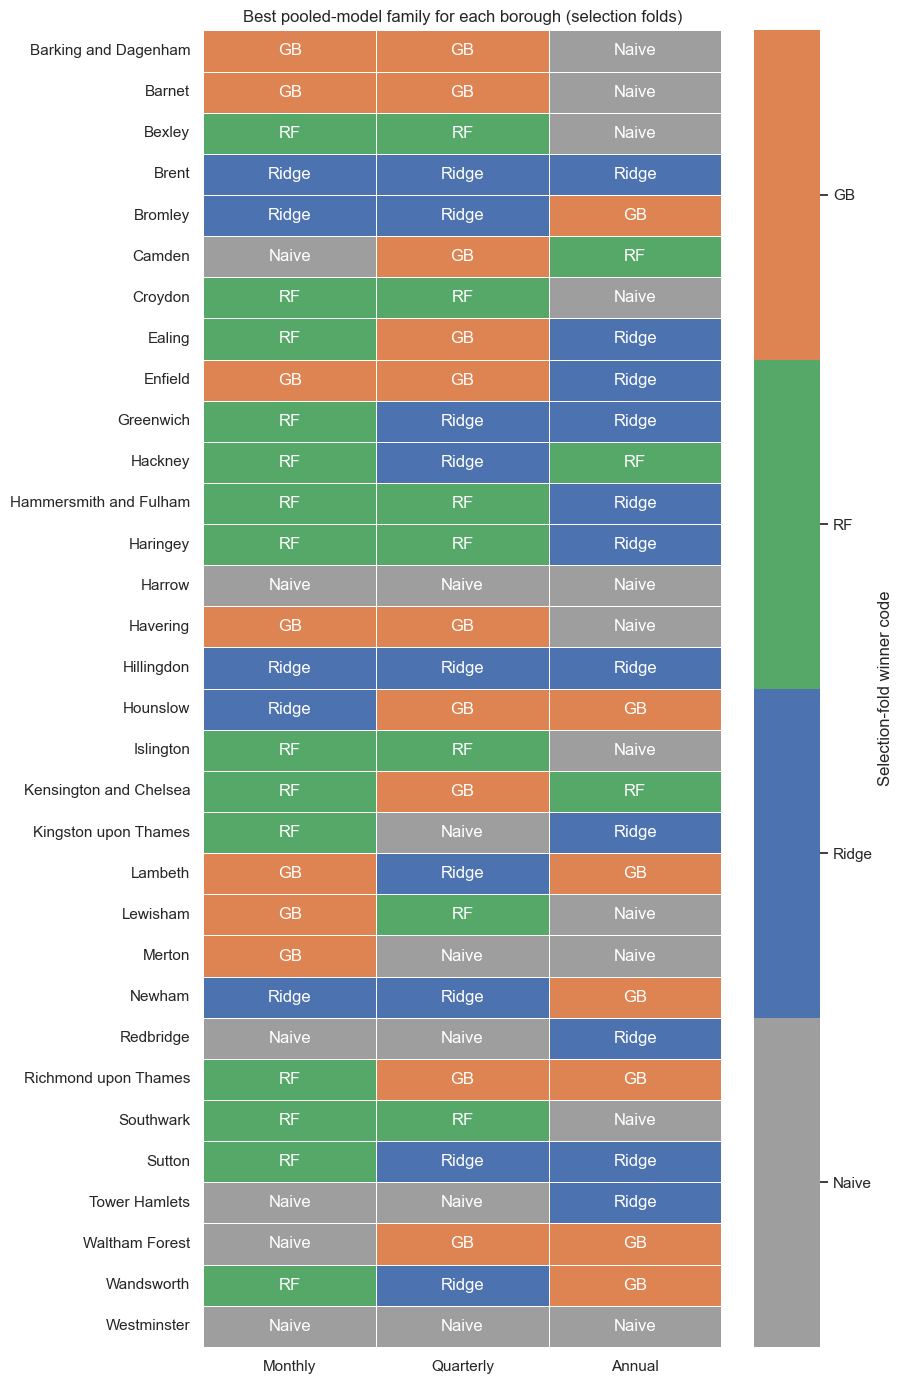

,geographic_level,frequency,selection_mean_winner,audit_winner,test_winner_descriptive_only,recommended_model_family,recommended_candidate,first_fold_training_rows,first_fold_training_periods,reliability_warning
0,Borough,Annual,Ridge Regression,Random Forest,Ridge Regression,Naive baseline,recent_mean,64,2,Severe: <=5 independent first-fold training pe...
1,Borough,Monthly,Gradient Boosting,Gradient Boosting,Gradient Boosting,Random Forest,rf_core_all_context_d4,1152,36,Standard comparison
2,Borough,Quarterly,Gradient Boosting,Ridge Regression,Ridge Regression,Ridge Regression,ridge_core_no_geography_a10,384,12,Moderate: <=12 independent first-fold training...
3,Inner/Outer,Annual,Naive baseline,Random Forest,Naive baseline,Naive baseline,last_observation,4,2,Severe: <=5 independent first-fold training pe...
4,Inner/Outer,Monthly,Ridge Regression,Random Forest,Ridge Regression,Naive baseline,last_observation,72,36,Standard comparison
5,Inner/Outer,Quarterly,Ridge Regression,Ridge Regression,Ridge Regression,Naive baseline,seasonal_naive,24,12,Moderate: <=12 independent first-fold training...
6,London,Annual,Ridge Regression,Random Forest,Naive baseline,Naive baseline,last_observation,2,2,Severe: <=5 independent first-fold training pe...
7,London,Monthly,Naive baseline,Random Forest,Random Forest,Naive baseline,last_observation,36,36,Standard comparison
8,London,Quarterly,Gradient Boosting,Ridge Regression,Naive baseline,Gradient Boosting,gb_core_d2,12,12,Moderate: <=12 independent first-fold training...


,model_family,tasks,mean_selection_rank,mean_audit_rank,mean_test_rank_descriptive,mean_selection_skill_vs_naive_pct,mean_audit_skill_vs_naive_pct,mean_selection_ratio_to_best,mean_audit_ratio_to_best,combined_development_rank,combined_development_excess_pct,overall_rank,scope
0,Gradient Boosting,9,2.556,2.556,2.778,-5.621,2.342,1.120,1.293,2.556,20.635,3.0,All 9 tasks
1,Naive baseline,9,2.667,3.222,2.667,0.000,0.000,1.064,1.310,2.944,18.741,4.0,All 9 tasks
2,Random Forest,9,2.778,1.778,2.889,-11.469,14.282,1.181,1.120,2.278,15.084,2.0,All 9 tasks
3,Ridge Regression,9,2.000,2.444,1.667,1.080,0.028,1.051,1.288,2.222,16.975,1.0,All 9 tasks
4,Gradient Boosting,6,2.333,2.500,2.500,0.267,5.438,1.070,1.278,2.417,17.407,3.0,Monthly + quarterly (6 tasks)
5,Naive baseline,6,3.167,3.667,3.167,0.000,0.000,1.078,1.323,3.417,20.058,4.0,Monthly + quarterly (6 tasks)
6,Random Forest,6,2.167,2.167,2.667,1.782,11.415,1.057,1.181,2.167,11.881,2.0,Monthly + quarterly (6 tasks)
7,Ridge Regression,6,2.333,1.667,1.667,3.108,20.472,1.045,1.026,2.000,3.570,1.0,Monthly + quarterly (6 tasks)


,frequency,model_family,boroughs_won
0,Annual,Gradient Boosting,7
1,Annual,Naive baseline,11
2,Annual,Random Forest,3
3,Annual,Ridge Regression,11
4,Monthly,Gradient Boosting,7
5,Monthly,Naive baseline,6
6,Monthly,Random Forest,14
7,Monthly,Ridge Regression,5
8,Quarterly,Gradient Boosting,10
9,Quarterly,Naive baseline,6


In [7]:
MODEL_FAMILY_ORDER = ['Naive baseline', 'Ridge Regression', 'Random Forest', 'Gradient Boosting']
MODEL_FAMILY_COLORS = {
    'Naive baseline': '#9e9e9e', 'Ridge Regression': '#4c72b0',
    'Random Forest': '#55a868', 'Gradient Boosting': '#dd8452',
}
baseline_algorithms = {
    'Last observation', 'Seasonal naive', 'Recent mean',
    'Exponentially weighted history', 'Local drift',
}


def to_model_family(algorithm):
    if algorithm in baseline_algorithms:
        return 'Naive baseline'
    return 'Ridge Regression' if algorithm == 'Ridge' else algorithm


# Freeze the best prespecified candidate inside each family using selection folds only.
family_candidates = candidate_summary.copy()
family_candidates['model_family'] = family_candidates['algorithm'].map(to_model_family)
model_family_comparison = family_candidates.sort_values(
    ['geographic_level', 'frequency', 'model_family', 'mean_weighted_tv', 'complexity']
).groupby(['geographic_level', 'frequency', 'model_family'], as_index=False).first()
assert model_family_comparison.groupby(
    ['geographic_level', 'frequency']
)['model_family'].nunique().eq(4).all(), 'Every task must contain all four model families.'
model_family_comparison.rename(columns={'mean_weighted_tv': 'selection_weighted_tv'}, inplace=True)

family_id_lookup = model_family_comparison[[
    'geographic_level', 'frequency', 'model_family', 'candidate_id'
]]
family_fold_metrics = selection_fold_metrics.merge(
    family_id_lookup,
    on=['geographic_level', 'frequency', 'candidate_id'], validate='many_to_one',
)

# Evaluate every frozen family finalist on audit and test; neither phase chooses the finalist.
family_phase_rows, family_phase_prediction_parts = [], []
for (level, frequency), result in task_results.items():
    lookup = {candidate['candidate_id']: candidate for candidate in result['candidates']}
    finalists = model_family_comparison.loc[
        model_family_comparison['geographic_level'].eq(level)
        & model_family_comparison['frequency'].eq(frequency)
    ]
    for _, finalist in finalists.iterrows():
        candidate = lookup[finalist['candidate_id']]
        for phase in ['audit', 'test']:
            metrics, predictions, _, _, _ = evaluate_phase(
                result['panel'], result['feature_sets'], candidate, result['design'], phase
            )
            family_phase_rows.append({
                'geographic_level': level, 'frequency': frequency,
                'model_family': finalist['model_family'],
                'candidate_id': candidate['candidate_id'], 'phase': phase,
                **metrics,
            })
            family_phase_prediction_parts.append(predictions.assign(
                geographic_level=level, frequency=frequency,
                model_family=finalist['model_family'],
            ))
model_family_phase_metrics = pd.DataFrame(family_phase_rows)
model_family_phase_predictions = pd.concat(family_phase_prediction_parts, ignore_index=True)

phase_tv = model_family_phase_metrics.pivot(
    index=['geographic_level', 'frequency', 'model_family', 'candidate_id'],
    columns='phase', values='weighted_total_variation',
).reset_index().rename(columns={'audit': 'audit_weighted_tv', 'test': 'test_weighted_tv'})
model_family_task_summary = model_family_comparison.merge(
    phase_tv,
    on=['geographic_level', 'frequency', 'model_family', 'candidate_id'],
    validate='one_to_one',
)

for phase in ['selection', 'audit', 'test']:
    value = f'{phase}_weighted_tv'
    task_keys = ['geographic_level', 'frequency']
    model_family_task_summary[f'{phase}_rank'] = model_family_task_summary.groupby(
        task_keys
    )[value].rank(method='min')
    model_family_task_summary[f'{phase}_ratio_to_best'] = (
        model_family_task_summary[value]
        / model_family_task_summary.groupby(task_keys)[value].transform('min')
    )
    naive = model_family_task_summary.loc[
        model_family_task_summary['model_family'].eq('Naive baseline'),
        [*task_keys, value],
    ].rename(columns={value: f'{phase}_naive_tv'})
    model_family_task_summary = model_family_task_summary.merge(
        naive, on=task_keys, validate='many_to_one'
    )
    model_family_task_summary[f'{phase}_skill_vs_naive_pct'] = 100 * (
        1 - model_family_task_summary[value]
        / model_family_task_summary[f'{phase}_naive_tv']
    )

selected_families = selection_register[[
    'geographic_level', 'frequency', 'selected_candidate', 'selected_algorithm',
    'minimum_first_fold_training_rows', 'minimum_first_fold_training_periods',
]].copy()
selected_families['recommended_model_family'] = selected_families['selected_algorithm'].map(to_model_family)
recommendation_rows = []
for (level, frequency), group in model_family_task_summary.groupby(['geographic_level', 'frequency']):
    selected = selected_families.loc[
        selected_families['geographic_level'].eq(level)
        & selected_families['frequency'].eq(frequency)
    ].iloc[0]
    periods = int(selected['minimum_first_fold_training_periods'])
    warning = (
        'Severe: <=5 independent first-fold training periods; ranking is descriptive only'
        if periods <= 5 else
        'Moderate: <=12 independent first-fold training periods; shallow trees only'
        if periods <= 12 else 'Standard comparison'
    )
    recommendation_rows.append({
        'geographic_level': level, 'frequency': frequency,
        'selection_mean_winner': group.loc[group['selection_weighted_tv'].idxmin(), 'model_family'],
        'audit_winner': group.loc[group['audit_weighted_tv'].idxmin(), 'model_family'],
        'test_winner_descriptive_only': group.loc[group['test_weighted_tv'].idxmin(), 'model_family'],
        'recommended_model_family': selected['recommended_model_family'],
        'recommended_candidate': selected['selected_candidate'],
        'first_fold_training_rows': int(selected['minimum_first_fold_training_rows']),
        'first_fold_training_periods': periods,
        'reliability_warning': warning,
    })
model_family_task_recommendations = pd.DataFrame(recommendation_rows)

# Overall ranking gives every task equal weight after within-task normalization.
overall_parts = []
for scope, frequencies in [
    ('All 9 tasks', ['Monthly', 'Quarterly', 'Annual']),
    ('Monthly + quarterly (6 tasks)', ['Monthly', 'Quarterly']),
]:
    local = model_family_task_summary.loc[
        model_family_task_summary['frequency'].isin(frequencies)
    ]
    summary = local.groupby('model_family', as_index=False).agg(
        tasks=('frequency', 'size'),
        mean_selection_rank=('selection_rank', 'mean'),
        mean_audit_rank=('audit_rank', 'mean'),
        mean_test_rank_descriptive=('test_rank', 'mean'),
        mean_selection_skill_vs_naive_pct=('selection_skill_vs_naive_pct', 'mean'),
        mean_audit_skill_vs_naive_pct=('audit_skill_vs_naive_pct', 'mean'),
        mean_selection_ratio_to_best=('selection_ratio_to_best', 'mean'),
        mean_audit_ratio_to_best=('audit_ratio_to_best', 'mean'),
    )
    summary['combined_development_rank'] = (
        summary['mean_selection_rank'] + summary['mean_audit_rank']
    ) / 2
    summary['combined_development_excess_pct'] = 50 * (
        summary['mean_selection_ratio_to_best'] + summary['mean_audit_ratio_to_best'] - 2
    )
    summary['overall_rank'] = summary['combined_development_rank'].rank(method='min')
    summary['scope'] = scope
    overall_parts.append(summary)
model_family_overall = pd.concat(overall_parts, ignore_index=True)

# Task-bootstrap and leave-one-task-out stability for the overall development rank.
stability_rows = []
for scope, frequencies in [
    ('All 9 tasks', ['Monthly', 'Quarterly', 'Annual']),
    ('Monthly + quarterly (6 tasks)', ['Monthly', 'Quarterly']),
]:
    local = model_family_task_summary.loc[
        model_family_task_summary['frequency'].isin(frequencies)
    ].copy()
    local['development_rank'] = (local['selection_rank'] + local['audit_rank']) / 2
    rank_matrix = local.assign(
        task=lambda x: x['geographic_level'] + ' / ' + x['frequency']
    ).pivot(index='task', columns='model_family', values='development_rank').reindex(
        columns=MODEL_FAMILY_ORDER
    )
    values = rank_matrix.to_numpy()
    rng = np.random.default_rng(RANDOM_STATE + len(frequencies))
    sampled_indices = rng.integers(0, len(values), size=(5000, len(values)))
    bootstrap_scores = values[sampled_indices].mean(axis=1)
    winning = np.isclose(
        bootstrap_scores, bootstrap_scores.min(axis=1, keepdims=True), atol=1e-12
    )
    fractional_wins = winning / winning.sum(axis=1, keepdims=True)
    leave_one_out_scores = np.stack([
        np.delete(values, omitted, axis=0).mean(axis=0)
        for omitted in range(len(values))
    ])
    leave_one_out_winning = np.isclose(
        leave_one_out_scores, leave_one_out_scores.min(axis=1, keepdims=True), atol=1e-12
    )
    leave_one_out_fractional = (
        leave_one_out_winning
        / leave_one_out_winning.sum(axis=1, keepdims=True)
    )
    for index, family in enumerate(MODEL_FAMILY_ORDER):
        stability_rows.append({
            'scope': scope, 'model_family': family,
            'task_bootstrap_repeats': 5000,
            'bootstrap_mean_rank': bootstrap_scores[:, index].mean(),
            'bootstrap_rank_p10': np.quantile(bootstrap_scores[:, index], .10),
            'bootstrap_rank_p90': np.quantile(bootstrap_scores[:, index], .90),
            'bootstrap_winner_share': fractional_wins[:, index].mean(),
            'leave_one_task_out_runs': len(values),
            'leave_one_task_out_winner_share': leave_one_out_fractional[:, index].mean(),
        })
model_family_stability = pd.DataFrame(stability_rows)

# Per-borough diagnostics evaluate the frozen pooled-borough family finalist for every borough.
borough_family_ids = family_id_lookup.loc[
    family_id_lookup['geographic_level'].eq('Borough')
]
borough_family_predictions = selection_predictions.loc[
    selection_predictions['geographic_level'].eq('Borough')
].merge(
    borough_family_ids[['frequency', 'model_family', 'candidate_id']],
    on=['frequency', 'candidate_id'], validate='many_to_one',
)
borough_model_comparison = borough_family_predictions.groupby(
    ['frequency', 'geography_code', 'geography_name', 'model_family'], as_index=False
).apply(
    lambda group: pd.Series({
        'selection_weighted_tv': weighted_mean(
            group['row_total_variation'], group['effective_n']
        ),
        'observations': len(group), 'folds': group['fold'].nunique(),
    }), include_groups=False,
).reset_index(drop=True)
borough_model_winners = borough_model_comparison.sort_values(
    ['frequency', 'geography_code', 'selection_weighted_tv']
).groupby(['frequency', 'geography_code'], as_index=False).first()
borough_model_win_counts = borough_model_winners.groupby(
    ['frequency', 'model_family'], as_index=False
).agg(boroughs_won=('geography_code', 'size'))

# Figure 1: all nine task-level comparisons, with individual selection folds.
geography_order = ['London', 'Inner/Outer', 'Borough']
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
width = .19
offsets = np.linspace(-1.5 * width, 1.5 * width, 4)
for ax, frequency in zip(axes, ['Monthly', 'Quarterly', 'Annual']):
    local = model_family_task_summary.loc[
        model_family_task_summary['frequency'].eq(frequency)
    ]
    for offset, family in zip(offsets, MODEL_FAMILY_ORDER):
        family_local = local.loc[local['model_family'].eq(family)].set_index(
            'geographic_level'
        ).reindex(geography_order)
        x = np.arange(3) + offset
        bars = ax.bar(
            x, family_local['selection_weighted_tv'], width=width,
            color=MODEL_FAMILY_COLORS[family], label=family,
        )
        for position, level in enumerate(geography_order):
            fold_values = family_fold_metrics.loc[
                family_fold_metrics['frequency'].eq(frequency)
                & family_fold_metrics['geographic_level'].eq(level)
                & family_fold_metrics['model_family'].eq(family),
                'weighted_total_variation',
            ].to_numpy()
            jitter = np.linspace(-.025, .025, len(fold_values))
            ax.scatter(position + offset + jitter, fold_values, s=14, color='black', zorder=3)
    ax.set_xticks(range(3), geography_order)
    ax.set(title=frequency, xlabel='',
           ylabel='Weighted total variation\n(lower is better)')
    ax.set_ylim(0, local['selection_weighted_tv'].max() * 1.18)
axes[0].legend(title='Model family', fontsize=8, title_fontsize=9)
fig.suptitle('Complete four-family comparison across all nine forecasting tasks', y=1.02)
fig.text(.5, -.01, 'Bars: two-fold selection mean; dots: individual folds. Audit/test are excluded from selection.',
         ha='center', fontsize=9)
fig.tight_layout()
save_figure(fig, 'forecast_model_family_comparison.png')
plt.show()

# Figure 2: task-normalized skill and overall development rank.
task_labels = model_family_task_summary.assign(
    task=lambda x: x['geographic_level'] + ' / ' + x['frequency']
)
skill_heat = task_labels.pivot(
    index='task', columns='model_family', values='selection_skill_vs_naive_pct'
).reindex(columns=MODEL_FAMILY_ORDER)
fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1.5, 1]})
sns.heatmap(
    skill_heat, annot=True, fmt='.1f', center=0, cmap='RdYlGn',
    cbar_kws={'label': 'Selection skill vs best Naive (%)'}, ax=axes[0],
)
axes[0].set(title='Task-normalized selection skill', xlabel='', ylabel='')
overall_all = model_family_overall.loc[
    model_family_overall['scope'].eq('All 9 tasks')
].sort_values('combined_development_rank')
overall_order = overall_all['model_family'].tolist()
sns.barplot(
    data=overall_all, y='model_family', x='combined_development_rank', order=overall_order,
    hue='model_family', palette=MODEL_FAMILY_COLORS, legend=False, errorbar=None, ax=axes[1],
)
stability_all = model_family_stability.loc[
    model_family_stability['scope'].eq('All 9 tasks')
].set_index('model_family').reindex(overall_order)
for position, family in enumerate(overall_order):
    point = overall_all.set_index('model_family').loc[family, 'combined_development_rank']
    low = stability_all.loc[family, 'bootstrap_rank_p10']
    high = stability_all.loc[family, 'bootstrap_rank_p90']
    axes[1].errorbar(
        point, position, xerr=[[point - low], [high - point]],
        fmt='none', color='black', capsize=3, linewidth=1.2,
    )
    axes[1].text(
        max(point, high) + .05, position,
        f"{point:.2f}; {stability_all.loc[family, 'bootstrap_winner_share']:.0%} wins",
        va='center', fontsize=9,
    )
axes[1].set(
    title='Overall selection + audit rank',
    xlabel='Mean task rank (lower is better; p10-p90 task bootstrap)', ylabel='',
)
axes[1].set_xlim(0, 3.75)
fig.tight_layout()
save_figure(fig, 'forecast_model_family_overall.png')
plt.show()

# Figure 3: diagnostic winner for each borough and frequency.
winner_codes = {family: index for index, family in enumerate(MODEL_FAMILY_ORDER)}
winner_matrix = borough_model_winners.assign(
    winner_code=lambda x: x['model_family'].map(winner_codes)
).pivot(index='geography_name', columns='frequency', values='winner_code').reindex(
    columns=['Monthly', 'Quarterly', 'Annual']
)
winner_labels = winner_matrix.replace({
    0: 'Naive', 1: 'Ridge', 2: 'RF', 3: 'GB',
})
from matplotlib.colors import ListedColormap
fig, ax = plt.subplots(figsize=(9, 14))
sns.heatmap(
    winner_matrix, annot=winner_labels, fmt='', linewidths=.4,
    cmap=ListedColormap([MODEL_FAMILY_COLORS[x] for x in MODEL_FAMILY_ORDER]),
    vmin=-.5, vmax=3.5, cbar_kws={
        'ticks': range(4), 'label': 'Selection-fold winner code'
    }, ax=ax,
)
colorbar = ax.collections[0].colorbar
colorbar.set_ticklabels(['Naive', 'Ridge', 'RF', 'GB'])
ax.set(title='Best pooled-model family for each borough (selection folds)', xlabel='', ylabel='')
fig.tight_layout()
save_figure(fig, 'forecast_borough_model_family_winners.png')
plt.show()

display(model_family_task_recommendations)
display(model_family_overall.round(3))
display(borough_model_win_counts)


### Final model recommendations and overall result

The one-standard-error recommendations are: Naive for London monthly, Inner/Outer monthly,
Inner/Outer quarterly and all three annual tasks; Random Forest for borough monthly; Gradient
Boosting for London quarterly; and Ridge for borough quarterly. The workbook also preserves the
lowest selection mean, independent audit winner and descriptive test winner, so disagreements are
visible rather than rewritten after seeing the test.

Across all nine tasks, equal-weight selection-plus-audit mean rank places **Ridge first (2.22)**,
Random Forest second (2.28), Gradient Boosting third (2.56) and Naive fourth (2.94). Across only the
six monthly/quarterly tasks Ridge remains first (2.00). The task bootstrap is reported because the
Ridge/Random-Forest gap is small; “overall best” means the most consistently ranked development
family, not a universal winner for every geography or frequency.

Per-borough winners evaluate the four frozen pooled-borough finalists separately for each of the 32
boroughs. They reveal heterogeneity but do not create a 32-model hybrid: monthly/quarterly cells are
noisy, while each annual borough ranking uses only two selection years.


### Selection safeguards

The warm-up audit and sample-consistency assertion demonstrate that structural lag rows do not
enter training and that Naive/ML candidates are scored on identical observations. Candidate tables
retain fold-level results, one-standard-error thresholds and Random Forest/Gradient Boosting seed
sensitivity. Complex algorithms are fitted everywhere, while short annual series remain explicitly
flagged rather than silently excluded.

The one-standard-error rule selects transparent baselines for six of nine tasks: London and
Inner/Outer monthly use the previous-period composition; Inner/Outer quarterly uses seasonal naive;
London and Inner/Outer annual use the previous year; borough annual uses the recent mean. The three
ML recommendations are borough monthly Random Forest, London quarterly Gradient Boosting and
borough quarterly no-geography Ridge. London annual starts with only two independent training years,
so its four-family ordering is reported but remains descriptive rather than defensible evidence of
algorithmic superiority.

## 5. Precision-weighted test accuracy, survey-noise floor and uncertainty

The final test is used once for accuracy reporting. Signed bias is reported for every category.
R-squared is suppressed unless the test contains at least eight independent time periods. A survey
noise floor based on `p(1-p)/effective_n` is shown separately from noise-adjusted RMSE; it is an
approximation because the full complex-survey design variance is unavailable.

Uncertainty uses development predictions only. A block-calibrated total-variation radius defines a
joint region on the simplex. Marginal bands are stratified by effective-sample-size tier for plots,
but are not mislabelled as a simultaneous composition region. Annual intervals are withheld because
fewer than eight calibration time blocks are available.

In [8]:
selected_test_metrics = test_metrics.merge(
    selection_register[['geographic_level', 'frequency', 'selected_candidate']],
    left_on=['geographic_level', 'frequency', 'candidate_id'],
    right_on=['geographic_level', 'frequency', 'selected_candidate'],
    validate='many_to_one',
)
selected_audit_metrics = audit_metrics.merge(
    selection_register[['geographic_level', 'frequency', 'selected_candidate']],
    left_on=['geographic_level', 'frequency', 'candidate_id'],
    right_on=['geographic_level', 'frequency', 'selected_candidate'],
    validate='many_to_one',
)
selected_test_predictions = test_predictions.merge(
    selection_register[['geographic_level', 'frequency', 'selected_candidate']],
    left_on=['geographic_level', 'frequency', 'candidate_id'],
    right_on=['geographic_level', 'frequency', 'selected_candidate'],
    validate='many_to_one',
)
selected_audit_predictions = audit_predictions.merge(
    selection_register[['geographic_level', 'frequency', 'selected_candidate']],
    left_on=['geographic_level', 'frequency', 'candidate_id'],
    right_on=['geographic_level', 'frequency', 'selected_candidate'],
    validate='many_to_one',
)

skill_rows = []
for (level, frequency), selected in selected_test_predictions.groupby(['geographic_level', 'frequency']):
    time_column = TASK_DESIGNS[frequency]['time']
    seasonal = test_predictions.loc[
        test_predictions['geographic_level'].eq(level)
        & test_predictions['frequency'].eq(frequency)
        & test_predictions['candidate_id'].eq('seasonal_naive')
    ]
    keys = [time_column, 'geography_code']
    comparison = selected.merge(
        seasonal[keys + ['row_total_variation']].rename(
            columns={'row_total_variation': 'seasonal_row_tv'}
        ), on=keys, validate='one_to_one'
    )
    model_tv = weighted_mean(comparison['row_total_variation'], comparison['effective_n'])
    naive_tv = weighted_mean(comparison['seasonal_row_tv'], comparison['effective_n'])
    periods = np.sort(comparison[time_column].unique())
    row = {
        'geographic_level': level, 'frequency': frequency,
        'test_time_periods': len(periods),
        'selected_weighted_tv': model_tv, 'seasonal_weighted_tv': naive_tv,
        'skill_vs_seasonal': 1 - model_tv / naive_tv if naive_tv > 0 else np.nan,
    }
    if len(periods) >= 4:
        rng = np.random.default_rng(RANDOM_STATE + len(level) + len(frequency))
        bootstrap_skill = []
        for _ in range(1000):
            sampled = rng.choice(periods, size=len(periods), replace=True)
            pieces = [comparison.loc[comparison[time_column].eq(period)] for period in sampled]
            boot = pd.concat(pieces, ignore_index=True)
            m = weighted_mean(boot['row_total_variation'], boot['effective_n'])
            n = weighted_mean(boot['seasonal_row_tv'], boot['effective_n'])
            bootstrap_skill.append(1 - m / n if n > 0 else np.nan)
        row['skill_ci_low'] = np.nanquantile(bootstrap_skill, .025)
        row['skill_ci_high'] = np.nanquantile(bootstrap_skill, .975)
        row['skill_interval_status'] = 'Very low precision' if len(periods) < 8 else 'Block bootstrap'
    else:
        row['skill_ci_low'] = row['skill_ci_high'] = np.nan
        row['skill_interval_status'] = 'Insufficient independent test periods'
    skill_rows.append(row)
test_skill = pd.DataFrame(skill_rows)

calibration_parts = []
for (level, frequency), result in task_results.items():
    selected_id = result['selected_id']
    selection = result['selection_predictions'].loc[
        result['selection_predictions']['candidate_id'].eq(selected_id)
    ].copy()
    audit = result['audit']['predictions'].loc[
        result['audit']['predictions']['candidate_id'].eq(selected_id)
    ].copy()
    calibration_parts.append(pd.concat([selection, audit], ignore_index=True).assign(
        geographic_level=level, frequency=frequency
    ))
calibration_predictions = pd.concat(calibration_parts, ignore_index=True)

band_parts, interval_rows = [], []
for (level, frequency), test in selected_test_predictions.groupby(['geographic_level', 'frequency']):
    calibration = calibration_predictions.loc[
        calibration_predictions['geographic_level'].eq(level)
        & calibration_predictions['frequency'].eq(frequency)
    ].copy()
    time_column = TASK_DESIGNS[frequency]['time']
    blocks = calibration[time_column].nunique()
    output = test.copy()
    if blocks < 8:
        for target in TARGETS:
            output[f'band_low_{target}'] = np.nan
            output[f'band_high_{target}'] = np.nan
        interval_rows.append({
            'geographic_level': level, 'frequency': frequency,
            'calibration_time_blocks': blocks, 'joint_tv_radius': np.nan,
            'joint_test_coverage': np.nan,
            'status': 'Withheld: fewer than 8 calibration time blocks',
        })
        band_parts.append(output)
        continue

    block_scores = calibration.groupby(time_column)['row_total_variation'].quantile(.90)
    quantile_level = min(1, np.ceil((len(block_scores) + 1) * .90) / len(block_scores))
    joint_radius = block_scores.quantile(quantile_level, interpolation='higher')

    thresholds = calibration['effective_n'].quantile([1/3, 2/3]).to_numpy()
    def tier(values):
        return pd.cut(values, [-np.inf, thresholds[0], thresholds[1], np.inf],
                      labels=['low', 'middle', 'high'], include_lowest=True)
    calibration['precision_tier'] = tier(calibration['effective_n'])
    output['precision_tier'] = tier(output['effective_n'])
    for target in TARGETS:
        residual = calibration[target] - calibration[f'predicted_{target}']
        overall_low, overall_high = residual.quantile([.05, .95])
        low_values, high_values = [], []
        for _, row in output.iterrows():
            local = residual.loc[calibration['precision_tier'].eq(row['precision_tier'])]
            if len(local) < 20:
                q_low, q_high = overall_low, overall_high
            else:
                q_low, q_high = local.quantile([.05, .95])
            low_values.append(max(0, row[f'predicted_{target}'] + q_low))
            high_values.append(min(1, row[f'predicted_{target}'] + q_high))
        output[f'band_low_{target}'] = low_values
        output[f'band_high_{target}'] = high_values
    interval_rows.append({
        'geographic_level': level, 'frequency': frequency,
        'calibration_time_blocks': blocks, 'joint_tv_radius': joint_radius,
        'joint_test_coverage': output['row_total_variation'].le(joint_radius).mean(),
        'status': '90% block-calibrated TV region; marginal bands precision-stratified',
    })
    band_parts.append(output)

band_predictions = pd.concat(band_parts, ignore_index=True)
interval_diagnostics = pd.DataFrame(interval_rows)
display(selected_test_metrics)
display(test_skill)
display(interval_diagnostics)

,candidate_id,algorithm,observations,time_periods,weighted_total_variation,unweighted_total_variation,inactive_rate_weighted_mae,inactive_rate_weighted_rmse,inactive_rate_signed_bias,inactive_rate_survey_noise_floor_rmse,inactive_rate_noise_adjusted_rmse,inactive_rate_weighted_r2,fairly_active_rate_weighted_mae,fairly_active_rate_weighted_rmse,fairly_active_rate_signed_bias,fairly_active_rate_survey_noise_floor_rmse,fairly_active_rate_noise_adjusted_rmse,fairly_active_rate_weighted_r2,active_rate_weighted_mae,active_rate_weighted_rmse,active_rate_signed_bias,active_rate_survey_noise_floor_rmse,active_rate_noise_adjusted_rmse,active_rate_weighted_r2,geographic_level,frequency,selected_candidate
0,last_observation,Last observation,12,12,0.032736,0.034620,0.023722,0.031258,0.001377,0.015436,0.027180,-0.181799,0.016042,0.017840,-0.000378,0.010787,0.014209,-1.297841,0.025707,0.034462,-0.000998,0.017133,0.029901,0.014880,London,Monthly,last_observation
1,last_observation,Last observation,24,12,0.038693,0.040577,0.028355,0.037197,0.000928,0.021605,0.030280,-0.013014,0.017532,0.019256,-0.000209,0.015112,0.011934,-0.214851,0.031499,0.039246,-0.000720,0.024015,0.031041,0.247417,Inner/Outer,Monthly,last_observation
2,rf_core_all_context_d4,Random Forest,384,12,0.106084,0.107938,0.075598,0.097279,-0.015845,0.079602,0.055918,0.124003,0.047474,0.062760,-0.025006,0.056402,0.027525,-0.187624,0.089096,0.112397,0.040850,0.088565,0.069204,0.049890,Borough,Monthly,rf_core_all_context_d4
3,gb_core_d2,Gradient Boosting,4,4,0.019931,0.020108,0.014209,0.016388,0.000115,0.009003,0.013694,NaN,0.009974,0.012317,0.005982,0.006296,0.010586,NaN,0.015679,0.021488,-0.006097,0.009995,0.019022,NaN,London,Quarterly,gb_core_d2
4,seasonal_naive,Seasonal naive,8,4,0.021612,0.022478,0.016966,0.019911,-0.004302,0.012621,0.015400,NaN,0.015120,0.018794,0.004290,0.008833,0.016589,NaN,0.011138,0.016058,0.000012,0.014031,0.007809,NaN,Inner/Outer,Quarterly,seasonal_naive
5,ridge_core_no_geography_a10,Ridge,128,4,0.068566,0.070147,0.050372,0.063559,-0.010519,0.047903,0.041773,NaN,0.028300,0.035590,-0.012136,0.033941,0.010710,NaN,0.058460,0.072590,0.022655,0.053253,0.049329,NaN,Borough,Quarterly,ridge_core_no_geography_a10
6,last_observation,Last observation,1,1,0.006625,0.006625,0.006625,0.006625,-0.006625,0.004316,0.005026,NaN,0.005179,0.005179,0.005179,0.003012,0.004212,NaN,0.001446,0.001446,0.001446,0.004787,0.000000,NaN,London,Annual,last_observation
7,last_observation,Last observation,2,1,0.007042,0.008014,0.005866,0.006989,-0.005866,0.006058,0.003485,NaN,0.005429,0.008442,0.005340,0.004229,0.007306,NaN,0.002789,0.002789,0.000526,0.006728,0.000000,NaN,Inner/Outer,Annual,last_observation
8,recent_mean,Recent mean,32,1,0.035168,0.035626,0.025568,0.034648,0.000996,0.023438,0.025517,NaN,0.016339,0.020748,0.006024,0.016509,0.012567,NaN,0.028429,0.035532,-0.007020,0.026019,0.024197,NaN,Borough,Annual,recent_mean


,geographic_level,frequency,test_time_periods,selected_weighted_tv,seasonal_weighted_tv,skill_vs_seasonal,skill_ci_low,skill_ci_high,skill_interval_status
0,Borough,Annual,1,0.035168,0.041780,0.158266,NaN,NaN,Insufficient independent test periods
1,Borough,Monthly,12,0.106084,0.139421,0.239115,0.187705,0.286633,Block bootstrap
2,Borough,Quarterly,4,0.068566,0.086368,0.206124,0.118276,0.285457,Very low precision
3,Inner/Outer,Annual,1,0.007042,0.007042,0.000000,NaN,NaN,Insufficient independent test periods
4,Inner/Outer,Monthly,12,0.038693,0.038869,0.004535,-0.263868,0.239634,Block bootstrap
5,Inner/Outer,Quarterly,4,0.021612,0.021612,0.000000,0.000000,0.000000,Very low precision
6,London,Annual,1,0.006625,0.006625,0.000000,NaN,NaN,Insufficient independent test periods
7,London,Monthly,12,0.032736,0.025063,-0.306155,-0.629464,-0.083484,Block bootstrap
8,London,Quarterly,4,0.019931,0.014188,-0.404814,-2.568047,0.302920,Very low precision


,geographic_level,frequency,calibration_time_blocks,joint_tv_radius,joint_test_coverage,status
0,Borough,Annual,3,NaN,NaN,Withheld: fewer than 8 calibration time blocks
1,Borough,Monthly,36,0.273543,0.976562,90% block-calibrated TV region; marginal bands...
2,Borough,Quarterly,12,0.148941,0.929688,90% block-calibrated TV region; marginal bands...
3,Inner/Outer,Annual,3,NaN,NaN,Withheld: fewer than 8 calibration time blocks
4,Inner/Outer,Monthly,36,0.085054,0.916667,90% block-calibrated TV region; marginal bands...
5,Inner/Outer,Quarterly,12,0.080699,1.000000,90% block-calibrated TV region; marginal bands...
6,London,Annual,3,NaN,NaN,Withheld: fewer than 8 calibration time blocks
7,London,Monthly,36,0.059507,0.916667,90% block-calibrated TV region; marginal bands...
8,London,Quarterly,12,0.060313,1.000000,90% block-calibrated TV region; marginal bands...


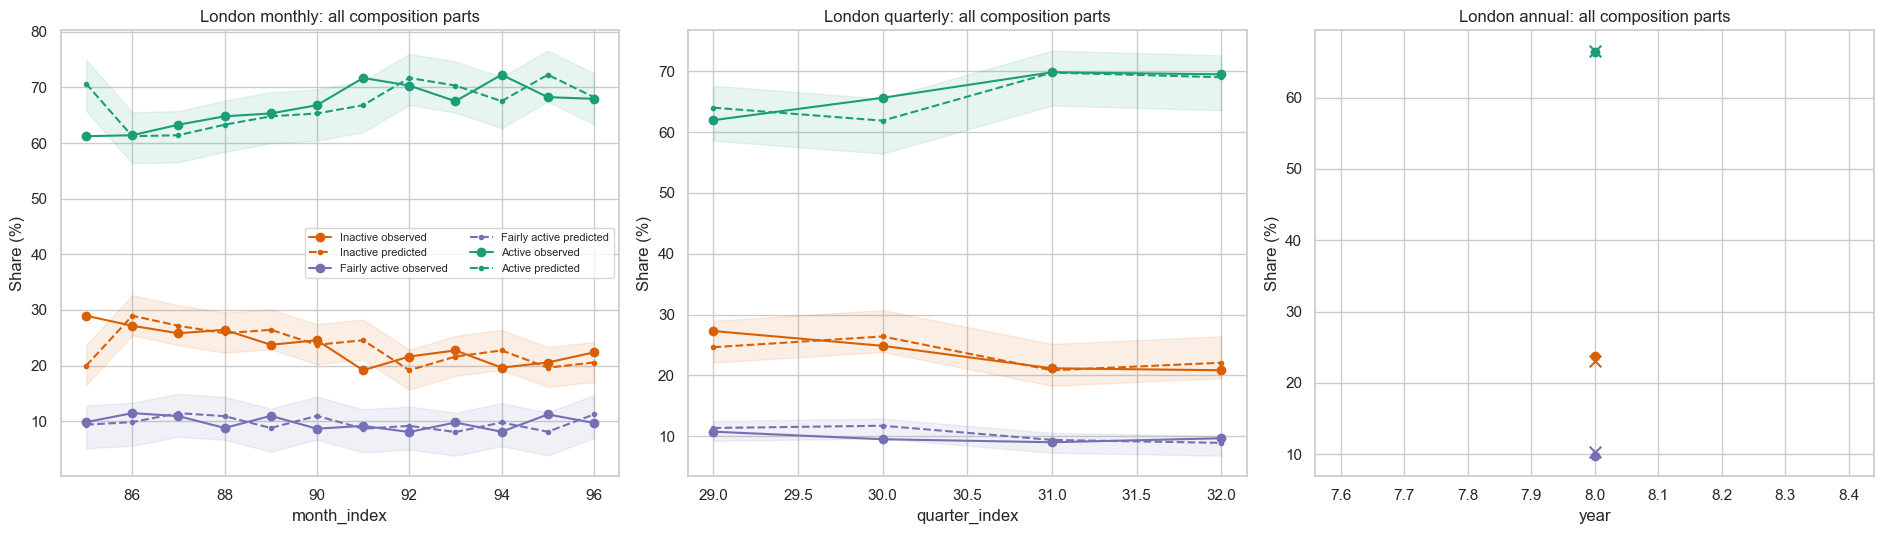

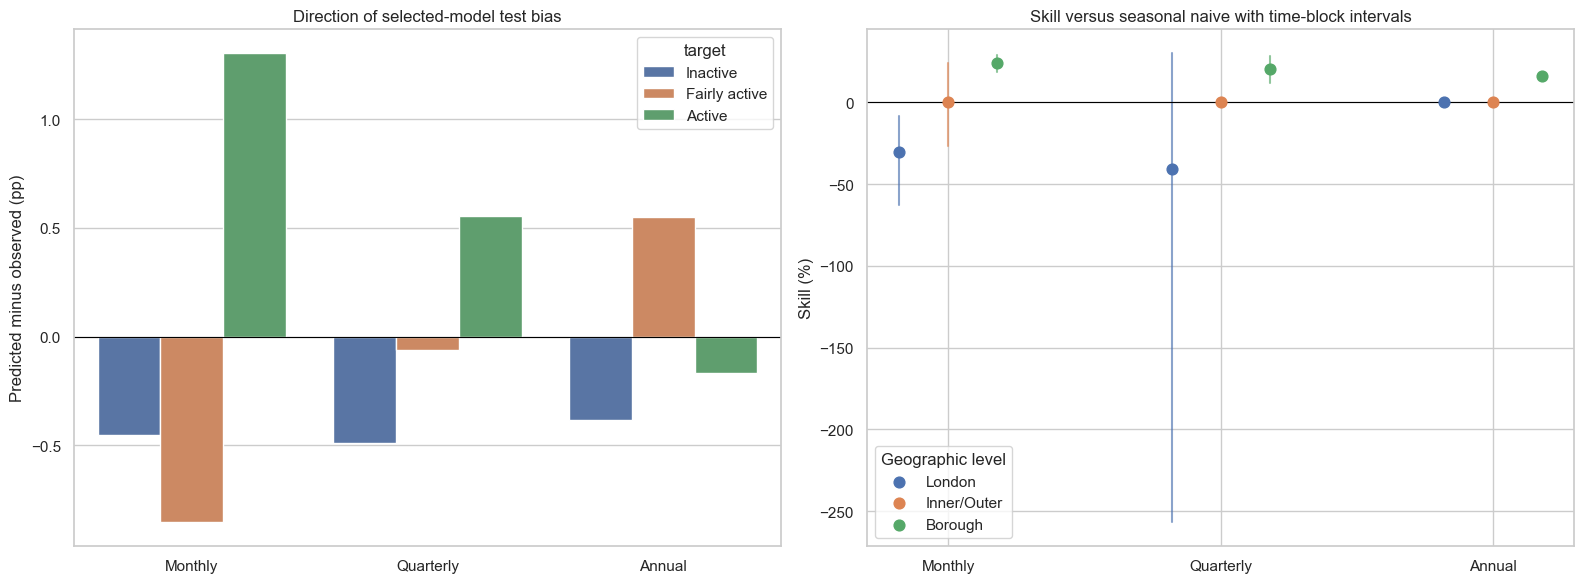

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, frequency in zip(axes, ['Monthly', 'Quarterly', 'Annual']):
    london = band_predictions.loc[
        band_predictions['geographic_level'].eq('London')
        & band_predictions['frequency'].eq(frequency)
    ].sort_values(TASK_DESIGNS[frequency]['time'])
    time_column = TASK_DESIGNS[frequency]['time']
    x = london[time_column].to_numpy()
    for target, colour in zip(TARGETS, ['#d95f02', '#7570b3', '#1b9e77']):
        observed = london[target].to_numpy() * 100
        predicted = london[f'predicted_{target}'].to_numpy() * 100
        if len(london) == 1:
            ax.scatter(x, observed, color=colour, marker='o', label=f'{TARGET_LABELS[target]} observed')
            ax.scatter(x, predicted, color=colour, marker='x', s=70,
                       label=f'{TARGET_LABELS[target]} predicted')
        else:
            ax.plot(x, observed, color=colour, marker='o', label=f'{TARGET_LABELS[target]} observed')
            ax.plot(x, predicted, color=colour, linestyle='--', marker='.',
                    label=f'{TARGET_LABELS[target]} predicted')
            low = london[f'band_low_{target}'].to_numpy(dtype=float) * 100
            high = london[f'band_high_{target}'].to_numpy(dtype=float) * 100
            if np.isfinite(low).any():
                ax.fill_between(x, low, high, color=colour, alpha=.10)
    ax.set(title=f'London {frequency.lower()}: all composition parts',
           xlabel=time_column, ylabel='Share (%)')
    if frequency == 'Monthly':
        ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
save_figure(fig, 'forecast_london_composition_with_uncertainty.png')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bias_rows = []
for _, row in selected_test_metrics.iterrows():
    for target in TARGETS:
        bias_rows.append({
            'geographic_level': row['geographic_level'], 'frequency': row['frequency'],
            'target': TARGET_LABELS[target], 'signed_bias_pp': row[f'{target}_signed_bias'] * 100,
        })
bias_table = pd.DataFrame(bias_rows)
sns.barplot(data=bias_table, x='frequency', y='signed_bias_pp', hue='target',
            errorbar=None, ax=axes[0])
axes[0].axhline(0, color='black', linewidth=.8)
axes[0].set(title='Direction of selected-model test bias', xlabel='', ylabel='Predicted minus observed (pp)')

skill_plot = test_skill.copy()
skill_plot['skill_pct'] = skill_plot['skill_vs_seasonal'] * 100
frequency_order = ['Monthly', 'Quarterly', 'Annual']
level_order = ['London', 'Inner/Outer', 'Borough']
offsets = {'London': -.18, 'Inner/Outer': 0, 'Borough': .18}
colours = {'London': '#4c72b0', 'Inner/Outer': '#dd8452', 'Borough': '#55a868'}
for level in level_order:
    local = skill_plot.loc[skill_plot['geographic_level'].eq(level)]
    for _, row in local.iterrows():
        x_position = frequency_order.index(row['frequency']) + offsets[level]
        axes[1].scatter(x_position, row['skill_pct'], color=colours[level], s=60,
                        label=level if row['frequency'] == 'Monthly' else None, zorder=3)
        if pd.notna(row['skill_ci_low']):
            axes[1].plot(
                [x_position, x_position],
                [row['skill_ci_low'] * 100, row['skill_ci_high'] * 100],
                color=colours[level], alpha=.65, linewidth=1.5,
            )
axes[1].set_xticks(range(3), frequency_order)
axes[1].axhline(0, color='black', linewidth=.8)
axes[1].set(title='Skill versus seasonal naive with time-block intervals',
            xlabel='', ylabel='Skill (%)')
axes[1].legend(title='Geographic level')
fig.tight_layout()
save_figure(fig, 'forecast_bias_and_skill_uncertainty.png')
plt.show()

### Test and uncertainty findings

The final test does not support a universal ML advantage. London monthly last-observation error is
0.0327 weighted TV and is **30.6% worse** than the seasonal naive (95% time-block interval
-62.9% to -8.3%). Inner/Outer monthly skill is only +0.5% with an interval spanning -26.4% to
+24.0%. Borough ML is more useful: monthly Random-Forest skill is +23.9% (18.8% to 28.7%) and quarterly
Ridge skill is +20.6% (11.8% to 28.5%), although the quarterly interval uses only four time blocks
and is explicitly labelled very low precision. London quarterly Gradient Boosting is 40.5% worse
than seasonal naive on test, with an extremely wide interval, illustrating the short-series risk. Annual skill has no interval because one test year cannot support one.

For borough monthly Active, weighted MAE is 8.91 points, while the approximate survey-noise floor
is 8.86 points and the noise-adjusted RMSE is 6.92 points. The decomposition therefore confirms
that low-precision survey variation is a major, but not complete, source of borough error. Joint
TV-region test coverage ranges from 91.7% to 100% for aggregate monthly/quarterly tasks and is
withheld for every annual task.

## 6. Frequency choice and forecast coherence

Monthly-to-quarter and direct-quarter predictions are compared on the two selection folds. The
one-standard-error rule prefers direct quarterly estimates when the apparent gain from monthly
aggregation is too small to distinguish from fold variation. The later audit block reports whether
that choice generalizes; the test is not used to choose frequency.

Geographic coherence is enforced by publishing bottom-up aggregates of borough predictions for
Inner/Outer London and London. Direct aggregate models remain diagnostics. Cross-frequency gaps are
reported rather than mechanically forced to zero because direct quarterly/annual survey estimates
are not guaranteed to equal simple averages of lower-frequency estimates.

In [10]:
def aggregate_months_to_quarters(frame):
    result = frame.copy()
    result['quarter_index'] = ((result['month_index'] - 1) // 3 + 1).astype(int)
    columns = [f'predicted_{target}' for target in TARGETS]
    return result.groupby(
        ['quarter_index', 'geography_code', 'geography_name'], as_index=False
    )[columns].mean()


resolution_fold_rows = []
for level in ['London', 'Inner/Outer', 'Borough']:
    monthly = task_results[(level, 'Monthly')]
    quarterly = task_results[(level, 'Quarterly')]
    month_selected = monthly['selection_predictions'].loc[
        monthly['selection_predictions']['candidate_id'].eq(monthly['selected_id'])
    ]
    quarter_selected = quarterly['selection_predictions'].loc[
        quarterly['selection_predictions']['candidate_id'].eq(quarterly['selected_id'])
    ]
    quarter_truth = panels[(level, 'Quarterly')][
        ['quarter_index', 'geography_code', *TARGETS, 'effective_n']
    ]
    for fold in [1, 2]:
        monthly_fold = aggregate_months_to_quarters(month_selected.loc[month_selected['fold'].eq(fold)])
        monthly_fold = monthly_fold.merge(
            quarter_truth, on=['quarter_index', 'geography_code'], validate='one_to_one'
        )
        quarterly_fold = quarter_selected.loc[quarter_selected['fold'].eq(fold)]
        for approach, frame in [
            ('Monthly model averaged to quarter', monthly_fold),
            ('Direct quarterly model', quarterly_fold),
        ]:
            resolution_fold_rows.append({
                'geographic_level': level, 'fold': fold, 'approach': approach,
                **score_predictions(
                    frame[TARGETS], frame[[f'predicted_{t}' for t in TARGETS]],
                    frame['effective_n'], frame['quarter_index'],
                ),
            })
resolution_fold_metrics = pd.DataFrame(resolution_fold_rows)

resolution_summary = resolution_fold_metrics.groupby(
    ['geographic_level', 'approach'], as_index=False
).agg(
    mean_weighted_tv=('weighted_total_variation', 'mean'),
    sd_weighted_tv=('weighted_total_variation', 'std'),
    folds=('fold', 'nunique'),
)
resolution_summary['se_weighted_tv'] = resolution_summary['sd_weighted_tv'] / np.sqrt(
    resolution_summary['folds']
)
resolution_choices = []
for level, group in resolution_summary.groupby('geographic_level'):
    best = group.sort_values('mean_weighted_tv').iloc[0]
    threshold = best['mean_weighted_tv'] + best['se_weighted_tv']
    eligible = group.loc[group['mean_weighted_tv'].le(threshold + 1e-12)]
    preferred = (
        'Direct quarterly model'
        if eligible['approach'].eq('Direct quarterly model').any()
        else best['approach']
    )
    resolution_choices.append({
        'geographic_level': level, 'selected_resolution': preferred,
        'one_se_threshold': threshold,
        'selection_fold_mean_tv': group.set_index('approach').at[preferred, 'mean_weighted_tv'],
    })
resolution_selection = pd.DataFrame(resolution_choices)

audit_resolution_rows = []
for level in ['London', 'Inner/Outer', 'Borough']:
    monthly = selected_audit_predictions.loc[
        selected_audit_predictions['geographic_level'].eq(level)
        & selected_audit_predictions['frequency'].eq('Monthly')
    ]
    quarterly = selected_audit_predictions.loc[
        selected_audit_predictions['geographic_level'].eq(level)
        & selected_audit_predictions['frequency'].eq('Quarterly')
    ]
    monthly_quarter = aggregate_months_to_quarters(monthly).merge(
        panels[(level, 'Quarterly')][
            ['quarter_index', 'geography_code', *TARGETS, 'effective_n']
        ], on=['quarter_index', 'geography_code'], validate='one_to_one'
    )
    for approach, frame in [
        ('Monthly model averaged to quarter', monthly_quarter),
        ('Direct quarterly model', quarterly),
    ]:
        audit_resolution_rows.append({
            'geographic_level': level, 'approach': approach,
            **score_predictions(
                frame[TARGETS], frame[[f'predicted_{t}' for t in TARGETS]],
                frame['effective_n'], frame['quarter_index'],
            ),
        })
resolution_audit = pd.DataFrame(audit_resolution_rows)


def bottom_up_predictions(frequency):
    time_column = TASK_DESIGNS[frequency]['time']
    borough = selected_test_predictions.loc[
        selected_test_predictions['geographic_level'].eq('Borough')
        & selected_test_predictions['frequency'].eq(frequency)
    ].copy()
    population = panels[('Borough', frequency)][
        [time_column, 'geography_code', 'inner_outer', 'adult_population']
    ]
    borough = borough.drop(columns=[c for c in ['inner_outer', 'adult_population'] if c in borough]).merge(
        population, on=[time_column, 'geography_code'], validate='one_to_one'
    )
    rows = []
    for area, group in borough.groupby([time_column, 'inner_outer']):
        period, area_name = area
        weights = group['adult_population'].to_numpy()
        row = {time_column: period, 'geography_name': area_name, 'geographic_level': 'Inner/Outer'}
        for target in TARGETS:
            row[f'predicted_{target}'] = weighted_mean(group[f'predicted_{target}'], weights)
        rows.append(row)
    for period, group in borough.groupby(time_column):
        weights = group['adult_population'].to_numpy()
        row = {time_column: period, 'geography_name': 'London excluding City of London',
               'geographic_level': 'London'}
        for target in TARGETS:
            row[f'predicted_{target}'] = weighted_mean(group[f'predicted_{target}'], weights)
        rows.append(row)
    aggregate = pd.DataFrame(rows)
    borough_output = borough.assign(geographic_level='Borough')
    return borough_output, aggregate


reconciled_parts, hierarchy_rows = [], []
for frequency in ['Monthly', 'Quarterly', 'Annual']:
    time_column = TASK_DESIGNS[frequency]['time']
    borough, aggregate = bottom_up_predictions(frequency)
    reconciled_parts.append(borough)
    for level in ['Inner/Outer', 'London']:
        direct = selected_test_predictions.loc[
            selected_test_predictions['geographic_level'].eq(level)
            & selected_test_predictions['frequency'].eq(frequency)
        ]
        keys = [time_column, 'geography_name']
        comparison = aggregate.loc[aggregate['geographic_level'].eq(level)].merge(
            direct[keys + [f'predicted_{t}' for t in TARGETS]],
            on=keys, suffixes=('_bottom_up', '_direct'), validate='one_to_one'
        )
        for _, row in comparison.iterrows():
            for target in TARGETS:
                hierarchy_rows.append({
                    'frequency': frequency, 'geographic_level': level,
                    time_column: row[time_column], 'geography_name': row['geography_name'],
                    'target': target,
                    'direct_minus_bottom_up_pp': 100 * (
                        row[f'predicted_{target}_direct'] - row[f'predicted_{target}_bottom_up']
                    ),
                })
        truth = panels[(level, frequency)][
            [time_column, 'geography_name', *TARGETS, 'effective_n']
        ]
        reconciled_parts.append(
            aggregate.loc[aggregate['geographic_level'].eq(level)].merge(
                truth, on=[time_column, 'geography_name'], validate='one_to_one'
            ).assign(frequency=frequency)
        )
    reconciled_parts[-3] = reconciled_parts[-3].assign(frequency=frequency)

hierarchy_reconciliation = pd.DataFrame(hierarchy_rows)
reconciled_predictions = pd.concat(reconciled_parts, ignore_index=True, sort=False)

frequency_alignment_rows = []
monthly_rec = reconciled_predictions.loc[reconciled_predictions['frequency'].eq('Monthly')].copy()
monthly_rec['quarter_index'] = ((monthly_rec['month_index'] - 1) // 3 + 1).astype(int)
monthly_quarter = monthly_rec.groupby(
    ['geographic_level', 'geography_name', 'quarter_index'], as_index=False
)[[f'predicted_{t}' for t in TARGETS]].mean()
quarter_rec = reconciled_predictions.loc[reconciled_predictions['frequency'].eq('Quarterly')]
alignment = monthly_quarter.merge(
    quarter_rec[['geographic_level', 'geography_name', 'quarter_index',
                 *[f'predicted_{t}' for t in TARGETS]]],
    on=['geographic_level', 'geography_name', 'quarter_index'],
    suffixes=('_monthly_average', '_direct_quarter'), validate='one_to_one'
)
for _, row in alignment.iterrows():
    for target in TARGETS:
        frequency_alignment_rows.append({
            'comparison': 'Monthly average versus direct quarter',
            'geographic_level': row['geographic_level'],
            'geography_name': row['geography_name'],
            'period': row['quarter_index'], 'target': target,
            'gap_pp': 100 * (row[f'predicted_{target}_monthly_average']
                              - row[f'predicted_{target}_direct_quarter']),
        })
frequency_alignment = pd.DataFrame(frequency_alignment_rows)

display(resolution_summary)
display(resolution_selection)
display(resolution_audit)
display(hierarchy_reconciliation.groupby(['frequency', 'geographic_level'])['direct_minus_bottom_up_pp'].agg(['mean', 'max']))

,geographic_level,approach,mean_weighted_tv,sd_weighted_tv,folds,se_weighted_tv
0,Borough,Direct quarterly model,0.068177,0.000217,2,0.000153
1,Borough,Monthly model averaged to quarter,0.073616,0.005870,2,0.004151
2,Inner/Outer,Direct quarterly model,0.036305,0.008098,2,0.005726
3,Inner/Outer,Monthly model averaged to quarter,0.020790,0.002991,2,0.002115
4,London,Direct quarterly model,0.027994,0.001914,2,0.001353
5,London,Monthly model averaged to quarter,0.019283,0.002027,2,0.001433


,geographic_level,selected_resolution,one_se_threshold,selection_fold_mean_tv
0,Borough,Direct quarterly model,0.068330,0.068177
1,Inner/Outer,Monthly model averaged to quarter,0.022905,0.020790
2,London,Monthly model averaged to quarter,0.020716,0.019283


,geographic_level,approach,observations,time_periods,weighted_total_variation,unweighted_total_variation,inactive_rate_weighted_mae,inactive_rate_weighted_rmse,inactive_rate_signed_bias,inactive_rate_survey_noise_floor_rmse,inactive_rate_noise_adjusted_rmse,inactive_rate_weighted_r2,fairly_active_rate_weighted_mae,fairly_active_rate_weighted_rmse,fairly_active_rate_signed_bias,fairly_active_rate_survey_noise_floor_rmse,fairly_active_rate_noise_adjusted_rmse,fairly_active_rate_weighted_r2,active_rate_weighted_mae,active_rate_weighted_rmse,active_rate_signed_bias,active_rate_survey_noise_floor_rmse,active_rate_noise_adjusted_rmse,active_rate_weighted_r2
0,London,Monthly model averaged to quarter,4,4,0.008637,0.008602,0.004614,0.006714,0.003737,0.009010,0.000000,NaN,0.006692,0.008011,-0.000556,0.006460,0.004738,NaN,0.005967,0.006766,-0.003182,0.010069,0.000000,NaN
1,London,Direct quarterly model,4,4,0.025670,0.025805,0.018692,0.019240,0.018692,0.009010,0.017001,NaN,0.010196,0.011624,0.003761,0.006460,0.009664,NaN,0.022453,0.023465,-0.022453,0.010069,0.021194,NaN
2,Inner/Outer,Monthly model averaged to quarter,8,4,0.012286,0.012309,0.007109,0.009142,0.003695,0.012636,0.000000,NaN,0.011331,0.012175,-0.000309,0.009125,0.008060,NaN,0.006132,0.008876,-0.003386,0.014171,0.000000,NaN
3,Inner/Outer,Direct quarterly model,8,4,0.026750,0.027666,0.018106,0.021704,0.012270,0.012636,0.017646,NaN,0.010698,0.014330,0.003645,0.009125,0.011049,NaN,0.024697,0.028490,-0.015915,0.014171,0.024716,NaN
4,Borough,Monthly model averaged to quarter,128,4,0.066454,0.066873,0.043704,0.053372,-0.010260,0.048531,0.022209,NaN,0.036390,0.045040,-0.026502,0.034791,0.028604,NaN,0.052814,0.066896,0.036763,0.054250,0.039140,NaN
5,Borough,Direct quarterly model,128,4,0.061893,0.062988,0.045376,0.055575,0.004432,0.048531,0.027079,NaN,0.029907,0.036756,-0.010869,0.034791,0.011857,NaN,0.048502,0.059462,0.006437,0.054250,0.024344,NaN


mean       max
frequency geographic_level                        
Annual    Inner/Outer       9.251859e-16  1.159762
          London            5.551115e-15  0.993882
Monthly   Inner/Outer      -9.868649e-17  6.445468
          London            3.330669e-16  6.430672
Quarterly Inner/Outer      -3.885781e-16  2.935965
          London           -1.628327e-15  2.537622

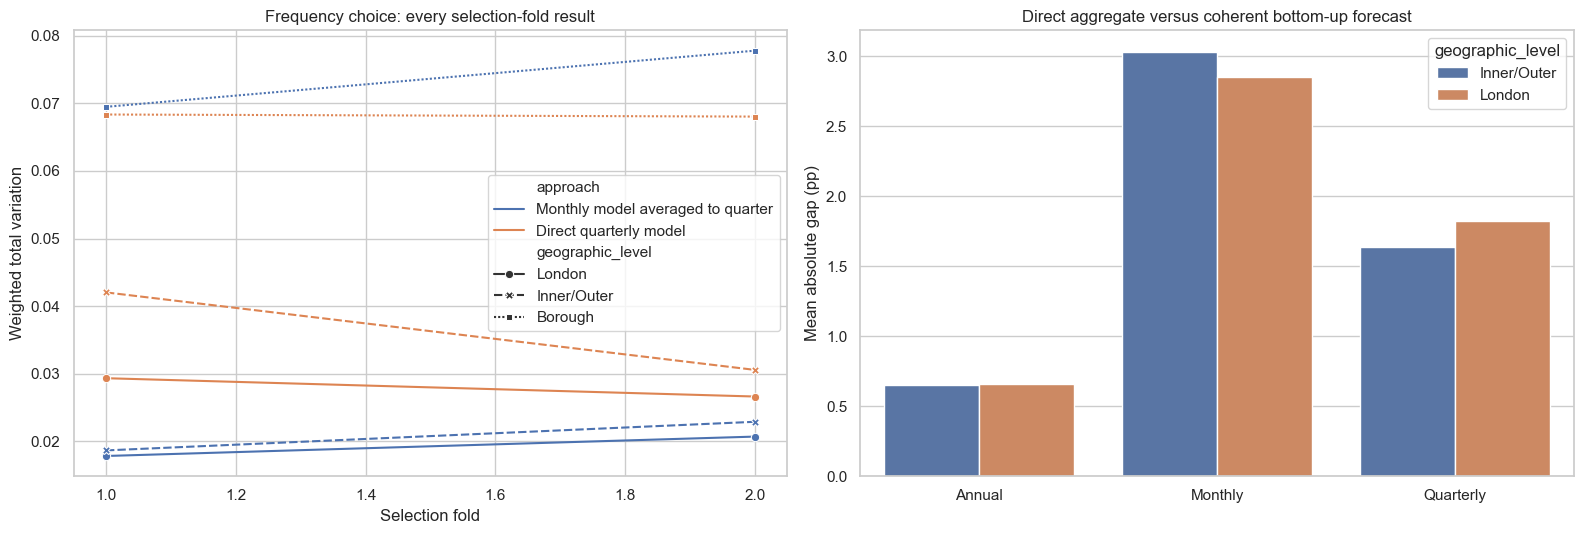

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
sns.lineplot(
    data=resolution_fold_metrics, x='fold', y='weighted_total_variation',
    hue='approach', style='geographic_level', markers=True, dashes=True,
    estimator=None, ax=axes[0],
)
axes[0].set(title='Frequency choice: every selection-fold result',
            xlabel='Selection fold', ylabel='Weighted total variation')

gap_summary = hierarchy_reconciliation.groupby(
    ['frequency', 'geographic_level'], as_index=False
)['direct_minus_bottom_up_pp'].apply(lambda x: np.mean(np.abs(x))).rename(
    columns={'direct_minus_bottom_up_pp': 'mean_absolute_gap_pp'}
)
sns.barplot(data=gap_summary, x='frequency', y='mean_absolute_gap_pp',
            hue='geographic_level', errorbar=None, ax=axes[1])
axes[1].set(title='Direct aggregate versus coherent bottom-up forecast',
            xlabel='', ylabel='Mean absolute gap (pp)')
fig.tight_layout()
save_figure(fig, 'forecast_frequency_and_hierarchy_coherence.png')
plt.show()

### Frequency and coherence findings

Fold-level selection prefers monthly-to-quarter for London and Inner/Outer, and direct quarterly
for boroughs. The independent development audit supports those choices: monthly aggregation has
weighted TV 0.0086 versus 0.0192 for direct London quarters, 0.0123 versus 0.0268 for Inner/Outer,
while direct borough quarterly improves on monthly aggregation (0.0619 versus 0.0665).

Direct aggregate predictions differ materially from coherent bottom-up borough forecasts: the mean absolute gap is about 2.8-3.0 percentage points at monthly frequency, 1.6-1.8 points
quarterly and 0.7 points annually. The workbook therefore makes bottom-up aggregates the canonical coherent
forecast and retains direct aggregates as diagnostics. Averaged monthly Active forecasts are about 1.7 points above direct quarterly forecasts, confirming that the two survey estimands should not
be silently treated as identical.

## 7. Error profiles, temporal dependence and spatial dependence

Diagnostics identify persistent borough errors, effective-sample-size gradients, signed temporal
autocorrelation and spatial clustering of borough residuals. Borough scatterplots use category
colour rather than 32 meaningless hidden colours. These checks distinguish model failure from the
high survey-noise floor of low-`effective_n` borough cells.

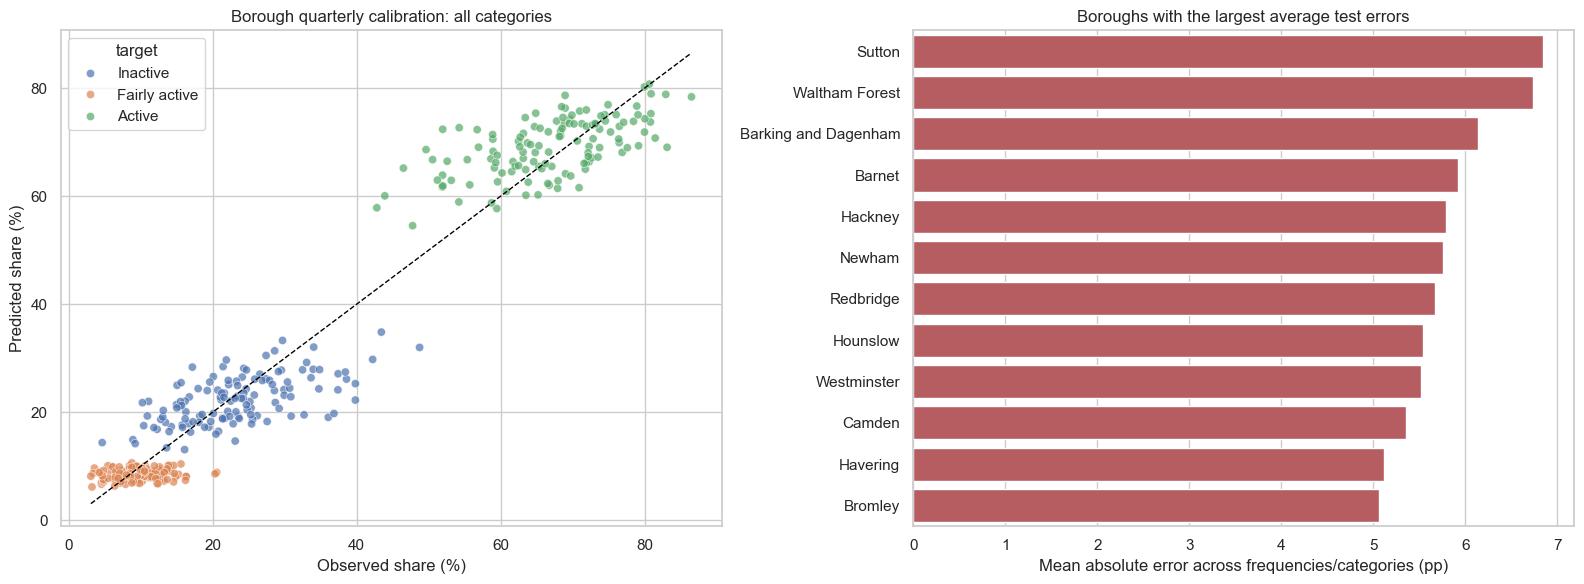

,precision_tier,target,observations,mean_absolute_error_pp,median_effective_n,geographic_level,frequency
0,Low effective n,active_rate,10,2.682358,300.666351,Borough,Annual
1,Low effective n,fairly_active_rate,11,1.716555,300.736397,Borough,Annual
2,Low effective n,inactive_rate,11,2.795065,300.736397,Borough,Annual
3,Middle effective n,active_rate,11,3.696753,315.367087,Borough,Annual
4,Middle effective n,fairly_active_rate,10,1.361604,315.552620,Borough,Annual
...,...,...,...,...,...,...,...
67,Middle effective n,fairly_active_rate,2,1.301852,2218.883023,London,Quarterly
68,Middle effective n,inactive_rate,1,1.545173,2228.777199,London,Quarterly
69,High effective n,active_rate,2,2.123567,2283.645837,London,Quarterly
70,High effective n,fairly_active_rate,1,0.755002,2338.514476,London,Quarterly


,geographic_level,frequency,target,diagnostic_lag,lag_periods,residual_autocorrelation,test_time_periods
0,Borough,Annual,inactive_rate,lag1,1,NaN,1
1,Borough,Annual,inactive_rate,seasonal,1,NaN,1
2,Borough,Annual,fairly_active_rate,lag1,1,NaN,1
3,Borough,Annual,fairly_active_rate,seasonal,1,NaN,1
4,Borough,Annual,active_rate,lag1,1,NaN,1
5,Borough,Annual,active_rate,seasonal,1,NaN,1
6,Borough,Monthly,inactive_rate,lag1,1,0.539869,12
7,Borough,Monthly,inactive_rate,seasonal,12,NaN,12
8,Borough,Monthly,fairly_active_rate,lag1,1,-0.016271,12
9,Borough,Monthly,fairly_active_rate,seasonal,12,NaN,12


,frequency,morans_i,random_expectation,permutation_p_value,permutation_repeats
0,Monthly,0.271318,-0.032258,0.007,999
1,Quarterly,0.131309,-0.032258,0.120,999
2,Annual,0.043637,-0.032258,0.468,999


In [12]:
error_rows = []
for _, row in selected_test_predictions.iterrows():
    for target in TARGETS:
        error_rows.append({
            'geographic_level': row['geographic_level'], 'frequency': row['frequency'],
            'geography_code': row['geography_code'], 'geography_name': row['geography_name'],
            'effective_n': row['effective_n'], 'target': target,
            'absolute_error_pp': abs(row[f'error_{target}']) * 100,
            'signed_error_pp': row[f'error_{target}'] * 100,
        })
error_long = pd.DataFrame(error_rows)

borough_error_profile = error_long.loc[error_long['geographic_level'].eq('Borough')].groupby(
    ['frequency', 'geography_code', 'geography_name'], as_index=False
).agg(
    mean_absolute_error_pp=('absolute_error_pp', 'mean'),
    mean_signed_error_pp=('signed_error_pp', 'mean'),
    median_effective_n=('effective_n', 'median'),
)

effective_n_error_parts = []
for (level, frequency), group in error_long.groupby(['geographic_level', 'frequency']):
    local = group.copy()
    local['precision_tier'] = pd.qcut(
        local['effective_n'].rank(method='first'), 3,
        labels=['Low effective n', 'Middle effective n', 'High effective n']
    )
    effective_n_error_parts.append(local.groupby(['precision_tier', 'target'], observed=True, as_index=False).agg(
        observations=('absolute_error_pp', 'size'),
        mean_absolute_error_pp=('absolute_error_pp', 'mean'),
        median_effective_n=('effective_n', 'median'),
    ).assign(geographic_level=level, frequency=frequency))
effective_n_error = pd.concat(effective_n_error_parts, ignore_index=True)

temporal_rows = []
for (level, frequency), group in selected_test_predictions.groupby(['geographic_level', 'frequency']):
    time_column = TASK_DESIGNS[frequency]['time']
    for target in TARGETS:
        series = group.groupby(time_column).apply(
            lambda x: weighted_mean(x[f'error_{target}'], x['effective_n']),
            include_groups=False,
        ).sort_index()
        for lag_name, lag in [('lag1', 1), ('seasonal', TASK_DESIGNS[frequency]['seasonal_lag'])]:
            correlation = series.corr(series.shift(lag)) if len(series) > lag + 2 else np.nan
            temporal_rows.append({
                'geographic_level': level, 'frequency': frequency, 'target': target,
                'diagnostic_lag': lag_name, 'lag_periods': lag,
                'residual_autocorrelation': correlation,
                'test_time_periods': len(series),
            })
temporal_residual_diagnostics = pd.DataFrame(temporal_rows)


def moran_permutation(values, weights, repeats=999):
    values = np.asarray(values, dtype=float)
    centred = values - values.mean()
    observed = len(values) / weights.sum() * (centred @ weights @ centred) / (centred @ centred)
    expected = -1 / (len(values) - 1)
    rng = np.random.default_rng(RANDOM_STATE + len(values))
    simulated = []
    for _ in range(repeats):
        shuffled = rng.permutation(centred)
        simulated.append(len(values) / weights.sum() * (shuffled @ weights @ shuffled) /
                         (shuffled @ shuffled))
    simulated = np.asarray(simulated)
    p_value = (1 + np.sum(np.abs(simulated - expected) >= abs(observed - expected))) / (repeats + 1)
    return observed, expected, p_value


boundaries = gpd.read_file(BOUNDARY_PATH)[['gss_code', 'geometry']]
borough_codes = panels[('Borough', 'Annual')]['geography_code'].unique()
boundaries = boundaries.loc[boundaries['gss_code'].isin(borough_codes)].reset_index(drop=True)
assert len(boundaries) == 32
spatial_weights = np.zeros((32, 32))
for i in range(32):
    for j in range(i + 1, 32):
        if boundaries.geometry.iloc[i].touches(boundaries.geometry.iloc[j]):
            spatial_weights[i, j] = spatial_weights[j, i] = 1

spatial_rows = []
for frequency in ['Monthly', 'Quarterly', 'Annual']:
    borough = selected_test_predictions.loc[
        selected_test_predictions['geographic_level'].eq('Borough')
        & selected_test_predictions['frequency'].eq(frequency)
    ].groupby('geography_code', as_index=False).apply(
        lambda x: pd.Series({'mean_active_error': weighted_mean(x['error_active_rate'], x['effective_n'])}),
        include_groups=False,
    ).reset_index(drop=True)
    mapped = boundaries.merge(borough, left_on='gss_code', right_on='geography_code', validate='one_to_one')
    statistic, expectation, p_value = moran_permutation(mapped['mean_active_error'], spatial_weights)
    spatial_rows.append({
        'frequency': frequency, 'morans_i': statistic,
        'random_expectation': expectation, 'permutation_p_value': p_value,
        'permutation_repeats': 999,
    })
spatial_residual_diagnostics = pd.DataFrame(spatial_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
borough_quarter = selected_test_predictions.loc[
    selected_test_predictions['geographic_level'].eq('Borough')
    & selected_test_predictions['frequency'].eq('Quarterly')
]
scatter_parts = []
for target in TARGETS:
    scatter_parts.append(pd.DataFrame({
        'observed_pct': borough_quarter[target] * 100,
        'predicted_pct': borough_quarter[f'predicted_{target}'] * 100,
        'target': TARGET_LABELS[target],
    }))
scatter = pd.concat(scatter_parts, ignore_index=True)
sns.scatterplot(data=scatter, x='observed_pct', y='predicted_pct', hue='target', alpha=.7, ax=axes[0])
limits = [scatter[['observed_pct', 'predicted_pct']].min().min(),
          scatter[['observed_pct', 'predicted_pct']].max().max()]
axes[0].plot(limits, limits, '--', color='black', linewidth=1)
axes[0].set(title='Borough quarterly calibration: all categories',
            xlabel='Observed share (%)', ylabel='Predicted share (%)')

worst = borough_error_profile.groupby('geography_name', as_index=False)['mean_absolute_error_pp'].mean().nlargest(12, 'mean_absolute_error_pp')
sns.barplot(data=worst, x='mean_absolute_error_pp', y='geography_name',
            color='#c44e52', errorbar=None, ax=axes[1])
axes[1].set(title='Boroughs with the largest average test errors',
            xlabel='Mean absolute error across frequencies/categories (pp)', ylabel='')
fig.tight_layout()
save_figure(fig, 'forecast_borough_error_profile.png')
plt.show()

display(effective_n_error)
display(temporal_residual_diagnostics)
display(spatial_residual_diagnostics)

### Residual findings

Low-`effective_n` borough-month observations have average category error about 7.91 points versus
6.90 points in the high-precision tier; small samples matter, but do not fully explain performance.
The selected borough-month Random Forest leaves significant positive Active-residual spatial
autocorrelation (Moran's I = 0.271, permutation p = 0.007). Quarterly Ridge and annual baseline
residual Moran tests are not significant. Quarterly temporal autocorrelations still rely on only
four periods and remain fragile.


## 8. Monthly residual-correction sensitivity

This section tests whether previously observed out-of-sample errors contain usable short-run information. It is restricted to monthly tasks, which have enough independent periods for a one-step feedback check. Quarterly and annual tasks are deliberately excluded.

Two corrections are compared with the unchanged selected forecast: a pooled signed-bias calibration and a pooled AR(1) residual model with target-specific coefficients capped at +/-0.5. Parameters for the audit are fitted only on selection-fold out-of-fold residuals. The better correction is chosen on the audit block, refitted on selection plus audit residuals, frozen, and then evaluated once on the test block. Base forecasts, official model selection and published uncertainty bands are not replaced.


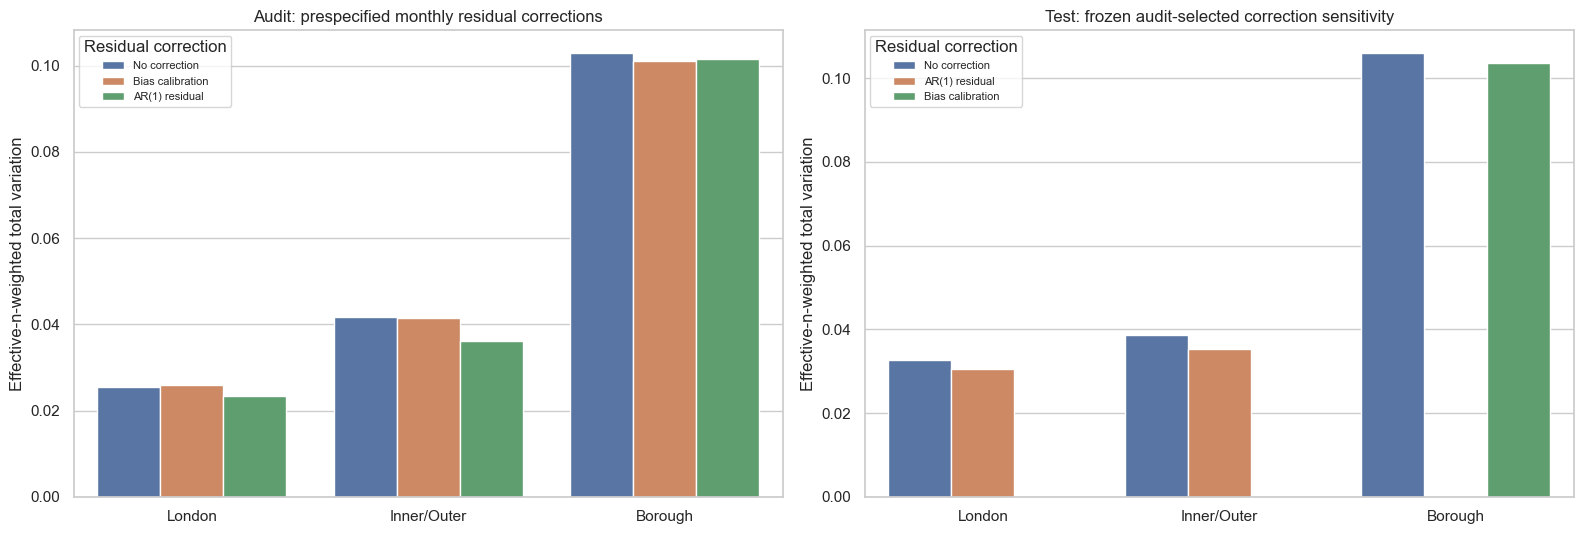

,geographic_level,frequency,selected_correction,base_audit_weighted_tv,corrected_audit_weighted_tv,absolute_audit_improvement,relative_audit_improvement,months_improved,audit_months,improvement_p10,improvement_p90,audit_supported,role
0,London,Monthly,AR(1) residual,0.0255,0.0233,0.0022,0.0856,7,12,-0.0009,0.0050,True,Sensitivity only; primary selected forecast is...
1,Inner/Outer,Monthly,AR(1) residual,0.0416,0.0362,0.0054,0.1292,10,12,0.0028,0.0075,True,Sensitivity only; primary selected forecast is...
2,Borough,Monthly,Bias calibration,0.1030,0.1012,0.0018,0.0178,7,12,-0.0006,0.0042,True,Sensitivity only; primary selected forecast is...


,geographic_level,correction_method,weighted_total_variation,active_rate_signed_bias,fairly_active_rate_signed_bias,inactive_rate_signed_bias
0,London,No correction,0.0327,-0.0010,-0.0004,0.0014
1,London,AR(1) residual,0.0306,0.0045,-0.0033,-0.0012
2,Inner/Outer,No correction,0.0387,-0.0007,-0.0002,0.0009
3,Inner/Outer,AR(1) residual,0.0353,0.0048,-0.0035,-0.0012
4,Borough,No correction,0.1061,0.0409,-0.0250,-0.0158
5,Borough,Bias calibration,0.1036,-0.0031,-0.0008,0.0040


In [13]:
def fit_residual_correction(history, time_column, fit_for):
    parameter_rows = []
    ordered = history.sort_values(['geography_code', time_column]).copy()
    for target in TARGETS:
        residual_column = f'residual_{target}'
        ordered[residual_column] = ordered[target] - ordered[f'predicted_{target}']
        bias = weighted_mean(ordered[residual_column], ordered['effective_n'])
        parameter_rows.append({
            'fit_for': fit_for, 'method': 'Bias calibration', 'target': target,
            'intercept': bias, 'phi': 0.0, 'residual_pairs': 0,
            'history_periods': ordered[time_column].nunique(),
        })

        pairs = ordered[[
            'geography_code', time_column, 'effective_n', residual_column
        ]].copy()
        pairs['previous_residual'] = pairs.groupby('geography_code')[residual_column].shift(1)
        pairs['previous_time'] = pairs.groupby('geography_code')[time_column].shift(1)
        pairs = pairs.loc[
            pairs['previous_residual'].notna()
            & pairs[time_column].sub(pairs['previous_time']).eq(1)
        ]
        if len(pairs) < 8 or pairs['previous_residual'].var(ddof=0) <= 1e-12:
            intercept, phi = bias, 0.0
        else:
            x = pairs['previous_residual'].to_numpy(dtype=float)
            y = pairs[residual_column].to_numpy(dtype=float)
            weights = pairs['effective_n'].clip(lower=1).to_numpy(dtype=float)
            design = np.column_stack([np.ones(len(x)), x])
            root_weights = np.sqrt(weights / weights.mean())
            coefficients = np.linalg.lstsq(
                design * root_weights[:, None], y * root_weights, rcond=None
            )[0]
            phi = float(np.clip(coefficients[1], -.5, .5))
            intercept = weighted_mean(y - phi * x, weights)
        parameter_rows.append({
            'fit_for': fit_for, 'method': 'AR(1) residual', 'target': target,
            'intercept': intercept, 'phi': phi, 'residual_pairs': len(pairs),
            'history_periods': ordered[time_column].nunique(),
        })
    return pd.DataFrame(parameter_rows)


def apply_residual_correction(evaluation, history, parameters, method, time_column):
    result = evaluation.sort_values([time_column, 'geography_code']).copy()
    history = history.sort_values(['geography_code', time_column]).copy()
    latest_residual = {}
    for target in TARGETS:
        last = history.groupby('geography_code', as_index=False).tail(1)
        latest_residual[target] = dict(zip(
            last['geography_code'], last[target] - last[f'predicted_{target}']
        ))
    parameter_lookup = parameters.loc[parameters['method'].eq(method)].set_index('target')
    corrected_parts = []
    for _, period_rows in result.groupby(time_column, sort=True):
        base = period_rows[[f'predicted_{target}' for target in TARGETS]].to_numpy(dtype=float)
        corrections = np.zeros_like(base)
        for target_index, target in enumerate(TARGETS):
            intercept = parameter_lookup.loc[target, 'intercept']
            phi = parameter_lookup.loc[target, 'phi']
            previous = period_rows['geography_code'].map(latest_residual[target]).fillna(0).to_numpy()
            corrections[:, target_index] = intercept + phi * previous
        corrected = close_composition(base + corrections)
        output = period_rows.copy()
        for target_index, target in enumerate(TARGETS):
            output[f'predicted_{target}'] = corrected[:, target_index]
            output[f'error_{target}'] = corrected[:, target_index] - output[target]
        output['row_total_variation'] = .5 * sum(
            output[f'error_{target}'].abs() for target in TARGETS
        )
        output['correction_method'] = method
        corrected_parts.append(output)

        # The next one-step correction may use this period only after its truth is observed.
        for _, row in period_rows.iterrows():
            for target in TARGETS:
                latest_residual[target][row['geography_code']] = (
                    row[target] - row[f'predicted_{target}']
                )
    return pd.concat(corrected_parts, ignore_index=True)


def residual_sensitivity_metrics(frame, level, phase, time_column, method):
    metrics = score_predictions(
        frame[TARGETS], frame[[f'predicted_{target}' for target in TARGETS]].to_numpy(),
        frame['effective_n'], frame[time_column],
    )
    return {
        'geographic_level': level, 'frequency': 'Monthly', 'phase': phase,
        'correction_method': method, **metrics,
    }


def paired_block_improvement_interval(base, corrected, time_column, repeats=1000):
    keys = [time_column, 'geography_code']
    paired = base[keys + ['effective_n', 'row_total_variation']].merge(
        corrected[keys + ['row_total_variation']].rename(
            columns={'row_total_variation': 'corrected_row_tv'}
        ), on=keys, validate='one_to_one'
    )
    periods = np.sort(paired[time_column].unique())
    rng = np.random.default_rng(RANDOM_STATE + len(paired) + len(periods))
    improvements = []
    for _ in range(repeats):
        sampled = rng.choice(periods, size=len(periods), replace=True)
        boot = pd.concat(
            [paired.loc[paired[time_column].eq(period)] for period in sampled],
            ignore_index=True,
        )
        base_tv = weighted_mean(boot['row_total_variation'], boot['effective_n'])
        corrected_tv = weighted_mean(boot['corrected_row_tv'], boot['effective_n'])
        improvements.append(base_tv - corrected_tv)
    return np.quantile(improvements, [.10, .90])


residual_parameter_parts = []
residual_audit_metric_rows, residual_audit_predictions_parts = [], []
residual_selection_rows = []
residual_test_metric_rows, residual_test_predictions_parts = [], []

for level in ['London', 'Inner/Outer', 'Borough']:
    result = task_results[(level, 'Monthly')]
    selected_id = result['selected_id']
    selection_history = result['selection_predictions'].loc[
        result['selection_predictions']['candidate_id'].eq(selected_id)
    ].copy()
    audit_base = selected_audit_predictions.loc[
        selected_audit_predictions['geographic_level'].eq(level)
        & selected_audit_predictions['frequency'].eq('Monthly')
    ].copy()
    test_base = selected_test_predictions.loc[
        selected_test_predictions['geographic_level'].eq(level)
        & selected_test_predictions['frequency'].eq('Monthly')
    ].copy()

    audit_parameters = fit_residual_correction(selection_history, 'month_index', 'Audit')
    audit_parameters.insert(0, 'geographic_level', level)
    residual_parameter_parts.append(audit_parameters)
    audit_candidates = {'No correction': audit_base.assign(correction_method='No correction')}
    for method in ['Bias calibration', 'AR(1) residual']:
        audit_candidates[method] = apply_residual_correction(
            audit_base, selection_history, audit_parameters, method, 'month_index'
        )
    for method, predictions in audit_candidates.items():
        residual_audit_metric_rows.append(
            residual_sensitivity_metrics(predictions, level, 'Audit', 'month_index', method)
        )
        residual_audit_predictions_parts.append(predictions.assign(
            geographic_level=level, frequency='Monthly', sensitivity_phase='Audit'
        ))

    local_metrics = pd.DataFrame(residual_audit_metric_rows)
    local_metrics = local_metrics.loc[local_metrics['geographic_level'].eq(level)]
    base_tv = local_metrics.loc[
        local_metrics['correction_method'].eq('No correction'), 'weighted_total_variation'
    ].iloc[0]
    corrected_metrics = local_metrics.loc[
        local_metrics['correction_method'].ne('No correction')
    ].sort_values(['weighted_total_variation', 'correction_method'])
    selected_method = corrected_metrics.iloc[0]['correction_method']
    selected_audit = audit_candidates[selected_method]
    selected_tv = corrected_metrics.iloc[0]['weighted_total_variation']
    block_base = audit_base.groupby('month_index').apply(
        lambda x: weighted_mean(x['row_total_variation'], x['effective_n']), include_groups=False
    )
    block_corrected = selected_audit.groupby('month_index').apply(
        lambda x: weighted_mean(x['row_total_variation'], x['effective_n']), include_groups=False
    )
    ci_low, ci_high = paired_block_improvement_interval(
        audit_base, selected_audit, 'month_index'
    )
    residual_selection_rows.append({
        'geographic_level': level, 'frequency': 'Monthly',
        'selected_correction': selected_method,
        'base_audit_weighted_tv': base_tv,
        'corrected_audit_weighted_tv': selected_tv,
        'absolute_audit_improvement': base_tv - selected_tv,
        'relative_audit_improvement': 1 - selected_tv / base_tv,
        'months_improved': int((block_corrected < block_base).sum()),
        'audit_months': len(block_base),
        'improvement_p10': ci_low, 'improvement_p90': ci_high,
        'audit_supported': bool(selected_tv < base_tv and (block_corrected < block_base).mean() >= .5),
        'role': 'Sensitivity only; primary selected forecast is unchanged',
    })

    full_history = pd.concat([selection_history, audit_base], ignore_index=True)
    test_parameters = fit_residual_correction(full_history, 'month_index', 'Test')
    test_parameters.insert(0, 'geographic_level', level)
    residual_parameter_parts.append(test_parameters)
    test_corrected = apply_residual_correction(
        test_base, full_history, test_parameters, selected_method, 'month_index'
    )
    for method, predictions in {
        'No correction': test_base.assign(correction_method='No correction'),
        selected_method: test_corrected,
    }.items():
        residual_test_metric_rows.append(
            residual_sensitivity_metrics(predictions, level, 'Test', 'month_index', method)
        )
        residual_test_predictions_parts.append(predictions.assign(
            geographic_level=level, frequency='Monthly', sensitivity_phase='Test'
        ))

residual_correction_parameters = pd.concat(residual_parameter_parts, ignore_index=True)
residual_correction_audit_metrics = pd.DataFrame(residual_audit_metric_rows)
residual_correction_selection = pd.DataFrame(residual_selection_rows)
residual_correction_test_metrics = pd.DataFrame(residual_test_metric_rows)
residual_correction_predictions = pd.concat(
    residual_audit_predictions_parts + residual_test_predictions_parts, ignore_index=True
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=False)
sns.barplot(
    data=residual_correction_audit_metrics, x='geographic_level',
    y='weighted_total_variation', hue='correction_method', errorbar=None, ax=axes[0],
)
axes[0].set(title='Audit: prespecified monthly residual corrections', xlabel='',
            ylabel='Effective-n-weighted total variation')
sns.barplot(
    data=residual_correction_test_metrics, x='geographic_level',
    y='weighted_total_variation', hue='correction_method', errorbar=None, ax=axes[1],
)
axes[1].set(title='Test: frozen audit-selected correction sensitivity', xlabel='',
            ylabel='Effective-n-weighted total variation')
for ax in axes:
    ax.legend(title='Residual correction', fontsize=8)
fig.tight_layout()
save_figure(fig, 'forecast_monthly_residual_correction_sensitivity.png')
plt.show()

display(residual_correction_selection.round(4))
display(residual_correction_test_metrics[[
    'geographic_level', 'correction_method', 'weighted_total_variation',
    'active_rate_signed_bias', 'fairly_active_rate_signed_bias',
    'inactive_rate_signed_bias',
]].round(4))


### Residual-correction interpretation

This is genuine sequential error feedback rather than correction with future truth: period *t* may update period *t+1* only after the outcome for *t* becomes observable. Audit performance determines the correction form; test outcomes never choose its parameters or method. Results remain a sensitivity analysis because a 12-month audit is still a short basis for promoting an extra dynamic layer, and the uncorrected selected model remains the official forecast.


## 9. Development-only sensitivity and explanation

No explanation or ablation reuses the final test. Online response is added only to the already
selected ML specification and evaluated on the audit block. External-group value is read from
separately tuned candidate families. Geographic identity is formally refitted away. Structured
permutation includes time controls, forces a true swap for the two Inner/Outer codes, and reports
10th-90th percentile ranges plus category-specific changes.

Ridge and tree importances are not combined. Signed, category-specific marginal prediction changes
are reported in percentage points for every selected ML task. Worst audit observations receive
local counterfactual group-impact tables; these are diagnostic explanations, not causal effects.


In [14]:
online_rows, geography_rows, external_rows, baseline_explanation_rows = [], [], [], []
permutation_rows, marginal_rows, local_rows = [], [], []


def feature_group(feature):
    source = feature.removesuffix('_lag1')
    if any(feature.startswith(f'{target}_') for target in TARGETS):
        return 'Lagged outcome dynamics'
    if source in SURVEY_COMPOSITION:
        return 'Survey composition'
    if 'activity_breadth_index' in source:
        return 'Activity breadth indices'
    if feature in ['season_sin', 'season_cos', 'time_trend']:
        return 'Time controls'
    for group_name, values in CONTEXT_GROUPS.items():
        if source in values:
            return group_name.title()
    if source == ONLINE_FEATURE:
        return 'Online response (sensitivity)'
    return 'Other'


for (level, frequency), result in task_results.items():
    selected = result['selected']
    summary = result['candidate_summary']
    core_best = summary.loc[summary['configuration'].eq('core')].sort_values('mean_weighted_tv')
    for group_name in CONTEXT_GROUPS:
        group_best = summary.loc[
            summary['configuration'].eq(f'core_{group_name}')
        ].sort_values('mean_weighted_tv')
        if len(core_best) and len(group_best):
            external_rows.append({
                'geographic_level': level, 'frequency': frequency,
                'external_group': group_name,
                'best_core_selection_tv': core_best.iloc[0]['mean_weighted_tv'],
                'best_with_group_selection_tv': group_best.iloc[0]['mean_weighted_tv'],
                'selection_tv_change': group_best.iloc[0]['mean_weighted_tv'] - core_best.iloc[0]['mean_weighted_tv'],
                'parameters_retuned_within_each_family': True,
            })

    if selected['configuration'] == 'baseline':
        baseline_formulas = {
            'Last observation': 'Previous-period composition, closed to sum to one',
            'Seasonal naive': 'Same-season composition from the previous cycle',
            'Recent mean': 'Mean of preceding periods in the prespecified recent window',
            'Exponentially weighted history': 'Fixed alpha=0.5 exponentially weighted past composition',
            'Local drift': 'Previous composition plus its most recent change, then simplex closure',
        }
        baseline_explanation_rows.append({
            'geographic_level': level, 'frequency': frequency,
            'selected_algorithm': selected['algorithm'],
            'formula': baseline_formulas[selected['algorithm']],
            'explanation_scope': 'Exact transparent baseline formula',
        })
        online_rows.append({
            'geographic_level': level, 'frequency': frequency,
            'status': 'Not applicable: selected model is a time-series baseline',
        })
        if level != 'London':
            geography_rows.append({
                'geographic_level': level, 'frequency': frequency,
                'status': 'Not applicable: selected baseline has no geographic identity parameter',
            })
        continue

    feature_sets = result['feature_sets']
    base_features = candidate_features(selected, feature_sets)
    audit_frame = result['audit']['frame']
    audit_train = result['audit']['train']
    base_models = result['audit']['models']
    base_prediction, _ = predict_candidate(audit_frame, selected, feature_sets, base_models)
    base_score = score_predictions(
        audit_frame[TARGETS], base_prediction, audit_frame['effective_n'],
        audit_frame[result['design']['time']],
    )

    online_features = base_features + [f'{ONLINE_FEATURE}_lag1']
    online_models = fit_candidate(audit_train, selected, feature_sets, override_features=online_features)
    online_prediction, _ = predict_candidate(
        audit_frame, selected, feature_sets, online_models, override_features=online_features
    )
    online_score = score_predictions(
        audit_frame[TARGETS], online_prediction, audit_frame['effective_n'],
        audit_frame[result['design']['time']],
    )
    online_rows.append({
        'geographic_level': level, 'frequency': frequency,
        'status': 'Sensitivity evaluated on development audit only',
        'primary_audit_weighted_tv': base_score['weighted_total_variation'],
        'online_adjusted_audit_weighted_tv': online_score['weighted_total_variation'],
        'weighted_tv_change': online_score['weighted_total_variation'] - base_score['weighted_total_variation'],
    })

    if level != 'London':
        alternative = dict(selected)
        alternative['use_geography'] = not selected['use_geography']
        direction = 'removed' if selected['use_geography'] else 'added'
        alternative['candidate_id'] = selected['candidate_id'] + f'_geography_{direction}'
        alternative_models = fit_candidate(audit_train, alternative, feature_sets)
        alternative_prediction, _ = predict_candidate(
            audit_frame, alternative, feature_sets, alternative_models
        )
        alternative_score = score_predictions(
            audit_frame[TARGETS], alternative_prediction, audit_frame['effective_n'],
            audit_frame[result['design']['time']],
        )
        geography_rows.append({
            'geographic_level': level, 'frequency': frequency,
            'status': f'Geographic identity formally {direction} and model refitted on pre-audit data',
            'primary_uses_geography': selected['use_geography'],
            'primary_audit_weighted_tv': base_score['weighted_total_variation'],
            'alternative_audit_weighted_tv': alternative_score['weighted_total_variation'],
            'alternative_minus_primary_weighted_tv': (
                alternative_score['weighted_total_variation'] - base_score['weighted_total_variation']
            ),
            'model_refitted': True,
        })

    groups = {}
    for feature in base_features:
        groups.setdefault(feature_group(feature), []).append(feature)
    if selected['use_geography']:
        groups['Geographic identity'] = ['geography_code']
    time_column = result['design']['time']
    rng = np.random.default_rng(RANDOM_STATE + len(level) + len(frequency))
    audit_reset = audit_frame.reset_index(drop=True)
    baseline_tv = base_score['weighted_total_variation']
    for group_name, group_features in groups.items():
        repeats = []
        target_increases = {target: [] for target in TARGETS}
        for _ in range(60):
            permuted = audit_reset[base_features + (['geography_code'] if selected['use_geography'] else [])].copy()
            if group_name == 'Geographic identity':
                codes = sorted(permuted['geography_code'].unique())
                mapping = {code: codes[(i + 1) % len(codes)] for i, code in enumerate(codes)}
                permuted['geography_code'] = permuted['geography_code'].map(mapping)
            elif group_name == 'Time controls':
                for _, indices in audit_reset.groupby('geography_code').groups.items():
                    idx = np.asarray(list(indices))
                    if len(idx) > 1:
                        shift = int(rng.integers(1, len(idx)))
                        permuted.loc[idx, group_features] = np.roll(
                            audit_reset.loc[idx, group_features].to_numpy(), shift, axis=0
                        )
            elif audit_reset['geography_code'].nunique() > 1:
                for _, indices in audit_reset.groupby(time_column).groups.items():
                    idx = np.asarray(list(indices))
                    if len(idx) > 1:
                        shift = int(rng.integers(1, len(idx)))
                        permuted.loc[idx, group_features] = np.roll(
                            audit_reset.loc[idx, group_features].to_numpy(), shift, axis=0
                        )
            else:
                shift = int(rng.integers(1, len(audit_reset))) if len(audit_reset) > 1 else 0
                permuted[group_features] = np.roll(
                    audit_reset[group_features].to_numpy(), shift, axis=0
                )
            predictions = close_composition(np.mean([
                ilr_to_shares(model.predict(permuted)) for model in base_models
            ], axis=0))
            permuted_score = score_predictions(
                audit_reset[TARGETS], predictions, audit_reset['effective_n'], audit_reset[time_column]
            )
            repeats.append(permuted_score['weighted_total_variation'] - baseline_tv)
            for target in TARGETS:
                target_increases[target].append(
                    permuted_score[f'{target}_weighted_mae'] - base_score[f'{target}_weighted_mae']
                )
        for target in TARGETS:
            permutation_rows.append({
                'geographic_level': level, 'frequency': frequency,
                'model': selected['algorithm'], 'group': group_name,
                'target': TARGET_LABELS[target],
                'mean_tv_increase': np.mean(repeats),
                'p10_tv_increase': np.quantile(repeats, .10),
                'p90_tv_increase': np.quantile(repeats, .90),
                'mean_target_mae_increase': np.mean(target_increases[target]),
                'explanation_sample': 'Development audit only',
            })

    # Signed +1 training-SD marginal prediction changes in raw composition space.
    for feature in base_features:
        sd = audit_train[feature].std(ddof=0)
        if not np.isfinite(sd) or sd == 0:
            continue
        perturbed = audit_frame[base_features + (['geography_code'] if selected['use_geography'] else [])].copy()
        perturbed[feature] = perturbed[feature] + sd
        changed = close_composition(np.mean([
            ilr_to_shares(model.predict(perturbed)) for model in base_models
        ], axis=0))
        for target_index, target in enumerate(TARGETS):
            marginal_rows.append({
                'geographic_level': level, 'frequency': frequency,
                'feature': feature, 'group': feature_group(feature),
                'target': TARGET_LABELS[target],
                'mean_prediction_change_pp': 100 * np.mean(changed[:, target_index] - base_prediction[:, target_index]),
                'perturbation': '+1 training-sample SD',
            })

    worst_indices = np.argsort(.5 * np.abs(
        audit_frame[TARGETS].to_numpy() - base_prediction
    ).sum(axis=1))[-min(8, len(audit_frame)):]
    train_medians = audit_train[base_features].median()
    for position in worst_indices:
        original = audit_frame.iloc[[position]][base_features + (['geography_code'] if selected['use_geography'] else [])].copy()
        base_row = base_prediction[position]
        for group_name, group_features in groups.items():
            counterfactual = original.copy()
            if group_name == 'Geographic identity':
                codes = sorted(audit_train['geography_code'].unique())
                current = counterfactual['geography_code'].iloc[0]
                counterfactual['geography_code'] = codes[(codes.index(current) + 1) % len(codes)]
            else:
                counterfactual[group_features] = train_medians[group_features].to_numpy()
            changed = close_composition(np.mean([
                ilr_to_shares(model.predict(counterfactual)) for model in base_models
            ], axis=0))[0]
            local_rows.append({
                'geographic_level': level, 'frequency': frequency,
                'geography_code': audit_frame.iloc[position]['geography_code'],
                'geography_name': audit_frame.iloc[position]['geography_name'],
                'time_value': audit_frame.iloc[position][time_column],
                'group': group_name,
                'prediction_change_tv': .5 * np.abs(changed - base_row).sum(),
                'counterfactual': 'Group set to training median; geography cycled',
            })

online_sensitivity = pd.DataFrame(online_rows)
geography_identity_sensitivity = pd.DataFrame(geography_rows)
external_group_value = pd.DataFrame(external_rows)
structured_permutation = pd.DataFrame(permutation_rows)
signed_marginal_effects = pd.DataFrame(marginal_rows)
local_explanations = pd.DataFrame(local_rows)
baseline_explanations = pd.DataFrame(baseline_explanation_rows)

display(online_sensitivity)
display(geography_identity_sensitivity)
display(external_group_value)
display(baseline_explanations)

,geographic_level,frequency,status,primary_audit_weighted_tv,online_adjusted_audit_weighted_tv,weighted_tv_change
0,London,Monthly,Not applicable: selected model is a time-serie...,NaN,NaN,NaN
1,Inner/Outer,Monthly,Not applicable: selected model is a time-serie...,NaN,NaN,NaN
2,Borough,Monthly,Sensitivity evaluated on development audit only,0.102996,0.102736,-0.000260
3,London,Quarterly,Sensitivity evaluated on development audit only,0.025670,0.027344,0.001674
4,Inner/Outer,Quarterly,Not applicable: selected model is a time-serie...,NaN,NaN,NaN
5,Borough,Quarterly,Sensitivity evaluated on development audit only,0.061893,0.061918,0.000026
6,London,Annual,Not applicable: selected model is a time-serie...,NaN,NaN,NaN
7,Inner/Outer,Annual,Not applicable: selected model is a time-serie...,NaN,NaN,NaN
8,Borough,Annual,Not applicable: selected model is a time-serie...,NaN,NaN,NaN


,geographic_level,frequency,status,primary_uses_geography,primary_audit_weighted_tv,alternative_audit_weighted_tv,alternative_minus_primary_weighted_tv,model_refitted
0,Inner/Outer,Monthly,Not applicable: selected baseline has no geogr...,NaN,NaN,NaN,NaN,NaN
1,Borough,Monthly,Geographic identity formally removed and model...,True,0.102996,0.102803,-0.000193,True
2,Inner/Outer,Quarterly,Not applicable: selected baseline has no geogr...,NaN,NaN,NaN,NaN,NaN
3,Borough,Quarterly,Geographic identity formally added and model r...,False,0.061893,0.061915,0.000023,True
4,Inner/Outer,Annual,Not applicable: selected baseline has no geogr...,NaN,NaN,NaN,NaN,NaN
5,Borough,Annual,Not applicable: selected baseline has no geogr...,NaN,NaN,NaN,NaN,NaN


,geographic_level,frequency,external_group,best_core_selection_tv,best_with_group_selection_tv,selection_tv_change,parameters_retuned_within_each_family
0,London,Monthly,population,0.034705,0.034578,-1.263176e-04,True
1,London,Monthly,migration,0.034705,0.035137,4.324231e-04,True
2,London,Monthly,earnings,0.034705,0.034705,6.938894e-18,True
3,London,Monthly,crime,0.034705,0.031750,-2.954947e-03,True
4,Inner/Outer,Monthly,population,0.039631,0.040632,1.001198e-03,True
5,Inner/Outer,Monthly,migration,0.039631,0.039493,-1.378415e-04,True
6,Inner/Outer,Monthly,earnings,0.039631,0.039944,3.131099e-04,True
7,Inner/Outer,Monthly,crime,0.039631,0.037642,-1.989430e-03,True
8,Borough,Monthly,population,0.109039,0.111622,2.583256e-03,True
9,Borough,Monthly,migration,0.109039,0.109289,2.505517e-04,True


,geographic_level,frequency,selected_algorithm,formula,explanation_scope
0,London,Monthly,Last observation,"Previous-period composition, closed to sum to one",Exact transparent baseline formula
1,Inner/Outer,Monthly,Last observation,"Previous-period composition, closed to sum to one",Exact transparent baseline formula
2,Inner/Outer,Quarterly,Seasonal naive,Same-season composition from the previous cycle,Exact transparent baseline formula
3,London,Annual,Last observation,"Previous-period composition, closed to sum to one",Exact transparent baseline formula
4,Inner/Outer,Annual,Last observation,"Previous-period composition, closed to sum to one",Exact transparent baseline formula
5,Borough,Annual,Recent mean,Mean of preceding periods in the prespecified ...,Exact transparent baseline formula


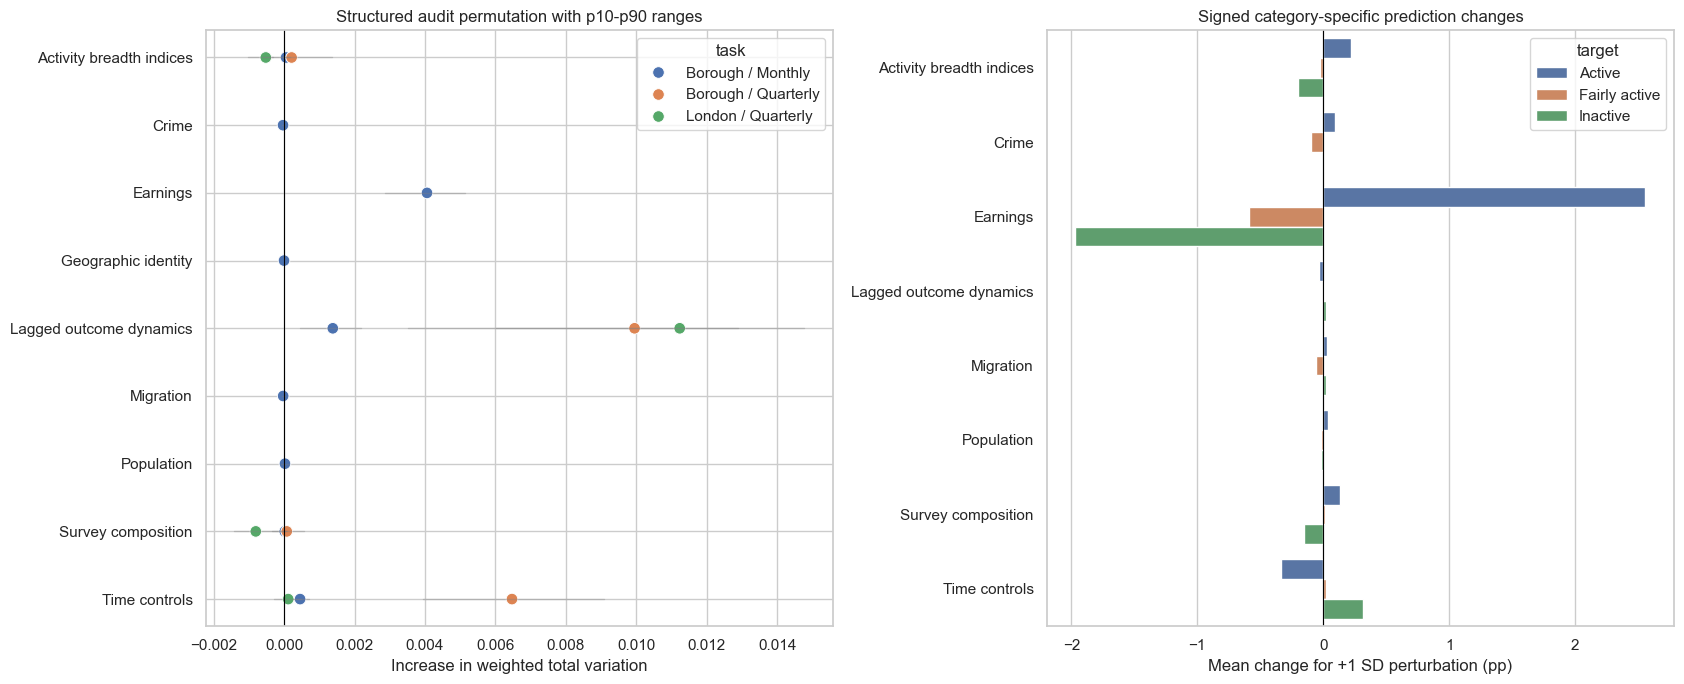

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
if len(structured_permutation):
    permutation_plot = structured_permutation.groupby(
        ['geographic_level', 'frequency', 'group'], as_index=False
    ).agg(
        mean=('mean_tv_increase', 'mean'),
        low=('p10_tv_increase', 'mean'),
        high=('p90_tv_increase', 'mean'),
    )
    permutation_plot['task'] = permutation_plot['geographic_level'] + ' / ' + permutation_plot['frequency']
    focus_tasks = permutation_plot['task'].drop_duplicates().head(5)
    focus = permutation_plot.loc[permutation_plot['task'].isin(focus_tasks)].copy()
    sns.scatterplot(data=focus, x='mean', y='group', hue='task', s=70, ax=axes[0])
    for _, row in focus.iterrows():
        axes[0].plot([row['low'], row['high']], [row['group'], row['group']],
                     color='grey', alpha=.35, linewidth=1)
axes[0].axvline(0, color='black', linewidth=.8)
axes[0].set(title='Structured audit permutation with p10-p90 ranges',
            xlabel='Increase in weighted total variation', ylabel='')

if len(signed_marginal_effects):
    marginal_plot = signed_marginal_effects.groupby(
        ['group', 'target'], as_index=False
    )['mean_prediction_change_pp'].mean()
    sns.barplot(data=marginal_plot, x='mean_prediction_change_pp', y='group',
                hue='target', errorbar=None, ax=axes[1])
axes[1].axvline(0, color='black', linewidth=.8)
axes[1].set(title='Signed category-specific prediction changes',
            xlabel='Mean change for +1 SD perturbation (pp)', ylabel='')
fig.tight_layout()
save_figure(fig, 'forecast_development_only_explanations.png')
plt.show()

### Sensitivity and explanation findings

Adding online response changes audit weighted TV by -0.00026 for borough monthly, +0.00167 for
London quarterly and +0.00003 for borough quarterly; it remains a sensitivity term rather than a
primary predictor. Removing identity from the selected borough-month Random Forest improves audit
TV by only 0.00019, while adding it to borough-quarter Ridge worsens TV by 0.00002. Identity
dependence is therefore visible rather than assumed. Separately tuned external groups produce small and inconsistent
selection-fold changes; none is promoted to a universal forecasting driver.

All six selected baselines have exact formula explanations. The selected Ridge, Random Forest and
Gradient Boosting tasks receive structured audit permutation, p10-p90 ranges, signed
category-specific +1-SD effects and local counterfactual explanations. No explanation reads the final test, and incompatible coefficient
and tree-importance scales are not mixed.


## 10. COVID-aware monthly forecasting sensitivity

COVID is tested as a compact sensitivity, not allowed to overwrite the selected forecasts. The final
Oxford England Stringency Index is converted to a monthly mean and represented only by prior-month
stringency and a lagged policy-memory feature (six-month half-life), so the forecast never reads the
current month's realised policy. Source: [Oxford tracker](https://www.bsg.ox.ac.uk/research/covid-19-government-response-tracker)
and [final data repository](https://github.com/OxCGRT/covid-policy-dataset).

At each geographic level, a fixed Ridge (`alpha=10`, ILR, no geographic identity) is fitted twice on
identical eligible rows: core features alone and core plus COVID. The onset block is an unforeseeable
stress test; promotion requires positive paired whole-month-bootstrap evidence in both the later-wave
and recovery development blocks. The post-COVID test is read only after that rule is fixed.


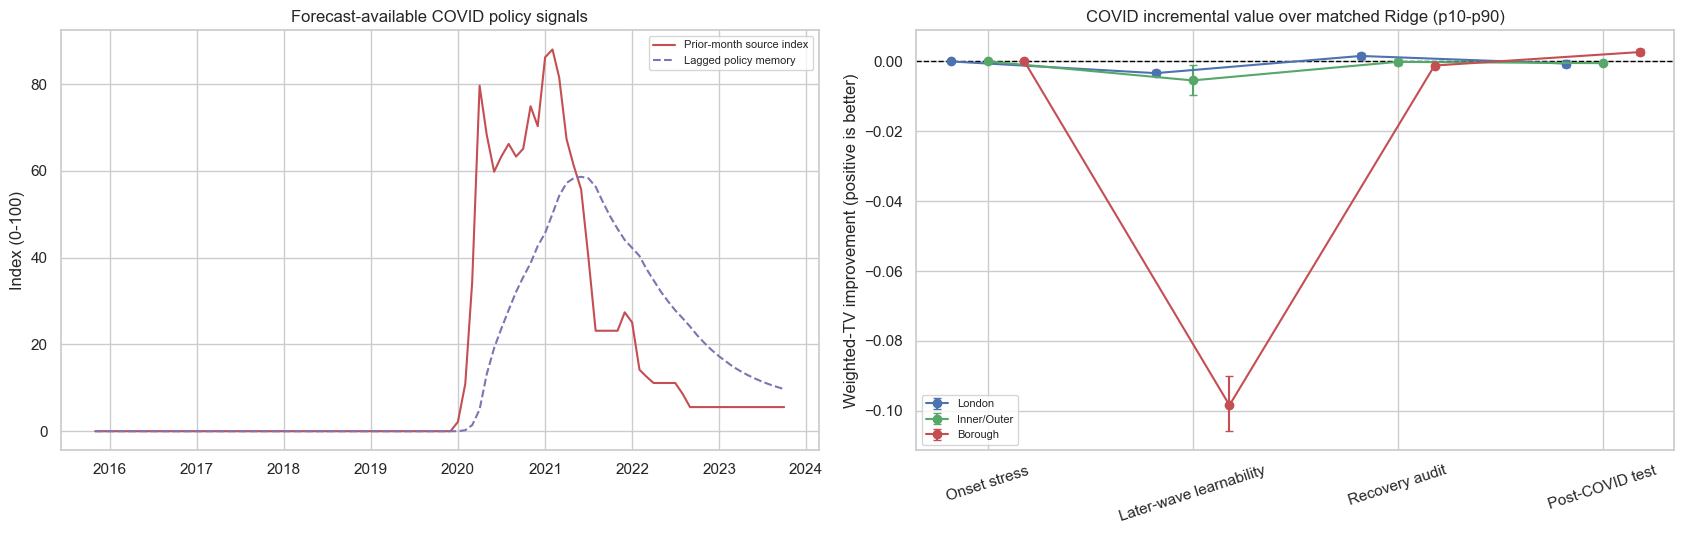

,geographic_level,phase,training_rows,training_months,positive_policy_training_months,evaluation_rows,evaluation_months,identical_evaluation_rows
0,London,Onset stress,36,36,0,12,12,True
1,London,Later-wave learnability,48,48,9,12,12,True
2,London,Recovery audit,60,60,21,12,12,True
3,London,Post-COVID test,72,72,33,12,12,True
4,Inner/Outer,Onset stress,72,36,0,24,12,True
5,Inner/Outer,Later-wave learnability,96,48,9,24,12,True
6,Inner/Outer,Recovery audit,120,60,21,24,12,True
7,Inner/Outer,Post-COVID test,144,72,33,24,12,True
8,Borough,Onset stress,1152,36,0,383,12,True
9,Borough,Later-wave learnability,1535,48,9,380,12,True


,geographic_level,phase,reference_model,comparison_model,reference_weighted_tv,comparison_weighted_tv,absolute_improvement,relative_improvement,months_improved,months_compared,improvement_p10,improvement_p90,bootstrap_repeats,comparison_type
0,London,Onset stress,Matched Ridge: core,Matched Ridge: core + COVID,0.0452,0.0452,-0.0000,-0.0000,2,12,-0.0000,0.0000,1000,COVID incremental value (matched Ridge)
1,London,Onset stress,Notebook 03 selected: last_observation,Matched Ridge: core + COVID,0.0355,0.0452,-0.0097,-0.2741,8,12,-0.0203,0.0017,1000,Practical comparison with selected forecast
2,London,Later-wave learnability,Matched Ridge: core,Matched Ridge: core + COVID,0.0242,0.0275,-0.0034,-0.1389,1,12,-0.0042,-0.0025,1000,COVID incremental value (matched Ridge)
3,London,Later-wave learnability,Notebook 03 selected: last_observation,Matched Ridge: core + COVID,0.0276,0.0275,0.0001,0.0021,5,12,-0.0087,0.0082,1000,Practical comparison with selected forecast
4,London,Recovery audit,Matched Ridge: core,Matched Ridge: core + COVID,0.0206,0.0190,0.0016,0.0758,8,12,0.0007,0.0024,1000,COVID incremental value (matched Ridge)
5,London,Recovery audit,Notebook 03 selected: last_observation,Matched Ridge: core + COVID,0.0255,0.0190,0.0065,0.2542,8,12,0.0022,0.0110,1000,Practical comparison with selected forecast
6,London,Post-COVID test,Matched Ridge: core,Matched Ridge: core + COVID,0.0232,0.0238,-0.0006,-0.0264,3,12,-0.0015,0.0004,1000,COVID incremental value (matched Ridge)
7,London,Post-COVID test,Notebook 03 selected: last_observation,Matched Ridge: core + COVID,0.0327,0.0238,0.0090,0.2735,11,12,0.0049,0.0132,1000,Practical comparison with selected forecast
8,Inner/Outer,Onset stress,Matched Ridge: core,Matched Ridge: core + COVID,0.0453,0.0453,-0.0000,-0.0000,3,12,-0.0000,0.0000,1000,COVID incremental value (matched Ridge)
9,Inner/Outer,Onset stress,Notebook 03 selected: last_observation,Matched Ridge: core + COVID,0.0455,0.0453,0.0002,0.0043,9,12,-0.0118,0.0112,1000,Practical comparison with selected forecast


,geographic_level,later_wave_all_conditions,recovery_all_conditions,development_supported,post_covid_test_relative_improvement,decision
0,London,False,True,False,-0.026410,Sensitivity only; selected forecast unchanged
1,Inner/Outer,False,False,False,-0.016619,Sensitivity only; selected forecast unchanged
2,Borough,False,False,False,0.024770,Sensitivity only; selected forecast unchanged


In [16]:
COVID_SOURCE_PATH = PROJECT_ROOT / 'data_integration' / 'external' / 'OxCGRT_timeseries_StringencyIndex_v1.csv'
COVID_FEATURES = ['covid_stringency_lag1', 'covid_policy_memory_lag1']
COVID_RIDGE = {
    'candidate_id': 'covid_matched_ridge_a10', 'algorithm': 'Ridge',
    'configuration': 'core', 'alpha': 10.0, 'complexity': 10, 'use_geography': False,
}
COVID_PHASES = [
    ('Onset stress', 49, 60),
    ('Later-wave learnability', 61, 72),
    ('Recovery audit', 73, 84),
    ('Post-COVID test', 85, 96),
]
assert COVID_SOURCE_PATH.exists(), f'Missing required COVID source: {COVID_SOURCE_PATH}'

oxford_covid = pd.read_csv(COVID_SOURCE_PATH)
england_covid = oxford_covid.loc[
    oxford_covid['CountryCode'].eq('GBR')
    & oxford_covid['RegionCode'].eq('UK_ENG')
    & oxford_covid['Jurisdiction'].eq('STATE_TOTAL')
]
assert len(england_covid) == 1
covid_date_columns = list(oxford_covid.columns[7:])
covid_daily = pd.DataFrame({
    'date': pd.to_datetime(covid_date_columns, format='%d%b%Y'),
    'stringency_index': pd.to_numeric(
        england_covid.iloc[0][covid_date_columns].to_numpy(), errors='coerce'
    ),
}).sort_values('date')
covid_first_observed = covid_daily.loc[covid_daily['stringency_index'].notna(), 'date'].min()
covid_last_observed = covid_daily.loc[covid_daily['stringency_index'].notna(), 'date'].max()
covid_last_value = covid_daily.loc[
    covid_daily['date'].eq(covid_last_observed), 'stringency_index'
].iloc[0]
covid_source_monthly = covid_daily.set_index('date')['stringency_index'].resample('MS').mean()

covid_calendar = pd.DataFrame({
    'period_start': pd.date_range(
        panels[('London', 'Monthly')]['period_start'].min(),
        panels[('London', 'Monthly')]['period_start'].max(), freq='MS',
    )
})
covid_calendar['covid_stringency'] = covid_calendar['period_start'].map(covid_source_monthly)
covid_calendar.loc[covid_calendar['period_start'].lt(covid_first_observed), 'covid_stringency'] = 0.0
covid_calendar.loc[covid_calendar['period_start'].gt(covid_last_observed), 'covid_stringency'] = covid_last_value
assert covid_calendar['covid_stringency'].notna().all()
covid_calendar['covid_stringency'] /= 100
known_policy = covid_calendar['covid_stringency'].shift(1).fillna(0)
covid_calendar['covid_stringency_lag1'] = known_policy
covid_calendar['covid_policy_memory_lag1'] = known_policy.ewm(halflife=6, adjust=False).mean()

covid_panels = {}
for level in ['London', 'Inner/Outer', 'Borough']:
    covid_panels[level] = prepared_tasks[(level, 'Monthly')].merge(
        covid_calendar[['period_start', *COVID_FEATURES]],
        on='period_start', how='left', validate='many_to_one',
    )
    assert covid_panels[level][COVID_FEATURES].notna().all().all()

covid_source_register = pd.DataFrame([{
    'source': 'Oxford COVID-19 Government Response Tracker final Stringency Index',
    'jurisdiction': 'England STATE_TOTAL (GBR / UK_ENG)',
    'first_observed_date': covid_first_observed,
    'last_observed_date': covid_last_observed,
    'last_observed_value_0_100': covid_last_value,
    'forecast_features': ', '.join(COVID_FEATURES),
    'availability_rule': 'Policy information through t-1 only',
    'licence': 'CC BY 4.0',
}])
selected_monthly = selection_register.loc[
    selection_register['frequency'].eq('Monthly')
].set_index('geographic_level')['selected_candidate'].to_dict()


def covid_prediction_frame(evaluation, predicted, level, phase, model_name):
    metadata = [
        'month_index', 'period_start', 'geography_code', 'geography_name',
        'effective_n', *TARGETS, *[c for c in ['inner_outer'] if c in evaluation],
    ]
    output = evaluation[metadata].copy()
    output['geographic_level'] = level
    output['phase'] = phase
    output['model_name'] = model_name
    for index, target in enumerate(TARGETS):
        output[f'predicted_{target}'] = predicted[:, index]
        output[f'error_{target}'] = predicted[:, index] - output[target]
    output['row_total_variation'] = .5 * sum(
        output[f'error_{target}'].abs() for target in TARGETS
    )
    return output


def original_monthly_block(level, phase):
    selected_id = selected_monthly[level]
    if phase == 'Onset stress':
        source, mask = selection_predictions, selection_predictions['fold'].eq(1)
    elif phase == 'Later-wave learnability':
        source, mask = selection_predictions, selection_predictions['fold'].eq(2)
    elif phase == 'Recovery audit':
        source, mask = audit_predictions, pd.Series(True, index=audit_predictions.index)
    else:
        source, mask = test_predictions, pd.Series(True, index=test_predictions.index)
    return source.loc[
        mask & source['frequency'].eq('Monthly')
        & source['geographic_level'].eq(level)
        & source['candidate_id'].eq(selected_id)
    ].copy()


covid_metric_rows, covid_prediction_parts, covid_fit_rows = [], [], []
for level in ['London', 'Inner/Outer', 'Borough']:
    panel = covid_panels[level]
    core_features = task_feature_sets[(level, 'Monthly')]['core']
    for phase, start, end in COVID_PHASES:
        train = panel.loc[panel['eligible'] & panel['month_index'].lt(start)].copy()
        evaluation = panel.loc[
            panel['eligible'] & panel['month_index'].between(start, end)
        ].copy()
        outputs = []
        for model_name, features in [
            ('Matched Ridge: core', core_features),
            ('Matched Ridge: core + COVID', core_features + COVID_FEATURES),
        ]:
            models = fit_candidate(
                train, COVID_RIDGE, task_feature_sets[(level, 'Monthly')],
                override_features=features,
            )
            predicted, _ = predict_candidate(
                evaluation, COVID_RIDGE, task_feature_sets[(level, 'Monthly')], models,
                override_features=features,
            )
            outputs.append(covid_prediction_frame(evaluation, predicted, level, phase, model_name))

        original = original_monthly_block(level, phase)
        keys = ['month_index', 'geography_code']
        assert set(map(tuple, evaluation[keys].to_numpy())) == set(map(tuple, original[keys].to_numpy()))
        original_frame = evaluation[[
            'month_index', 'period_start', 'geography_code', 'geography_name',
            'effective_n', *TARGETS, *[c for c in ['inner_outer'] if c in evaluation],
        ]].merge(
            original[keys + [f'predicted_{target}' for target in TARGETS]],
            on=keys, validate='one_to_one',
        )
        outputs.insert(0, covid_prediction_frame(
            original_frame,
            original_frame[[f'predicted_{target}' for target in TARGETS]].to_numpy(),
            level, phase, f'Notebook 03 selected: {selected_monthly[level]}',
        ))

        for output in outputs:
            covid_metric_rows.append({
                'geographic_level': level, 'phase': phase,
                'model_name': output['model_name'].iloc[0],
                **score_predictions(
                    output[TARGETS],
                    output[[f'predicted_{target}' for target in TARGETS]],
                    output['effective_n'], output['month_index'],
                ),
            })
            covid_prediction_parts.append(output)
        covid_fit_rows.append({
            'geographic_level': level, 'phase': phase,
            'training_rows': len(train), 'training_months': train['month_index'].nunique(),
            'positive_policy_training_months': train.loc[
                train['covid_stringency_lag1'].gt(0), 'month_index'
            ].nunique(),
            'evaluation_rows': len(evaluation),
            'evaluation_months': evaluation['month_index'].nunique(),
            'identical_evaluation_rows': True,
        })

covid_phase_metrics = pd.DataFrame(covid_metric_rows)
covid_predictions = pd.concat(covid_prediction_parts, ignore_index=True)
covid_fit_audit = pd.DataFrame(covid_fit_rows)


def covid_paired_comparison(level, phase, reference_name, comparison_name, repeats=1000):
    keys = ['month_index', 'geography_code']
    reference = covid_predictions.loc[
        covid_predictions['geographic_level'].eq(level)
        & covid_predictions['phase'].eq(phase)
        & covid_predictions['model_name'].eq(reference_name)
    ]
    comparison = covid_predictions.loc[
        covid_predictions['geographic_level'].eq(level)
        & covid_predictions['phase'].eq(phase)
        & covid_predictions['model_name'].eq(comparison_name)
    ]
    paired = reference[keys + ['effective_n', 'row_total_variation']].merge(
        comparison[keys + ['row_total_variation']].rename(
            columns={'row_total_variation': 'comparison_row_tv'}
        ), on=keys, validate='one_to_one',
    )
    reference_tv = weighted_mean(paired['row_total_variation'], paired['effective_n'])
    comparison_tv = weighted_mean(paired['comparison_row_tv'], paired['effective_n'])
    monthly = paired.groupby('month_index').apply(
        lambda group: pd.Series({
            'reference_tv': weighted_mean(group['row_total_variation'], group['effective_n']),
            'comparison_tv': weighted_mean(group['comparison_row_tv'], group['effective_n']),
        }), include_groups=False,
    )
    periods = paired['month_index'].unique()
    rng = np.random.default_rng(RANDOM_STATE + len(level) * 13 + len(phase) * 7 + len(reference_name))
    boot = []
    for _ in range(repeats):
        sampled = rng.choice(periods, size=len(periods), replace=True)
        sampled_rows = pd.concat(
            [paired.loc[paired['month_index'].eq(period)] for period in sampled],
            ignore_index=True,
        )
        boot.append(
            weighted_mean(sampled_rows['row_total_variation'], sampled_rows['effective_n'])
            - weighted_mean(sampled_rows['comparison_row_tv'], sampled_rows['effective_n'])
        )
    return {
        'geographic_level': level, 'phase': phase,
        'reference_model': reference_name, 'comparison_model': comparison_name,
        'reference_weighted_tv': reference_tv, 'comparison_weighted_tv': comparison_tv,
        'absolute_improvement': reference_tv - comparison_tv,
        'relative_improvement': 1 - comparison_tv / reference_tv,
        'months_improved': int((monthly['comparison_tv'] < monthly['reference_tv']).sum()),
        'months_compared': len(periods),
        'improvement_p10': np.quantile(boot, .10),
        'improvement_p90': np.quantile(boot, .90),
        'bootstrap_repeats': repeats,
    }


covid_comparison_rows = []
for level in ['London', 'Inner/Outer', 'Borough']:
    original_name = f'Notebook 03 selected: {selected_monthly[level]}'
    for phase, _, _ in COVID_PHASES:
        covid_comparison_rows.extend([
            covid_paired_comparison(
                level, phase, 'Matched Ridge: core', 'Matched Ridge: core + COVID'
            ),
            covid_paired_comparison(
                level, phase, original_name, 'Matched Ridge: core + COVID'
            ),
        ])
covid_paired_comparisons = pd.DataFrame(covid_comparison_rows)
covid_paired_comparisons['comparison_type'] = np.where(
    covid_paired_comparisons['reference_model'].eq('Matched Ridge: core'),
    'COVID incremental value (matched Ridge)',
    'Practical comparison with selected forecast',
)

covid_support_rows = []
for level in ['London', 'Inner/Outer', 'Borough']:
    development = covid_paired_comparisons.loc[
        covid_paired_comparisons['geographic_level'].eq(level)
        & covid_paired_comparisons['comparison_type'].eq('COVID incremental value (matched Ridge)')
        & covid_paired_comparisons['phase'].isin(['Later-wave learnability', 'Recovery audit'])
    ].set_index('phase')
    conditions = (
        development['absolute_improvement'].gt(0)
        & development['months_improved'].ge(7)
        & development['improvement_p10'].gt(0)
    )
    test_row = covid_paired_comparisons.loc[
        covid_paired_comparisons['geographic_level'].eq(level)
        & covid_paired_comparisons['comparison_type'].eq('COVID incremental value (matched Ridge)')
        & covid_paired_comparisons['phase'].eq('Post-COVID test')
    ].iloc[0]
    covid_support_rows.append({
        'geographic_level': level,
        'later_wave_all_conditions': bool(conditions.get('Later-wave learnability', False)),
        'recovery_all_conditions': bool(conditions.get('Recovery audit', False)),
        'development_supported': bool(conditions.all()),
        'post_covid_test_relative_improvement': test_row['relative_improvement'],
        'decision': 'Sensitivity only; selected forecast unchanged',
    })
covid_promotion_register = pd.DataFrame(covid_support_rows)

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
axes[0].plot(covid_calendar['period_start'], covid_calendar['covid_stringency'] * 100,
             color='#c44e52', label='Prior-month source index')
axes[0].plot(covid_calendar['period_start'], covid_calendar['covid_policy_memory_lag1'] * 100,
             color='#8172b2', linestyle='--', label='Lagged policy memory')
axes[0].set(title='Forecast-available COVID policy signals', xlabel='', ylabel='Index (0-100)')
axes[0].legend(fontsize=8)

incremental = covid_paired_comparisons.loc[
    covid_paired_comparisons['comparison_type'].eq('COVID incremental value (matched Ridge)')
].copy()
phase_positions = {phase: index for index, (phase, _, _) in enumerate(COVID_PHASES)}
for level, offset, color in [
    ('London', -.18, '#4c72b0'), ('Inner/Outer', 0, '#55a868'), ('Borough', .18, '#c44e52')
]:
    local = incremental.loc[incremental['geographic_level'].eq(level)]
    x = np.array([phase_positions[value] for value in local['phase']]) + offset
    y = local['absolute_improvement'].to_numpy()
    yerr = np.vstack([y - local['improvement_p10'].to_numpy(), local['improvement_p90'].to_numpy() - y])
    axes[1].errorbar(x, y, yerr=yerr, fmt='o-', capsize=3, color=color, label=level)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xticks(range(4), [phase for phase, _, _ in COVID_PHASES], rotation=18)
axes[1].set(title='COVID incremental value over matched Ridge (p10-p90)',
            xlabel='', ylabel='Weighted-TV improvement (positive is better)')
axes[1].legend(fontsize=8)
fig.tight_layout()
save_figure(fig, 'monthly_covid_forecasting_sensitivity.png')
plt.show()

display(covid_fit_audit)
display(covid_paired_comparisons.round(4))
display(covid_promotion_register)


### COVID forecasting result

No geographic level passes the predeclared development rule, so COVID is **not promoted** into the
official monthly forecast. Relative to the matched Ridge, COVID worsens later-wave weighted TV by
13.9% for London, 15.8% for Inner/Outer and 89.6% for boroughs. During recovery it improves London
by 7.6%, but slightly worsens Inner/Outer (0.4%) and boroughs (1.1%). On the untouched post-COVID
test it worsens London by 2.6% and Inner/Outer by 1.7%, while improving boroughs by only 2.5%.

A comparison with the originally selected forecast can look more favourable for London and
Inner/Outer because those tasks selected Last Observation. The matched-architecture comparison
isolates the COVID columns and shows that most apparent gain comes from changing to Ridge, not from
COVID information. This reconciles the two findings: the pandemic-period activity shift is material,
but one short, London-wide policy history is too weak and collinear with time/lagged activity to add
stable out-of-sample predictive value.


## 11. Report-ready delivery and limitations

The workbook exposes validation, warm-up removal, every selection fold, weighted and unweighted
metrics, survey-noise diagnostics, uncertainty, coherence, residual profiles and development-only
explanations. It is written to a temporary file and atomically replaces the previous workbook only
after every sheet succeeds.

No method can turn eight annual London observations or one annual test year into stable evidence.
Annual aggregate ML is therefore not selected, annual skill intervals are withheld, and annual
points are plotted as points rather than false trend lines. Weather and economic inactivity remain
genuine upstream gaps.

The remaining limitations are explicit. Effective-n variance is only an approximation to the full
complex-survey design variance; ILR models optimize Euclidean compositional geometry while model
selection uses policy-facing raw-share TV; marginal display bands are not the joint TV region; and
monthly, quarterly and annual direct estimates are not algebraically identical targets. These are
reported rather than hidden by unstable extra modelling.


In [17]:
issue_audit = pd.DataFrame([
    ('Structural warm-up imputed into ML training', 'Confirmed', 'Fixed',
     'All structural lag/rolling missing rows are removed before folds; sporadic predictor imputation remains fold-local.'),
    ('Naive and ML evaluation samples differ because of warm-up', 'Mostly not present in old evaluation windows', 'Guarded',
     'Every candidate now uses an asserted common eligible row set in each fold.'),
    ('No independent forecasting-data validation', 'Confirmed', 'Fixed',
     'Duplicate keys, grids, continuity, target bounds/composition, missingness and effective_n are validated in this notebook.'),
    ('No effective_n training weights', 'Confirmed', 'Fixed',
     'Capped and normalized effective_n weights are passed to Ridge, Random Forest and Gradient Boosting fitting.'),
    ('No effective_n evaluation weights', 'Confirmed', 'Fixed',
     'Uncapped effective_n weighted and unweighted TV are both exported.'),
    ('Survey noise not separated from forecast error', 'Confirmed', 'Partly fixed / limited by data',
     'Approximate p(1-p)/effective_n noise floors and noise-adjusted RMSE are reported; full design variances are unavailable.'),
    ('London annual ML sample is severely insufficient', 'Confirmed', 'Compared but not overclaimed',
     'All four families are fitted as requested, but annual rankings are flagged severe because the first fold has only two independent training years.'),
    ('Annual tree cannot split with old leaf sizes', 'Confirmed', 'Fixed with explicit warning',
     'All annual tasks now fit depth-one adaptive trees; <=5 independent training periods are flagged as descriptive only.'),
    ('Annual uses one validation year', 'Confirmed in old notebook', 'Fixed as far as possible',
     'Years 5 and 6 are separate selection folds and Year 7 is audit; independence is still limited.'),
    ('Annual uses one test year', 'Confirmed and unavoidable', 'Explicit limitation',
     'Annual skill intervals and R-squared are withheld; annual test is plotted as points.'),
    ('Same folds repeatedly used for feature/parameter/model selection', 'Confirmed', 'Fixed',
     'One prespecified candidate comparison replaces sequential multi-layer tuning; later audit is separate.'),
    ('No simple-model preference rule', 'Confirmed', 'Fixed',
     'One-standard-error selection chooses the lowest-complexity eligible candidate.'),
    ('Parameter grid ignores sample size', 'Confirmed', 'Fixed',
     'All families are present; tree depth and leaf size depend on first-fold rows and independent periods.'),
    ('No tree random-seed stability', 'Confirmed', 'Fixed',
     'Random Forest and Gradient Boosting predictions average three seeds and seed-level TV dispersion is exported.'),
    ('Geographic-level forecasts are incoherent', 'Confirmed', 'Fixed for published forecasts',
     'Canonical London and Inner/Outer forecasts are bottom-up population-weighted borough aggregates.'),
    ('Frequencies are incoherent', 'Confirmed as a diagnostic issue', 'Diagnosed, not falsely constrained',
     'Cross-frequency gaps are exported because direct survey estimands are not exact lower-frequency averages.'),
    ('External ablation is one large bundle', 'Confirmed', 'Fixed',
     'Population, migration, earnings and crime candidate families are evaluated separately with parameter retuning.'),
    ('Economic inactivity and weather absent', 'Confirmed', 'Upstream gap',
     'Both are registered unavailable; no proxy is invented.'),
    ('Online response is in every primary model', 'Confirmed', 'Fixed',
     'Online response is excluded from primary candidates and added only in audit sensitivity.'),
    ('Income variables are duplicated', 'Confirmed', 'Fixed',
     'Only earnings relative to London is retained.'),
    ('Crime variables are duplicated', 'Confirmed', 'Fixed',
     'Only the prespecified selected combined rate is retained and labelled specification-sensitive.'),
    ('Compact activity feature has unclear meaning', 'Confirmed', 'Clarified and renamed',
     'Three breadth indices are explicitly means of listed-activity prevalence, not latent activity scores.'),
    ('Lag structure only contains seasonal lag', 'Confirmed', 'Fixed',
     'Lag 1, seasonal lag, recent mean, recent change and exponentially weighted history are compared.'),
    ('Monthly horizon is unclear / actually seasonal', 'Confirmed', 'Fixed',
     'The task is explicitly rolling one-month-ahead; seasonal lag is only one input/baseline.'),
    ('Simple time-series baselines are insufficient', 'Confirmed', 'Fixed',
     'Last, seasonal, recent mean, fixed exponential smoothing and local drift are included.'),
    ('Geographic identity has no formal refit ablation', 'Confirmed', 'Fixed',
     'Identity is formally added or removed and the model is refitted on pre-audit data.'),
    ('Full one-hot geography plus intercept is redundant', 'Confirmed', 'Fixed',
     'OneHotEncoder drops the first category.'),
    ('ALR depends on Active denominator', 'Confirmed', 'Fixed',
     'Reference-invariant orthonormal ILR replaces ALR.'),
    ('Training loss and selection metric differ', 'Confirmed but not inherently invalid', 'Explicit design choice',
     'Models fit ILR geometry; all candidate decisions use raw-share effective_n-weighted TV.'),
    ('No confidence intervals for test performance', 'Confirmed', 'Fixed where feasible',
     'Time-block bootstrap skill intervals are reported for at least four test periods; annual is withheld.'),
    ('Small-test R-squared is unstable', 'Confirmed', 'Fixed',
     'R-squared is suppressed below eight independent test periods.'),
    ('TV and overall MAE are redundant', 'Confirmed exactly for three parts', 'Fixed',
     'Overall MAE is removed from primary tables; target MAE remains.'),
    ('No directional bias', 'Confirmed', 'Fixed',
     'Signed category-specific effective_n-weighted bias is exported and plotted.'),
    ('No borough error profile', 'Confirmed', 'Fixed',
     'Persistent borough MAE/bias profiles and worst-borough chart are included.'),
    ('No effective_n-stratified error', 'Confirmed', 'Fixed',
     'Errors are summarized by low/middle/high precision tiers.'),
    ('No temporal residual diagnostic', 'Confirmed', 'Fixed with sample-size warnings',
     'Lag-1 and seasonal residual correlations are exported; unavailable/fragile cases remain NaN or labelled.'),
    ('No explicit residual-feedback sensitivity', 'Confirmed', 'Fixed for monthly tasks only',
     'Bias and capped AR(1) corrections use past out-of-fold residuals; audit selects the form and the frozen rule is checked on test. Quarterly and annual are excluded for insufficient periods.'),
    ('No spatial residual diagnostic', 'Confirmed', 'Fixed',
     'Borough Active residual Moran tests use official boundaries and 999 permutations.'),
    ('Monthly-to-quarter uses a simple average', 'Confirmed', 'Clarified and audited',
     'It is labelled an alternative estimand and compared with direct quarterly truth; it is not assumed identical.'),
    ('Frequency choice lacks stability interval/fold detail', 'Confirmed', 'Fixed',
     'Every fold is plotted and a one-standard-error rule governs the decision.'),
    ('Empirical bands are not strict prediction intervals', 'Confirmed', 'Replaced',
     'Block-calibrated TV regions replace absolute-error radii; limitations are stated.'),
    ('Category bands are not a joint composition region', 'Confirmed', 'Fixed conceptually',
     'A joint simplex TV radius is primary; marginal bands are separately labelled displays.'),
    ('Bands ignore heteroskedasticity', 'Confirmed', 'Partly fixed',
     'Marginal residual bands are stratified by effective_n tier.'),
    ('Annual London band uses one residual', 'Confirmed', 'Fixed by withholding',
     'All annual intervals are withheld for fewer than eight calibration blocks.'),
    ('Main forecast plots omit bands', 'Confirmed', 'Fixed',
     'Monthly and quarterly London composition plots include precision-stratified bands.'),
    ('Ridge and SHAP importance are incomparable', 'Confirmed', 'Fixed',
     'SHAP/Ridge combined chart is removed; common structured permutation is primary.'),
    ('Ridge importance loses direction', 'Confirmed', 'Fixed',
     'Signed category-specific +1-SD prediction changes are exported in percentage points.'),
    ('SHAP remains in ALR space', 'Confirmed', 'Removed',
     'No SHAP result is used; effects are evaluated after inverse ILR in raw composition space.'),
    ('Mean group importance penalizes large groups', 'Confirmed tradeoff', 'Fixed for primary explanation',
     'Group permutation measures joint predictive value without summing/averaging feature importances.'),
    ('Time controls are not structurally permuted', 'Confirmed', 'Fixed',
     'Time controls receive within-geography nonzero cyclic shifts.'),
    ('Inner/Outer permutation is diluted by unchanged swaps', 'Confirmed', 'Fixed',
     'Geography permutation uses a deterministic non-identity cyclic mapping; two codes always swap.'),
    ('Removed-group models are not retuned', 'Confirmed', 'Fixed for external groups',
     'Each external candidate family retunes Ridge alpha; generic misleading refit ablation is removed.'),
    ('Explanation repeatedly uses final test', 'Confirmed', 'Fixed',
     'All permutation, online, identity and local explanations use development audit only.'),
    ('Annual and borough-month models lack explanation', 'Confirmed', 'Fixed',
     'Every selected baseline has an exact formula; every selected ML task has audit explanations.'),
    ('No local explanation', 'Confirmed', 'Fixed',
     'Worst audit rows receive group-to-training-median counterfactual impacts.'),
    ('No category-specific explanation', 'Confirmed', 'Fixed',
     'Permutation MAE changes and signed marginal effects are reported for all three categories.'),
    ('Permutation p10-p90 is not plotted', 'Confirmed', 'Fixed',
     'The main explanation plot displays p10-p90 ranges.'),
    ('Monthly ablation mixes incomparable task designs', 'Confirmed', 'Fixed',
     'The detailed-372 design is removed; each task has explicit candidate and fold tables.'),
    ('Forecast plot units differ', 'Confirmed', 'Fixed',
     'Forecast plots consistently use percent or percentage points.'),
    ('Annual single point is drawn as a line', 'Confirmed', 'Fixed',
     'Annual observed/predicted values use point markers only.'),
    ('Borough scatter colour has no information', 'Confirmed', 'Fixed',
     'Colour encodes the three activity categories, not 32 hidden borough identities.'),
    ('Barplot default error bars are ambiguous', 'Confirmed', 'Fixed',
     'Default seaborn error bars are disabled; explicit time-block intervals are separately drawn.'),
    ('Frequency plot omits fold-level results', 'Confirmed', 'Fixed',
     'Both folds and all three geographic levels are visible.'),
    ('Main figures emphasize only Active', 'Confirmed', 'Fixed',
     'London and borough calibration figures show all three composition parts.'),
    ('COVID is absent from forecasting', 'Confirmed', 'Sensitivity completed',
     'Lagged Oxford policy features are tested in matched monthly Ridge models; no level passes the development promotion rule.'),
    ('Four model families are not compared in every task', 'Confirmed', 'Fixed',
     'Naive, Ridge, Random Forest and Gradient Boosting now have selection, audit and test results for all nine tasks; short annual series are explicitly flagged.'),
], columns=['issue', 'verdict', 'resolution_status', 'action_or_limitation'])

model_registry_rows = []
for (level, frequency), result in task_results.items():
    for candidate in result['candidates']:
        model_registry_rows.append({
            'geographic_level': level, 'frequency': frequency,
            **{k: v for k, v in candidate.items() if k not in ['features']},
            'features': json.dumps(
                result['feature_sets'].get(candidate['configuration'], []), sort_keys=True
            ),
            'tree_seeds': json.dumps(TREE_SEEDS if candidate['algorithm'] in TREE_ALGORITHMS else []),
        })
model_registry = pd.DataFrame(model_registry_rows)

decision_register = pd.DataFrame([
    {'decision': 'Forecast horizon', 'choice': 'Rolling one-period-ahead; seasonal lags are predictors/baselines'},
    {'decision': 'Warm-up', 'choice': 'Structural lag/rolling missing rows removed before every fold'},
    {'decision': 'Composition transform', 'choice': 'Orthonormal ILR; no arbitrary Active denominator'},
    {'decision': 'Training weights', 'choice': '5th-95th percentile capped effective_n, normalized within training fold'},
    {'decision': 'Evaluation weights', 'choice': 'Uncapped effective_n; weighted and unweighted TV both exported'},
    {'decision': 'Selection', 'choice': 'Single candidate comparison plus one-standard-error simplicity rule'},
    {'decision': 'Annual aggregate ML', 'choice': 'All four families compared; <=5 training periods flagged severe and one-standard-error simplicity retained'},
    {'decision': 'Tree stability', 'choice': f'Random Forest and Gradient Boosting averaged across seeds {TREE_SEEDS}; seed dispersion exported'},
    {'decision': 'Geographic encoding', 'choice': 'First category dropped; identity formally added/removed with audit refit'},
    {'decision': 'Training versus selection loss', 'choice': 'Models fit in ILR geometry; candidates selected by raw-share weighted TV'},
    {'decision': 'Time-series baselines', 'choice': 'Last, seasonal, recent mean, fixed exponential smoothing and local drift'},
    {'decision': 'Online response', 'choice': 'Excluded from primary features; audit-only sensitivity'},
    {'decision': 'Earnings', 'choice': 'Relative-to-London only; raw earnings duplicate removed'},
    {'decision': 'Crime', 'choice': 'Selected combined rate only; labelled specification-sensitive'},
    {'decision': 'Uncertainty', 'choice': 'Block-calibrated joint TV region plus precision-tier marginal bands'},
    {'decision': 'Geographic coherence', 'choice': 'Bottom-up borough forecasts are canonical aggregate forecasts'},
    {'decision': 'Cross-frequency alignment', 'choice': 'Gaps reported, not forced, because survey estimands are not exact averages'},
    {'decision': 'Explanation sample', 'choice': 'Development audit only; final test not reused'},
    {'decision': 'Residual correction', 'choice': 'Monthly sensitivity only; selection OOF residuals -> audit choice -> frozen test check; primary forecasts unchanged'},
    {'decision': 'COVID policy features', 'choice': 'Monthly matched-Ridge sensitivity only; no geographic level passes development promotion rule'},
    {'decision': 'Four-family comparison', 'choice': 'All nine tasks: frozen family finalists evaluated on selection, audit and one-time test'},
    {'decision': 'Overall family ranking', 'choice': 'Equal-weight mean task rank across selection and audit; final test excluded'},
])

workbook_path = RESULTS_PATH
temporary_path = RESULTS_DIR / 'q1_forecast_results.tmp.xlsx'
with pd.ExcelWriter(temporary_path, engine='openpyxl') as writer:
    panel_validation.to_excel(writer, sheet_name='panel_validation', index=False)
    issue_audit.to_excel(writer, sheet_name='issue_audit', index=False)
    missing_target_rows.to_excel(writer, sheet_name='missing_targets', index=False)
    predictor_coverage.to_excel(writer, sheet_name='predictor_coverage', index=False)
    predictor_missingness.to_excel(writer, sheet_name='predictor_missingness', index=False)
    warmup_audit.to_excel(writer, sheet_name='warmup_audit', index=False)
    sample_consistency.to_excel(writer, sheet_name='sample_consistency', index=False)
    weight_audit.to_excel(writer, sheet_name='weight_audit', index=False)
    model_registry.to_excel(writer, sheet_name='model_registry', index=False)
    selection_fold_metrics.to_excel(writer, sheet_name='selection_fold_metrics', index=False)
    candidate_summary.to_excel(writer, sheet_name='candidate_summary', index=False)
    model_family_comparison.to_excel(writer, sheet_name='model_family_compare', index=False)
    model_family_phase_metrics.to_excel(writer, sheet_name='model_family_phase', index=False)
    model_family_task_summary.to_excel(writer, sheet_name='model_family_task_summary', index=False)
    model_family_task_recommendations.to_excel(writer, sheet_name='model_family_task_best', index=False)
    model_family_overall.to_excel(writer, sheet_name='model_family_overall', index=False)
    model_family_stability.to_excel(writer, sheet_name='model_family_stability', index=False)
    model_family_phase_predictions.to_excel(writer, sheet_name='model_family_predictions', index=False)
    borough_model_comparison.to_excel(writer, sheet_name='borough_model_compare', index=False)
    borough_model_winners.to_excel(writer, sheet_name='borough_model_winners', index=False)
    borough_model_win_counts.to_excel(writer, sheet_name='borough_model_win_counts', index=False)
    selection_register.to_excel(writer, sheet_name='selection_register', index=False)
    selection_predictions.to_excel(writer, sheet_name='selection_predictions', index=False)
    audit_metrics.to_excel(writer, sheet_name='audit_metrics', index=False)
    audit_predictions.to_excel(writer, sheet_name='audit_predictions', index=False)
    test_metrics.to_excel(writer, sheet_name='test_metrics', index=False)
    test_predictions.to_excel(writer, sheet_name='test_predictions', index=False)
    selected_test_metrics.to_excel(writer, sheet_name='selected_test_metrics', index=False)
    test_skill.to_excel(writer, sheet_name='test_skill', index=False)
    calibration_predictions.to_excel(writer, sheet_name='calibration_predictions', index=False)
    interval_diagnostics.to_excel(writer, sheet_name='interval_diagnostics', index=False)
    band_predictions.to_excel(writer, sheet_name='band_predictions', index=False)
    bias_table.to_excel(writer, sheet_name='signed_bias', index=False)
    resolution_fold_metrics.to_excel(writer, sheet_name='resolution_fold_metrics', index=False)
    resolution_summary.to_excel(writer, sheet_name='resolution_summary', index=False)
    resolution_selection.to_excel(writer, sheet_name='resolution_selection', index=False)
    resolution_audit.to_excel(writer, sheet_name='resolution_audit', index=False)
    hierarchy_reconciliation.to_excel(writer, sheet_name='hierarchy_gaps', index=False)
    reconciled_predictions.to_excel(writer, sheet_name='reconciled_predictions', index=False)
    frequency_alignment.to_excel(writer, sheet_name='frequency_alignment', index=False)
    borough_error_profile.to_excel(writer, sheet_name='borough_error_profile', index=False)
    effective_n_error.to_excel(writer, sheet_name='effective_n_error', index=False)
    temporal_residual_diagnostics.to_excel(writer, sheet_name='temporal_residuals', index=False)
    residual_correction_parameters.to_excel(writer, sheet_name='resid_corr_params', index=False)
    residual_correction_audit_metrics.to_excel(writer, sheet_name='resid_corr_audit', index=False)
    residual_correction_selection.to_excel(writer, sheet_name='resid_corr_selection', index=False)
    residual_correction_test_metrics.to_excel(writer, sheet_name='resid_corr_test', index=False)
    residual_correction_predictions.to_excel(writer, sheet_name='resid_corr_predictions', index=False)
    spatial_residual_diagnostics.to_excel(writer, sheet_name='spatial_residuals', index=False)
    online_sensitivity.to_excel(writer, sheet_name='online_sensitivity', index=False)
    geography_identity_sensitivity.to_excel(writer, sheet_name='geography_sensitivity', index=False)
    external_group_value.to_excel(writer, sheet_name='external_group_value', index=False)
    structured_permutation.to_excel(writer, sheet_name='structured_permutation', index=False)
    signed_marginal_effects.to_excel(writer, sheet_name='signed_marginal_effects', index=False)
    local_explanations.to_excel(writer, sheet_name='local_explanations', index=False)
    baseline_explanations.to_excel(writer, sheet_name='baseline_explanations', index=False)
    covid_source_register.to_excel(writer, sheet_name='covid_source', index=False)
    covid_calendar.to_excel(writer, sheet_name='covid_monthly_features', index=False)
    covid_fit_audit.to_excel(writer, sheet_name='covid_fit_audit', index=False)
    covid_phase_metrics.to_excel(writer, sheet_name='covid_phase_metrics', index=False)
    covid_paired_comparisons.to_excel(writer, sheet_name='covid_paired_compare', index=False)
    covid_promotion_register.to_excel(writer, sheet_name='covid_promotion', index=False)
    covid_predictions.to_excel(writer, sheet_name='covid_predictions', index=False)
    decision_register.to_excel(writer, sheet_name='decision_register', index=False)

os.replace(temporary_path, workbook_path)
print(f'Wrote {workbook_path.relative_to(PROJECT_ROOT)} with {len(pd.ExcelFile(workbook_path).sheet_names)} sheets')
display(decision_register)


Wrote question1_outputs\results\q1_forecast_results.xlsx with 64 sheets


,decision,choice
0,Forecast horizon,Rolling one-period-ahead; seasonal lags are pr...
1,Warm-up,Structural lag/rolling missing rows removed be...
2,Composition transform,Orthonormal ILR; no arbitrary Active denominator
3,Training weights,"5th-95th percentile capped effective_n, normal..."
4,Evaluation weights,Uncapped effective_n; weighted and unweighted ...
5,Selection,Single candidate comparison plus one-standard-...
6,Annual aggregate ML,All four families compared; <=5 training perio...
7,Tree stability,Random Forest and Gradient Boosting averaged a...
8,Geographic encoding,First category dropped; identity formally adde...
9,Training versus selection loss,Models fit in ILR geometry; candidates selecte...
